# EDA (application_train)

## Resumen ejecutivo

Analizo `application_train`: 307.511 solicitantes, 122 variables originales, target binario de
default con un 8,00% de positivos (24.825 casos), fuertemente desbalanceado. El objetivo de este
EDA es fijar las decisiones de codificación, imputación, outliers y features que alimentarán la
Fase 3, no ejecutarlas: ninguna transformación de las que menciono a continuación está todavía
aplicada sobre los datos.

Clasifico las 122 columnas en 2 identificadores, unas 16 categóricas, 4 temporales y unas 100
numéricas, incluyendo un bloque de 46 columnas de edificio (14 conceptos x 3 versiones
AVG/MODE/MEDI). Para las categóricas decido el encoding variable por variable: binarización
directa en `NAME_CONTRACT_TYPE`, `FLAG_OWN_CAR` y `FLAG_OWN_REALTY`; ordinal en
`NAME_EDUCATION_TYPE`, con monotonía perfecta confirmada (10,93% de default en Lower secondary
frente a 1,83% en Academic degree); OHE con agrupamiento previo en `NAME_TYPE_SUITE`,
`NAME_INCOME_TYPE`, `NAME_HOUSING_TYPE` y `NAME_FAMILY_STATUS`; WoE en `ORGANIZATION_TYPE` (58
categorías con variabilidad intra-sector extrema, de 3,79% a 13,43% entre industrias); y target
encoding por franjas de riesgo en `OCCUPATION_TYPE`.

Entre las numéricas, `EXT_SOURCE_3` es la variable más predictiva de toda la tabla (Pearson
-0,179 con TARGET), por delante de `EXT_SOURCE_2` (-0,160) y `EXT_SOURCE_1` (-0,155); las tres
correlacionan poco entre sí (0,11-0,21), así que aportan señal complementaria y no redundante.
`DAYS_EMPLOYED` esconde un código de inactivo (365243, 18% del dataset, coincide con pensionistas)
que decido tratar como NaN.

En missings, de las 67 columnas con nulos distingo los patrones con verificación cruzada, no solo
por el volumen de ausencia. El bloque edificio (gradiente inverso: a más nulos, menor diferencia
de riesgo, con la paradoja de que el grupo todo-nulo tiene el 5,43% de default, el más bajo de los
tres) y `EXT_SOURCE_1`/`EXT_SOURCE_3` (deltas de +1,02pp y +1,55pp) quedan como MNAR. `OWN_CAR_AGE`
(explicada al 100% por `FLAG_OWN_CAR`) y `OCCUPATION_TYPE` (explicada por `NAME_INCOME_TYPE`,
efecto jubilado) son MAR determinista. La hipótesis MNAR que planteé inicialmente para el círculo
social no sobrevivió a la verificación cruzada (mediana de edad idéntica entre nulos y presentes)
y la reclasifico a MCAR.

Las correlaciones confirman multicolinealidad severa en `DAYS_EMPLOYED` vs `FLAG_EMP_PHONE`
(r=-1,00, elimino la segunda por ser la misma información con menos granularidad),
`AMT_CREDIT` vs `AMT_GOODS_PRICE` (r=0,99, creo el ratio LTV) y `OBS_30` vs `OBS_60` (r=1,00,
conservo solo la versión `_30`). El análisis temporal (Mann-Whitney U + rank-biserial) confirma
que edad y antigüedad laboral son las variables de mayor efecto (r_rb 0,166 y 0,165), con relación
inversa monótona: la franja 20-25 años tiene 12,29% de default frente al 3,66% de la franja 65-70.

En outliers cambio de estrategia respecto al plan inicial de capping uniforme en p99: el análisis
de señal discriminante (Chi2/Fisher + Bonferroni sobre 43 variables) muestra que el 46,5% tiene
señal real en dos direcciones opuestas, negativa en financieras y scores (perfil premium) y
positiva en conteo familiar y círculo social (perfil de riesgo), así que cappear sin discriminar
destruiría señal en ambos sentidos. Decido no cappear la mayoría de variables financieras ni las
EXT_SOURCE, y aplico un capping diferenciado solo donde el extremo es implausible o carece de
señal propia.

De este recorrido emergen la variedad de perfiles de riesgo que guiarán las interacciones de Fase 3 (joven sin historial, pensionista conservador, familia numerosa bajo presión, cliente premium) y una
lista de variables a eliminar por redundancia o varianza nula (`FLAG_MOBIL`, `FLAG_EMP_PHONE`,
`FLAG_CONT_MOBILE`, varios `FLAG_DOCUMENT_*`, versiones MODE y MEDI del bloque edificio). El resto
del notebook desarrolla cada uno de estos puntos con el detalle estadístico completo.

### Índice

- [1. Carga](#1-carga)
- [2. Distribucion variable objetivo (target)](#2-distribucion-variable-objetivo-target)
- [3. Verificación de dtypes + verificación IDs](#3-verificación-de-dtypes--verificación-ids)
- [4. Análisis de distribuciones de las variables](#4-análisis-de-distribuciones-de-las-variables)
- [5. Análisis de Missings](#5-análisis-de-missings)
- [6. Análisis de Correlaciones](#6-análisis-de-correlaciones)
- [7. Análisis temporal](#7-análisis-temporal)
- [8. Análisis y tratamiento de Outliers](#8-análisis-y-tratamiento-de-outliers)

In [1]:
from IPython.display import display, HTML
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import mannwhitneyu, pearsonr, chi2_contingency, fisher_exact

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

from src.data import load_all_tables, data_audit, verify_dtypes
from src.features import obtener_categorias, recomendar_codificacion

# Paleta de colores globales y consistentes
color_no_default = 'steelblue'    # Para TARGET=0 (No Default)
color_default = 'crimson'        # Para TARGET=1 (Default)
color_nulo = 'orange'
color_parcial = 'gold'
color_presente = 'mediumseagreen'


## 1. Carga

In [2]:
# carga completa
dfs = load_all_tables()
app = dfs['application_train']

In [3]:
# resumen de todas las tablas
audit = data_audit(dfs)
audit

,table,rows,cols,missing_%,cols_w_missing,memory_MB,int_cols,float_cols,object_cols
0,bureau_balance,27299925,3,0.0000,0,156.2000,2,0,0
1,installments,13605401,8,0.0100,2,389.3000,3,5,0
2,pos_cash,10001358,8,0.0700,2,209.8000,5,2,0
3,credit_card,3840312,23,6.6500,9,289.3000,7,15,0
4,bureau,1716428,17,13.5000,7,85.1000,6,8,0
5,previous_application,1670214,37,17.9800,16,146.6000,6,15,0
6,application_train,307511,122,24.4000,67,115.4000,41,65,1
7,application_test,48744,121,23.8100,64,18.3000,40,65,1


La presencia de missings se distribuye de la siguiente manera por los datasets:
- Credit_card tiene un 6.65%
- Bureau tiene un 13.5%
- Previous_application tiene un 17.98%
- Application_train tiene un 24.4%
- Application_test tiene un 23.81%

In [4]:
total_gb = audit['memory_MB'].sum() / 1024
print(f"RAM total tras optimización: {total_gb:.2f} GB")

RAM total tras optimización: 1.38 GB


## 2. Distribucion variable objetivo (target)

In [5]:
# Obtengo la distribución y el porcentaje de la variable objetivo
pd.DataFrame({
    'count': app['TARGET'].value_counts(),
    '%': app['TARGET'].value_counts(normalize=True).mul(100)
})


,count,%
TARGET,,
0,282686,91.9271
1,24825,8.0729


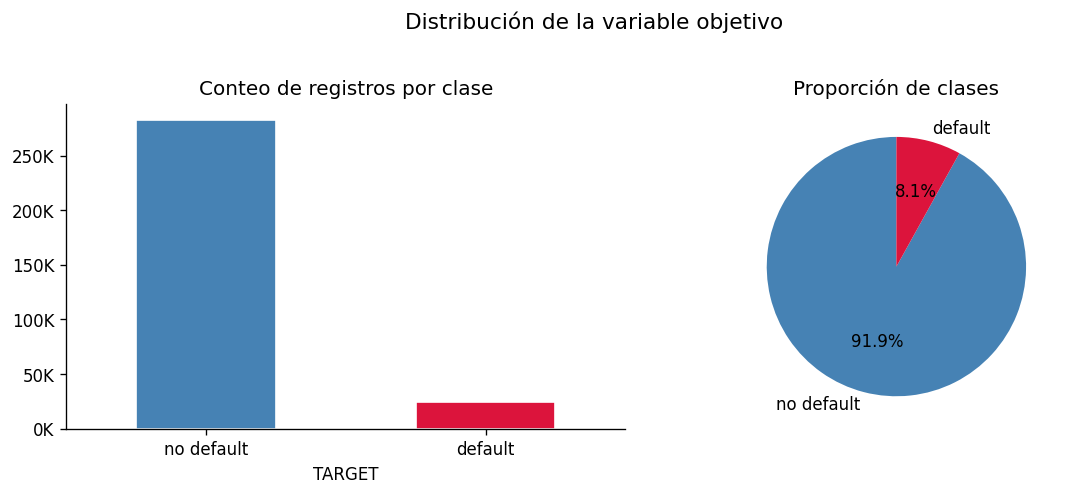

In [6]:
# Defino la variable con el conteo de clases
target_counts = app['TARGET'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Grafico la distribución del target de forma compacta usando Pandas
counts_labeled = target_counts.rename(index={0: 'no default', 1: 'default'})

counts_labeled.plot(kind='bar', ax=axes[0], color=[color_no_default, color_default], edgecolor='white', rot=0)
axes[0].set_title('Conteo de registros por clase')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

counts_labeled.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=[color_no_default, color_default], startangle=90)
axes[1].set_ylabel('')
axes[1].set_title('Proporción de clases')

plt.suptitle('Distribución de la variable objetivo', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


## 3. Verificación de dtypes + verificación IDs

In [7]:
# Clasifico las columnas en numéricas (excluyendo ID y TARGET) y categóricas
feature_num = app.select_dtypes(include=[np.number]).columns.drop(['SK_ID_CURR', 'TARGET'], errors='ignore').tolist()
feature_cat = app.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"numéricas  : {len(feature_num)}")
print(f"categoricas: {len(feature_cat)}")
print(f"target + id: 2")
print(f"total      : {app.shape[1]}")


numéricas  : 104
categoricas: 16
target + id: 2
total      : 122


In [8]:
# Verifico la integridad de los IDs y duplicidad en el dataset
print(f"Total de registros: {len(app):,}")
print(f"IDs nulos (SK_ID_CURR): {app['SK_ID_CURR'].isnull().sum()}")

# Valido los IDs
if app['SK_ID_CURR'].is_unique:
    print("El ID (SK_ID_CURR) es único para todas las obs.")
else:
    dups = app['SK_ID_CURR'].duplicated().sum()
    print(f"Hay {dups} IDs duplicados en el dataset.")

# Valido si existen filas duplicadas
dups_rows = app.duplicated().sum()
if dups_rows == 0:
    print("No existen filas duplicadas en el dataset.")
else:
    print(f"Hay {dups_rows} filas duplicadas.")

Total de registros: 307,511
IDs nulos (SK_ID_CURR): 0
El ID (SK_ID_CURR) es único para todas las obs.


No existen filas duplicadas en el dataset.


In [9]:
# Ejecuto la verificación de tipos inicial
report_inicial = verify_dtypes('application_train', app)
print("Resumen de consistencia de tipos (inicial):")
print(report_inicial['Estado'].value_counts())

print("\nVariables con observaciones detectadas (primeras 10):")
display(report_inicial[report_inicial['Estado'] != 'OK'].head(10))

# Aplico las correcciones de forma segura
# Banderas Y/N a booleano real
for col in ['FLAG_OWN_CAR', 'FLAG_OWN_REALTY']:
    app[col] = app[col].map({'Y': True, 'N': False}).astype(bool)

# Columnas categóricas de baja cardinalidad a tipo 'category'
for col in app.select_dtypes(include='object').columns:
    if app[col].nunique() < 50:
        app[col] = app[col].astype('category')

# Valido de nuevo para verificar los cambios
report_final = verify_dtypes('application_train', app)
print("\nResumen de consistencia de tipos (después de corregir):")
print(report_final['Estado'].value_counts())

# El único warning al final es DAYS_REGISTRATION debido a que su valor decimal anómalo
if not report_final[report_final['Estado'] != 'OK'].empty:
    print("\nObservaciones pendientes:")
    display(report_final[report_final['Estado'] != 'OK'])


Resumen de consistencia de tipos (inicial):
Estado
OK             86
IMPROVEMENT    35
WARNING         1
Name: count, dtype: int64

Variables con observaciones detectadas (primeras 10):


,Variable,Tipo Actual,Categoría Esperada,Estado,Detalle
1,TARGET,uint8,Binary/Flag,IMPROVEMENT,Flag numérico (uint8). Representar como boolea...
4,FLAG_OWN_CAR,category,Binary/Flag,IMPROVEMENT,"Texto Y/N (['N', 'Y']). Convertir a boolean."
5,FLAG_OWN_REALTY,category,Binary/Flag,IMPROVEMENT,"Texto Y/N (['Y', 'N']). Convertir a boolean."
19,DAYS_REGISTRATION,float32,Days/Time,WARNING,Días/conteo contiene decimales reales.
22,FLAG_MOBIL,uint8,Binary/Flag,IMPROVEMENT,Flag numérico (uint8). Representar como boolea...
23,FLAG_EMP_PHONE,uint8,Binary/Flag,IMPROVEMENT,Flag numérico (uint8). Representar como boolea...
24,FLAG_WORK_PHONE,uint8,Binary/Flag,IMPROVEMENT,Flag numérico (uint8). Representar como boolea...
25,FLAG_CONT_MOBILE,uint8,Binary/Flag,IMPROVEMENT,Flag numérico (uint8). Representar como boolea...
26,FLAG_PHONE,uint8,Binary/Flag,IMPROVEMENT,Flag numérico (uint8). Representar como boolea...
27,FLAG_EMAIL,uint8,Binary/Flag,IMPROVEMENT,Flag numérico (uint8). Representar como boolea...



Resumen de consistencia de tipos (después de corregir):
Estado
OK             88
IMPROVEMENT    33
WARNING         1
Name: count, dtype: int64

Observaciones pendientes:


,Variable,Tipo Actual,Categoría Esperada,Estado,Detalle
1,TARGET,uint8,Binary/Flag,IMPROVEMENT,Flag numérico (uint8). Representar como boolea...
19,DAYS_REGISTRATION,float32,Days/Time,WARNING,Días/conteo contiene decimales reales.
22,FLAG_MOBIL,uint8,Binary/Flag,IMPROVEMENT,Flag numérico (uint8). Representar como boolea...
23,FLAG_EMP_PHONE,uint8,Binary/Flag,IMPROVEMENT,Flag numérico (uint8). Representar como boolea...
24,FLAG_WORK_PHONE,uint8,Binary/Flag,IMPROVEMENT,Flag numérico (uint8). Representar como boolea...
25,FLAG_CONT_MOBILE,uint8,Binary/Flag,IMPROVEMENT,Flag numérico (uint8). Representar como boolea...
26,FLAG_PHONE,uint8,Binary/Flag,IMPROVEMENT,Flag numérico (uint8). Representar como boolea...
27,FLAG_EMAIL,uint8,Binary/Flag,IMPROVEMENT,Flag numérico (uint8). Representar como boolea...
34,REG_REGION_NOT_LIVE_REGION,uint8,Binary/Flag,IMPROVEMENT,Flag numérico (uint8). Representar como boolea...
35,REG_REGION_NOT_WORK_REGION,uint8,Binary/Flag,IMPROVEMENT,Flag numérico (uint8). Representar como boolea...


## 4. Análisis de distribuciones de las variables

In [10]:
# Analizo las distribuciones de categóricas y numéricas
print("Distribución variables categóricas")
for col in feature_cat:
    print(f"\nVariable: {col}")
    print(pd.DataFrame({
        "N": app[col].value_counts(dropna=False),
        "Porcentaje": app[col].value_counts(dropna=False, normalize=True) * 100
    }))

print("\nEstadísticos de variables numéricas")
pd.set_option('display.max_rows', 150)
app[feature_num].describe().T

Distribución variables categóricas

Variable: NAME_CONTRACT_TYPE
                         N  Porcentaje
NAME_CONTRACT_TYPE                    
Cash loans          278232     90.4787
Revolving loans      29279      9.5213

Variable: CODE_GENDER
                  N  Porcentaje
CODE_GENDER                    
F            202448     65.8344
M            105059     34.1643
XNA               4      0.0013

Variable: FLAG_OWN_CAR
                   N  Porcentaje
FLAG_OWN_CAR                    
False         202924     65.9892
True          104587     34.0108

Variable: FLAG_OWN_REALTY
                      N  Porcentaje
FLAG_OWN_REALTY                    
True             213312     69.3673
False             94199     30.6327

Variable: NAME_TYPE_SUITE
                      N  Porcentaje
NAME_TYPE_SUITE                    
Unaccompanied    248526     80.8186
Family            40149     13.0561
Spouse, partner   11370      3.6974
Children           3267      1.0624
Other_B            1770   

                           N  Porcentaje
NAME_INCOME_TYPE                        
Working               158774     51.6320
Commercial associate   71617     23.2892
Pensioner              55362     18.0033
State servant          21703      7.0576
Unemployed                22      0.0072
Student                   18      0.0059
Businessman               10      0.0033
Maternity leave            5      0.0016

Variable: NAME_EDUCATION_TYPE
                                    N  Porcentaje
NAME_EDUCATION_TYPE                              
Secondary / secondary special  218391     71.0189
Higher education                74863     24.3448
Incomplete higher               10277      3.3420
Lower secondary                  3816      1.2409
Academic degree                   164      0.0533

Variable: NAME_FAMILY_STATUS
                           N  Porcentaje
NAME_FAMILY_STATUS                      
Married               196432     63.8780
Single / not married   45444     14.7780
Civil marriage 

,count,mean,std,min,25%,50%,75%,max
CNT_CHILDREN,307511.0000,0.4171,0.7221,0.0000,0.0000,0.0000,1.0000,19.0000
AMT_INCOME_TOTAL,307511.0000,168797.9219,237123.1406,25650.0000,112500.0000,147150.0000,202500.0000,117000000.0000
AMT_CREDIT,307511.0000,599025.9375,402490.7812,45000.0000,270000.0000,513531.0000,808650.0000,4050000.0000
AMT_ANNUITY,307499.0000,27108.5723,14493.7373,1615.5000,16524.0000,24903.0000,34596.0000,258025.5000
AMT_GOODS_PRICE,307233.0000,538396.1250,369446.4688,40500.0000,238500.0000,450000.0000,679500.0000,4050000.0000
REGION_POPULATION_RELATIVE,307511.0000,0.0209,0.0138,0.0003,0.0100,0.0189,0.0287,0.0725
DAYS_BIRTH,307511.0000,-16036.9951,4363.9886,-25229.0000,-19682.0000,-15750.0000,-12413.0000,-7489.0000
DAYS_EMPLOYED,307511.0000,63815.0459,141275.7665,-17912.0000,-2760.0000,-1213.0000,-289.0000,365243.0000
DAYS_REGISTRATION,307511.0000,-4986.1201,3522.8862,-24672.0000,-7479.5000,-4504.0000,-2010.0000,0.0000
DAYS_ID_PUBLISH,307511.0000,-2994.2024,1509.4504,-7197.0000,-4299.0000,-3254.0000,-1720.0000,0.0000


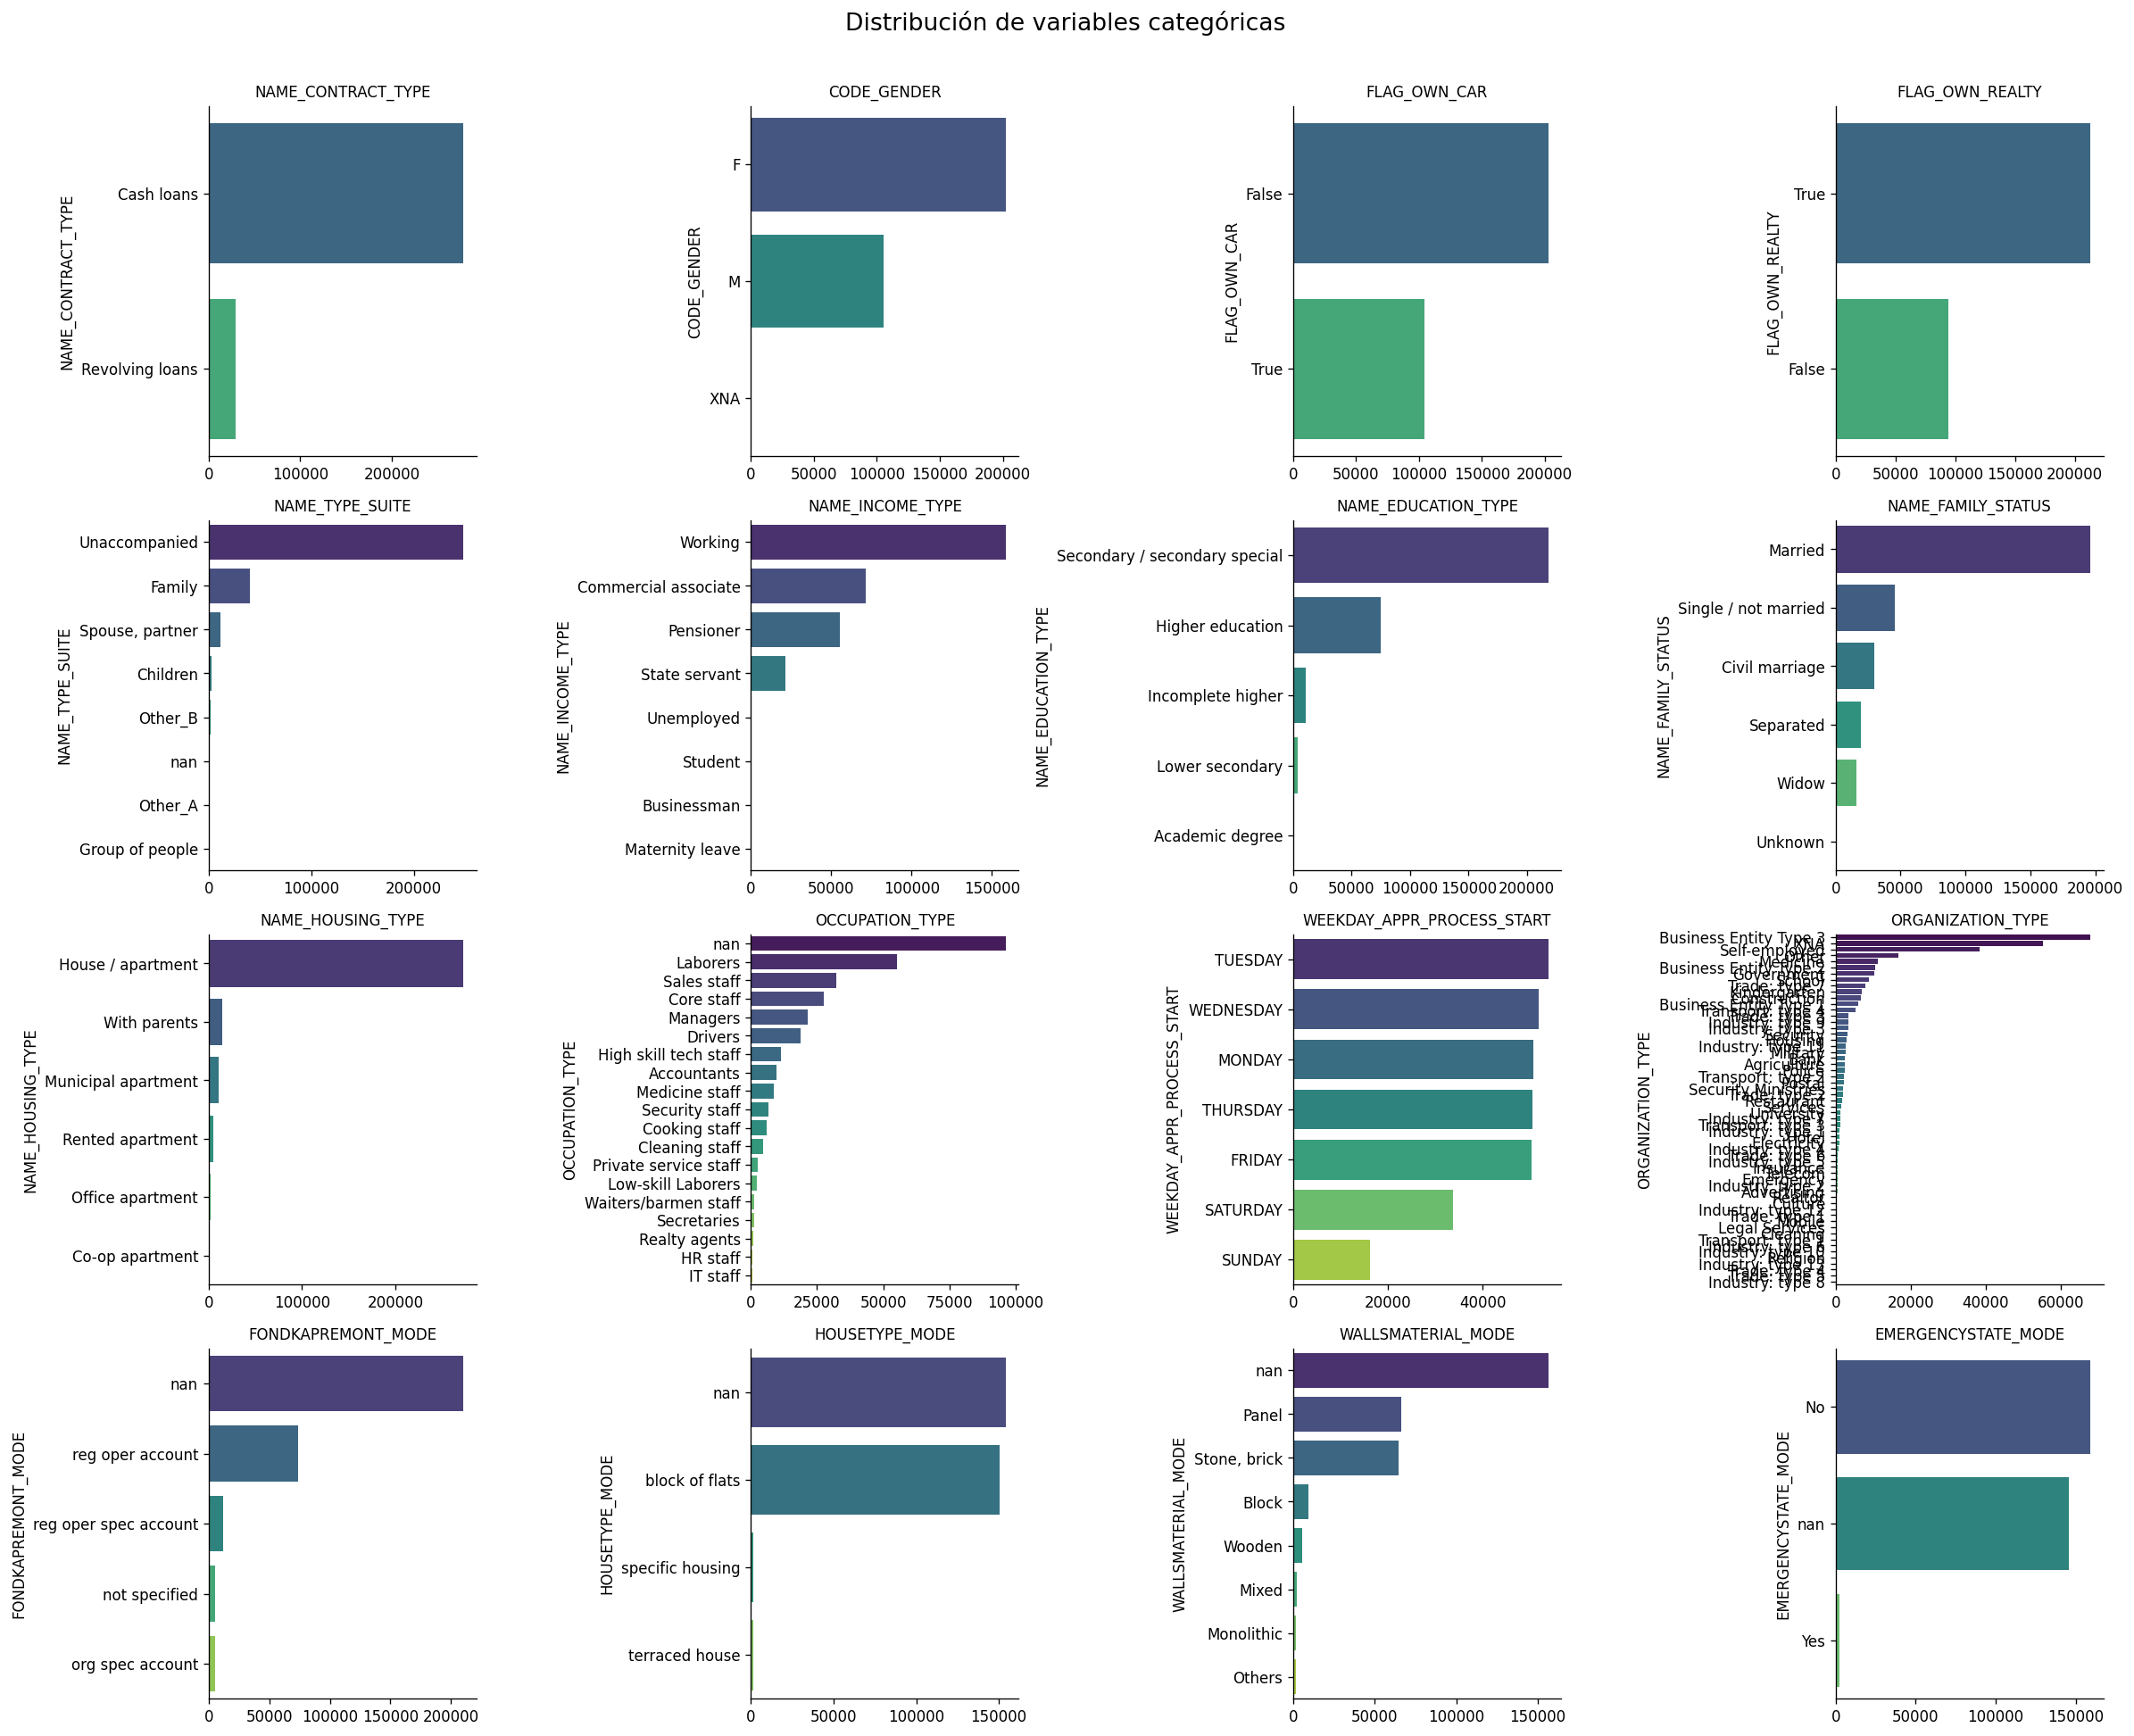

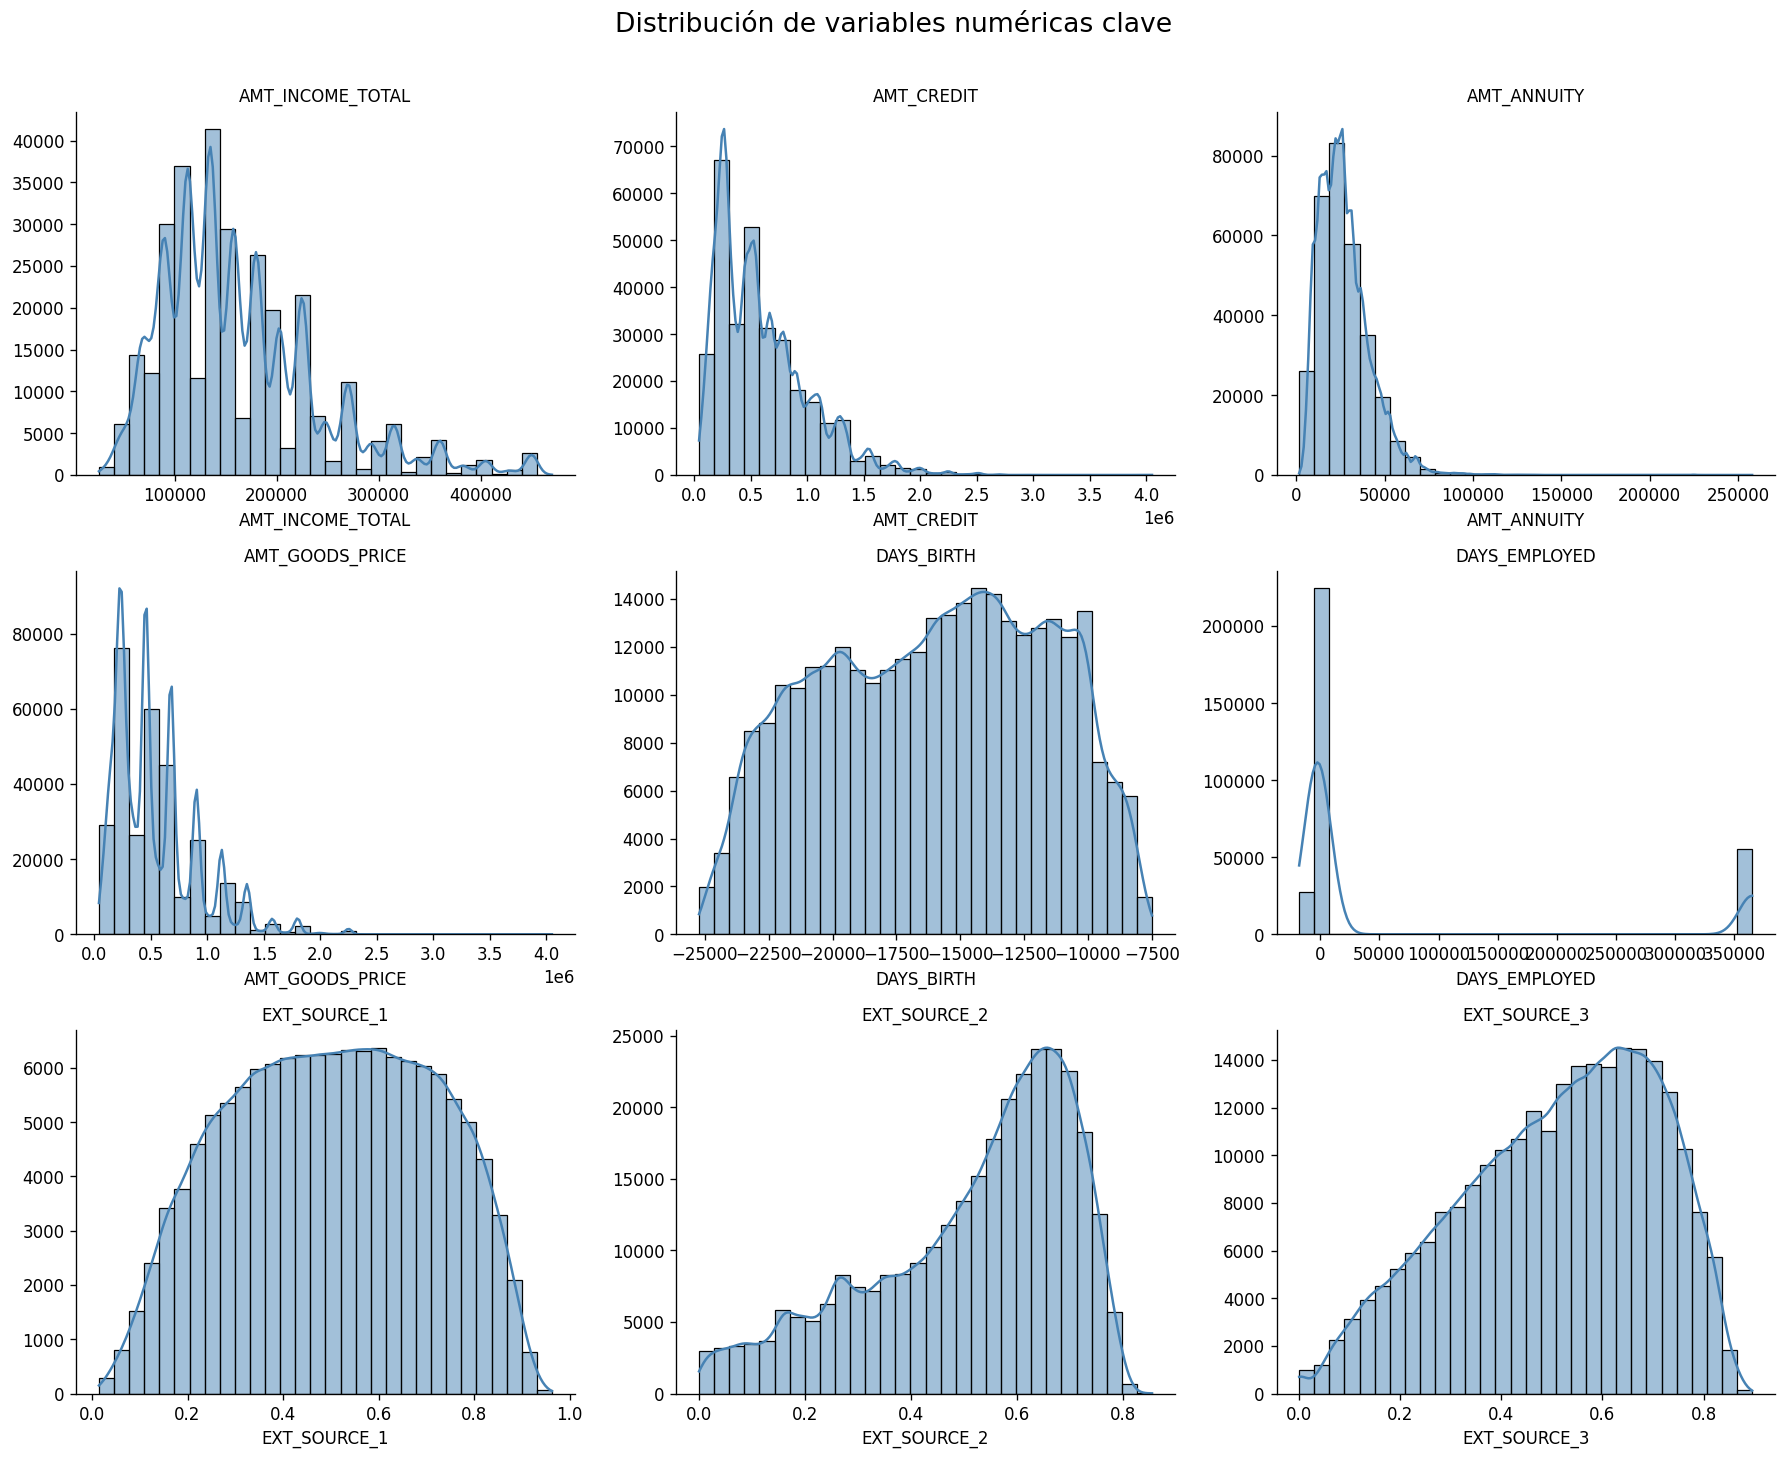

In [11]:
# Grafico las distribuciones de variables categóricas en una cuadrícula
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(feature_cat):
    counts = app[col].value_counts(dropna=False)
    sns.barplot(x=counts.values,
                y=counts.index.astype(str),
                hue=counts.index.astype(str),
                legend=False,
                ax=axes[i], 
                palette='viridis')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

plt.suptitle('Distribución de variables categóricas', y=1.01, fontsize=16)
plt.tight_layout()
plt.show()

# Grafico las distribuciones de variables numéricas clave filtrando valores atípicos
key_num_cols = [
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 
    'DAYS_BIRTH', 'DAYS_EMPLOYED', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3'
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(key_num_cols):
    if col in app.columns:
        data = app[col].dropna()
        # Limito ingresos al percentil 99 para evitar que los valores atípicos aplanen el gráfico
        if col == 'AMT_INCOME_TOTAL':
            data = data[data < data.quantile(0.99)]
        
        sns.histplot(data,
                    kde=True,
                    ax=axes[i], 
                    bins=30, 
                    color=color_no_default)
        axes[i].set_title(col, fontsize=10)
        axes[i].set_ylabel('')

plt.suptitle('Distribución de variables numéricas clave', y=1.01, fontsize=16)
plt.tight_layout()
plt.show()


Conclusiones de las distribuciones de variables categóricas:

- `NAME_CONTRACT_TYPE`: mapeo directamente a binario, Cash Loans = 1, Revolving Loans = 0.

- `CODE_GENDER`: 4 registros con XNA sobre 307K, las elimino directamente para no añadir ruido. Luego binarizo.

- `NAME_TYPE_SUITE`: tiene categorías poco representadas. Calculare la tasa de default por categoría antes de decidir si agrupo. Los nulos (0.42%) los imputare por moda o creo una categoría "Unknown".

- `NAME_INCOME_TYPE`: 4 categorías con menos de 22 registros cada una. Agrupare según tasa de default, no por frecuencia. Calculare la tasa de impago de cada categoría antes de decidir con cuál fusiono cuál.

- `NAME_EDUCATION_TYPE`: el nivel educativo tiene una jerarquía (a mayor educación, generalmente menor riesgo crediticio, por tener mayores oportunidades laborales), por lo que aplicare Ordinal Encoding. Para las categorías poco representadas, voy a ver primero si sus tasas de default son similares entre sí antes de agruparlas.

- `NAME_FAMILY_STATUS`: 2 registros con Unknown sobre 307K, las voy a eliminar directamente. El resto lo codifico via OHE al tener pocas categorías.

- `NAME_HOUSING_TYPE`: 3 categorías poco representadas. Calculare la tasa de default por categoría y agrupare las que tengan tasas similares.

- `WEEKDAY_APPR_PROCESS_START`: binarizare en día de semana vs fin de semana para reducir cardinalidad entre categorías.

- `ORGANIZATION_TYPE`: 58 categorías con mucha granularidad. El criterio de agrupación es la tasa de default como en las demás, no la frecuencia. Dos categorías con 0.1% de frecuencia pero tasas de default muy distintas no las voy a agrupar juntas. Como alternativa si son muy similares todas, puedo agrupar segun  Industry: type X en "Industry", Trade: type X en "Trade", etc. Aplicare WoE encoding en Fase 3.

- `OCCUPATION_TYPE`: misma lógica que `ORGANIZATION_TYPE`, agrupare por tasa de default. Los nulos (31%) los analizare cruzando con `NAME_INCOME_TYPE` para confirmar si corresponden a posibles jubilados que no trabajen y por tanto no puedan rellenar este dato. Si se confirma, los trataré como una categoría explícita "Retired/Unknown".

- `FONDKAPREMONT_MODE`: 68% de nulos. Evaluare si el nulo tiene tasa de default diferente antes de decidir entre eliminar o binarizar.

- `HOUSETYPE_MODE`: 50% de nulos. Misma evaluación.

- `WALLSMATERIAL_MODE`: 50% de nulos. Las 2 categorías principales concentran el 40% restante, el resto tiene representación mínima y agrupare o no dependiendo del análisis.

- `EMERGENCYSTATE_MODE`: 47% de nulos y 51% de "No". Evaluare si el nulo tiene señal real o si simplemente equivale a "No".

Estas 4 variables del edificio solo tienen dato cuando el cliente vive en un bloque de apartamentos urbano. Lo verificaré cruzando `NAME_HOUSING_TYPE` contra los nulos de cada una. Si los nulos se concentran en categorías como "House/apartment" o "With parents", mi suposición quedará confirmada. Crearé un flag binario `HAS_BUILDING_INFO` (1 si cualquier variable del edificio tiene valor, 0 si todas son NaN) y evaluaré si el flag por sí solo captura la señal de riesgo antes de decidir si conservar las variables continuas o quedarme solo con el flag.

Conclusiones análisis de variables numéricas:

**Variables financieras**

En `AMT_INCOME_TOTAL`, `AMT_CREDIT`, `AMT_ANNUITY` y `AMT_GOODS_PRICE` no eliminare sus outliers por IQR porque en un contexto financiero los valores extremos pueden ser reales. Un cliente con ingresos muy altos tiene un perfil de riesgo distinto y el modelo si lo eliminase no lo vería. Tampoco aplicare una transformación logarítmica porque complicaría el pipeline en producción y fallaría si llega un valor de 0. Aplicare capping en p99 como solución estándar: Así conservare la distribución real y solo eliminare los casos que con alta probabilidad son errores de entrada.`AMT_ANNUITY` tiene 12 nulos y `AMT_GOODS_PRICE` 278, imputare ambos por mediana.

**Variables de días**

`DAYS_BIRTH` la convertire a `AGE_YEARS` dividiendo por -365 para que sea interpretable como edad en años. No tiene nulos ni anomalías.

`DAYS_EMPLOYED` tiene el valor 365243 como posible código para jubilados y desempleados. No es un dato real sino una etiqueta disfrazada de número. El flujo que aplicaré es: crear `FLAG_DAYS_EMPLOYED_ANOMALY` con valor 1 cuando sea 365243 y 0 en caso contrario, reemplazar 365243 por NaN, convertir a años, e imputar el NaN resultante por mediana. El flag preserva la señal de que esa persona no tiene empleo activo.

`DAYS_REGISTRATION`, `DAYS_ID_PUBLISH` y `DAYS_LAST_PHONE_CHANGE` no tienen anomalías visibles. El max=0 es válido porque significa que el evento ocurrió el mismo día de la solicitud. Las convertiré a años más adelante

**Scores externos**

`EXT_SOURCE_1` y `EXT_SOURCE_3` tienen nulos MNAR confirmados: la ausencia del score indica que el cliente no tiene historial en el bureau externo y eso en sí mismo es una señal de riesgo. Creo `FLAG_EXT_SOURCE_1_NULL` y `FLAG_EXT_SOURCE_3_NULL` antes de imputar, para que el modelo pueda leer esa señal. Luego imputo ambas con mediana. `EXT_SOURCE_2` tiene solo 0.2% de nulos sin señal MNAR, imputo directamente con mediana.

**Variables de conteo**

En `CNT_CHILDREN` y `CNT_FAM_MEMBERS` aplico capping en p99. El valor del cap no lo decidire por criterio subjetivo sobre lo que me parezca razonable para una familia, sino que lo determino directamente con los datos calculando el percentil 99. Dos nulos en `CNT_FAM_MEMBERS` los elimino directamente.

**Círculo social**

`OBS_30_CNT_SOCIAL_CIRCLE` y `OBS_60_CNT_SOCIAL_CIRCLE` tienen outliers muy severos con máximos de 348 y 344 sobre un p75 de 2. Aplico capping en p99. `DEF_30_CNT_SOCIAL_CIRCLE` y `DEF_60_CNT_SOCIAL_CIRCLE` miden cuántos contactos del cliente han tenido defaults recientemente. Antes de decidir su tratamiento calculo su correlación con TARGET porque intuyo que pueden ser predictivas. Imputo nulos con mediana.

**Consultas al bureau**

`AMT_REQ_CREDIT_BUREAU_QRT` tiene un outlier extremo con max=261 sobre p75=0, aplico capping en p99. Resto de variables del grupo las reviso individualmente e imputo nulos por mediana.

**Variables FLAG de documentos**

`FLAG_MOBIL` tiene media=1.0 y std=0.0018, es prácticamente constante en todo el dataset. Una variable sin varianza no aporta ninguna información al modelo porque no discrimina entre clientes, la elimino. Aplico el mismo criterio a `FLAG_DOCUMENT_2`, 4, 7, 10 y 12 que tienen medias prácticamente 0. Mas adelante usare VarianceThreshold de sklearn para detectar sistemáticamente todas las variables de este tipo en lugar de hacerlo a mano. Para el resto de `FLAG_DOCUMENT` calculo correlación con TARGET antes de decidir.

**Variables de contacto**

`FLAG_EMAIL` tiene 2 nulos que elimino directamente. Para el bloque completo analizo correlación con TARGET para ver cuáles aportan señal real.

**Variables geográficas**

`REGION_RATING_CLIENT` y `REGION_RATING_CLIENT_W_CITY` no presentan anomalías. Para el bloque `REG`/`LIVE` estudiaré mas adelante si se puede reducir a menos variables combinándolas, ya que miden conceptos similares y puede haber redundancia entre ellas.

**Variables del edificio AVG/MODE/MEDI**

Cada variable del edificio aparece en tres versiones con estadísticos prácticamente idénticos. Me quedo con la versión AVG y descarto MODE y MEDI para reducir dimensionalidad. Las versiones AVG conservadas siguen teniendo ~70% de nulos. Imputar con mediana generaría una distribución artificial donde el 70% de registros comparten el mismo valor. La estrategia es: imputar con mediana solo los registros que tienen `HAS_BUILDING_INFO=1` pero les falta alguna columna puntual. Para los registros con `HAS_BUILDING_INFO=0` asigno 0. Si al evaluar correlación con TARGET las variables AVG continuas no aportan señal más allá del flag, las elimino y me quedo solo con `HAS_BUILDING_INFO`.

**Hora de solicitud**

`HOUR_APPR_PROCESS_START` tiene rango 0-23 sin anomalías ni nulos. Agruparé en 3 franjas horarias: mañana (6-12), tarde (12-18) y fuera de horario (18-6). Siguiendo una posible lógica de riesgo crediticio es que alguien que solicita un crédito fuera de horario laboral puede tener un perfil de riesgo distinto. Con 3 franjas reduzco de 24 categorías a 3 sin perder esa señal.

In [12]:
# Analizo las variables categoricas y numericas en base a las conclusiones previas
print("NAME_TYPE_SUITE: Tasa de default por categoria")
display(app.groupby("NAME_TYPE_SUITE", dropna=False, observed=False)["TARGET"].agg(["count", "mean"]).sort_values(by="mean", ascending=False))

print("NAME_INCOME_TYPE: Tasa de default por categoria (ordenado por frecuencia)")
display(app.groupby("NAME_INCOME_TYPE", dropna=False, observed=False)["TARGET"].agg(["count", "mean"]).sort_values(by="count"))

print("NAME_EDUCATION_TYPE: Tasa de default por categoria")
display(app.groupby("NAME_EDUCATION_TYPE", dropna=False, observed=False)["TARGET"].agg(["count", "mean"]).sort_values(by="mean", ascending=False))

print("NAME_HOUSING_TYPE: Tasa de default por categoria")
display(app.groupby("NAME_HOUSING_TYPE", dropna=False, observed=False)["TARGET"].agg(["count", "mean"]).sort_values(by="mean", ascending=False))

print("ORGANIZATION_TYPE: Tasa de default por categoria (top 15)")
display(app.groupby("ORGANIZATION_TYPE", dropna=False, observed=False)["TARGET"].agg(["count", "mean"]).sort_values(by="mean", ascending=False))

print("OCCUPATION_TYPE: Tasa de default por categoria")
display(app.groupby("OCCUPATION_TYPE", dropna=False, observed=False)["TARGET"].agg(["count", "mean"]).sort_values(by="mean", ascending=False))

print("OCCUPATION_TYPE: Porcentaje de nulos por tipo de ingresos")
display(pd.crosstab(app["NAME_INCOME_TYPE"], app["OCCUPATION_TYPE"].isnull(), normalize="index").rename(columns={False: "Tiene ocupacion", True: "Nulo"}) * 100)

print("Variables de edificio _MODE: Tasa de default si es nulo vs presente")
for col in ["FONDKAPREMONT_MODE", "HOUSETYPE_MODE", "WALLSMATERIAL_MODE", "EMERGENCYSTATE_MODE"]:
    print(f"Columna: {col}")
    display(app.groupby(app[col].isnull())["TARGET"].agg(["count", "mean"]).rename(index={True: "Nulo", False: "Presente"}))

print("Relacion entre tipo de vivienda y nulos de APARTMENTS_AVG (%)")
display(pd.crosstab(app["NAME_HOUSING_TYPE"], app["APARTMENTS_AVG"].isnull(), normalize="index").rename(columns={False: "Tiene info", True: "Nulo"}) * 100)

print("Correlacion de las variables de circulo social con TARGET")
display(app[["DEF_30_CNT_SOCIAL_CIRCLE", "DEF_60_CNT_SOCIAL_CIRCLE"]].corrwith(app["TARGET"]))

print("Correlacion de documentos con TARGET")
doc_cols = [c for c in app.columns if c.startswith("FLAG_DOCUMENT_")]
display(app[doc_cols].corrwith(app["TARGET"]).sort_values(ascending=False))

print("Correlacion de variables de contacto con TARGET")
contact_cols = ["FLAG_EMP_PHONE", "FLAG_WORK_PHONE", "FLAG_PHONE", "FLAG_CONT_MOBILE"]
display(app[contact_cols].corrwith(app["TARGET"]).sort_values(ascending=False))

print("Correlacion de variables del edificio AVG con TARGET")
avg_cols = [c for c in app.columns if c.endswith("_AVG")]
display(app[avg_cols].corrwith(app["TARGET"]).sort_values(key=abs, ascending=False))

print("Correlacion entre variables geograficas (redundancia)")
display(app[[
    "REG_REGION_NOT_LIVE_REGION", "REG_REGION_NOT_WORK_REGION", "LIVE_REGION_NOT_WORK_REGION",
    "REG_CITY_NOT_LIVE_CITY", "REG_CITY_NOT_WORK_CITY", "LIVE_CITY_NOT_WORK_CITY"
]].corr().style.background_gradient(cmap="coolwarm", vmin=-1, vmax=1))


NAME_TYPE_SUITE: Tasa de default por categoria


,count,mean
NAME_TYPE_SUITE,,
Other_B,1770,0.0983
Other_A,866,0.0878
Group of people,271,0.0849
Unaccompanied,248526,0.0818
"Spouse, partner",11370,0.0787
Family,40149,0.0749
Children,3267,0.0738
NaN,1292,0.0542


NAME_INCOME_TYPE: Tasa de default por categoria (ordenado por frecuencia)


,count,mean
NAME_INCOME_TYPE,,
Maternity leave,5,0.4000
Businessman,10,0.0000
Student,18,0.0000
Unemployed,22,0.3636
State servant,21703,0.0575
Pensioner,55362,0.0539
Commercial associate,71617,0.0748
Working,158774,0.0959


NAME_EDUCATION_TYPE: Tasa de default por categoria


...

FLAG_EMP_PHONE      0.0460
FLAG_WORK_PHONE     0.0285
FLAG_CONT_MOBILE    0.0004
FLAG_PHONE         -0.0238
dtype: float64

Correlacion de variables del edificio AVG con TARGET


FLOORSMAX_AVG                 -0.0440
ELEVATORS_AVG                 -0.0342
FLOORSMIN_AVG                 -0.0336
LIVINGAREA_AVG                -0.0330
APARTMENTS_AVG                -0.0295
LIVINGAPARTMENTS_AVG          -0.0250
BASEMENTAREA_AVG              -0.0227
YEARS_BUILD_AVG               -0.0221
ENTRANCES_AVG                 -0.0192
COMMONAREA_AVG                -0.0185
NONLIVINGAREA_AVG             -0.0136
LANDAREA_AVG                  -0.0109
YEARS_BEGINEXPLUATATION_AVG   -0.0097
NONLIVINGAPARTMENTS_AVG       -0.0032
dtype: float64

Correlacion entre variables geograficas (redundancia)


,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY
REG_REGION_NOT_LIVE_REGION,1.000000,0.450804,0.088263,0.339232,0.143075,0.009838
REG_REGION_NOT_WORK_REGION,0.450804,1.000000,0.860627,0.151397,0.239765,0.197097
LIVE_REGION_NOT_WORK_REGION,0.088263,0.860627,1.000000,0.021076,0.185863,0.236635
REG_CITY_NOT_LIVE_CITY,0.339232,0.151397,0.021076,1.000000,0.440409,0.028112
REG_CITY_NOT_WORK_CITY,0.143075,0.239765,0.185863,0.440409,1.000000,0.825575
LIVE_CITY_NOT_WORK_CITY,0.009838,0.197097,0.236635,0.028112,0.825575,1.000000


**Recordatorio sobre target leakage**: Todas las tasas de default mostradas en el output anterior están calculadas sobre `application_train` completo, lo uso solo para tomar decisiones de EDA así como para entender el Dataset. En el futuro, cuando implemente las agrupaciones y encodings basados en estas tasas, los cálculos deberé rehacerlos exclusivamente sobre el split de entrenamiento. Ya que si calculas los estadísticos que dependan del TARGET con el dataset completo introduciría target leakage.

---

`NAME_TYPE_SUITE`: Las tasas son bastante homogéneas entre categorías, pero los NaN destacan con la más baja (5.42%), una diferencia de aproximadamente 2.7 p.p sobre el resto. Que falte el dato no parece aleatorio, asique en vez de imputar por moda lo trataré como categoría "Unknown" para preservar la señal. Other_A (8.78%) y Other_B (9.83%) tienen poca representación y tasas similares, las agruparé en "Other_High". Children (7.38%) y Family (7.49%) son prácticamente idénticas, las fusionaré de igual manera. Spouse/partner (7.87%) queda en zona intermedia y con 11K obs tiene representación suficiente para mantenerla sola.

`NAME_INCOME_TYPE`: Maternity (40%) y Unemployed (36.4%) son alto riesgo mientras que Businessman (0%) y Student (0%) son bajo riesgo. Tienen perfiles opuestos por lo que no las puedo juntar todas, pero con 5-22 obs cada una las tasas son ruido estadístico y por tanto las agruparé manualmente en "High Risk Other" (Maternity + Unemployed) y "Low Risk Other" (Businessman + Student) ya que sino el modelo se va a obsesionar con ellas. 

Si agrupo por tasa de default observada es leakage si el cálculo no se hace solo sobre el split de entrenamiento. La asignación de qué va a "High Risk" y qué a "Low Risk" la calculare unicamente con train.

`NAME_EDUCATION_TYPE`: La hipótesis que plantee anteriormente se confirma, a mayor educación menor default (de 1.83% en Academic degree a 10.93% en Lower secondary), con orden perfectamente monótono. Aplicare Ordinal Encoding con jerarquía 1-5 para conservar esa relación. No agruparé ninguna categoría porque cada nivel tiene tasa diferenciada que el modelo debera ver.

`NAME_HOUSING_TYPE`: Rented apartment (12.31%) y With parents (11.70%) destacan como alto riesgo con  aproximadamente 5 p.p sobre la media. Pueden reflejar una menor estabilidad financiera o falta de avales/colaterales y tienen frecuencia suficiente para mantenerlas separadas. Co-op apartment (7.93%) y House/apartment (7.80%) son prácticamente idénticas y las fusionaré. Office apartment (6.57%) es la de menor riesgo y la mantendre sola. Municipal apartment (8.54%) queda en una zona intermedia y la dejaré igualmente sola.

`ORGANIZATION_TYPE`: El rango de tasas va de 3.12% a 15.75% y es extremadamente variable dentro del mismo sector (Industry type 13 con 13.43% vs Industry type 12 con 3.79%), por lo que agrupar por sector como propuse anteriormente destruiría señal. Así que aplicaré WoE encoding directamente en el preprocesado para que suavice automáticamente las categorías con pocas observaciones.

`OCCUPATION_TYPE`: El efecto que anticipe sobre jubilado queda confirmado: Pensioner tiene 99.99% de nulos en `OCCUPATION_TYPE` y Unemployed el 100%. Por lo tanto, los NaN no son errores sino información estructural, los trataré como categoría explícita "Retired/Inactive".

Identifico tres grupos por tasa de default:
- Alto riesgo (>10%): Low-skill Laborers, Drivers, Waiters/barmen, Security staff, Laborers, Cooking staff.
- Medio (8-10%): Sales staff, Cleaning staff.
- Bajo (<7%): Realty agents, Secretaries, Medicine staff, Private service staff, NaN/Retired, IT staff, HR staff, Core staff, Managers, High skill tech staff, Accountants.

Tendré en cuenta el leakage en `NAME_INCOME_TYPE`. La asignación de cada categoría a su grupo de riesgo la calcularé unicamente solo sobre el split de entrenamiento.

`FONDKAPREMONT_MODE`, `HOUSETYPE_MODE`, `WALLSMATERIAL_MODE`, `EMERGENCYSTATE_MODE`: Las 4 muestran el mismo patrón: con valor nulo la tasa de default ronda el 9% y con valor presente el 7%. Diferencia consistente de  aproximadamente 2 p.p en las 4. Esto confirma que el nulo son MNAR y tienen señal predictiva, por lo que creare HAS_BUILDING_INFO para capturarla de forma unificada.

No eliminaré aún las 4 variables originales. Ya que el nulo aunque aporte señal no significa que las categorías cuando hay valor no aporten señal adicional. Son cosas distintas: el flag capturará la señal del missing, las categorías presentes capturararán así una señal extra. La decisión final de eliminar o conservar se toma más adelante con el IV de cada una.

`APARTMENTS_AVG` cruzada con `NAME_HOUSING_TYPE`: Los nulos NO están distribuidos uniformemente (Rented apartment 66.4% vs Municipal apartment 36.1%, diferencia de 30 p.p). Sin embargo ningún tipo de vivienda tiene información completa, todos superan el 36% de nulos, por lo que una imputación condicional por tipo de vivienda no es viable. Esto refuerza usar la variable que propuso anteriormente (`HAS_BUILDING_INFO`) en vez de imputar de forma compleja.

`DEF_30_CNT_SOCIAL_CIRCLE` y `DEF_60_CNT_SOCIAL_CIRCLE`: Tienen correlaciones bajas pero positivas con la variable objetivo (0.032 y 0.031). Lo que se asemeja con la lógica de "contagio social": más contactos del círculo en default se asocia a un mayor riesgo por parte del individuo ha hacer default. No las eliminaré, ya que pueden aportar en combinación con otras variables en modelos de árboles. Así que imputaré los nulos con mediana y aplicaré un capping en p99 para evitar valores absurdos que puedan distorsionar los modelos.

`FLAG_DOCUMENT_x`: La mayoría tienen correlación prácticamente nula con la variable objetivo, por lo que son ruido y candidatas a eliminación. Entre ellas destacan dos: `FLAG_DOCUMENT_3` con correlación positiva (0.0443) y `FLAG_DOCUMENT_6` con negativa (-0.0286). Si le tuviese que dar un sentido practico seria que entregar uno u otro se asociaría con perfiles de riesgo distintos. Por lo que aplicaré VarianceThreshold en las fases siguientes para eliminar las de baja varianza automáticamente y conservar al menos `FLAG_DOCUMENT_3` y `FLAG_DOCUMENT_6` para evaluarlas con IV.

`Variables del edificio AVG`: Todas tienen una correlación negativa con la variable objetivo, la mayor en valor absoluto es `FLOORSMAX_AVG` (-0.044). El patrón tiene lógica: es decir edificios más grandes suelen estar en zonas urbanas mejores situadas, asociadas a menor riesgo. Las correlaciones individuales son bajas por lo que si ninguna  de las variables supera el umbral mínimo de significancia en el futuro las eliminaré y me quedaré solo con `HAS_BUILDING_INFO`.

`Variables de contacto`: Todas presentan correlaciones bajas. `FLAG_EMP_PHONE` (0.046) es la más correlada positivamente con la variable objetivo. La interpretación más adecuada en este caso no sería que "tener teléfono de trabajo es malo" sino que `FLAG_EMP_PHONE` es una variable que señaliza el empleo activo: esto se debe a que lo tienen los Working (9.6% default) y no los Pensioner (5.4% default). Los pensionistas no tienen teléfono de empresa pero tienen ingresos garantizados por el Estado, lo que reduce su default. La correlación refleja que la población empleada es más joven, con más deudas en curso y menos ahorros que la jubilada. `FLAG_PHONE` (-0.024) se asocia a menor riesgo, posible señal de estabilidad residencial. Mientras que `FLAG_CONT_MOBILE` (0.0004) es prácticamente nula, lo que la hace candidata a eliminación. Mas adelante evaluaré todas con IV.

`Variables geográficas REG/LIVE`: Existen dos pares redundantes en base a su correlación:
- `REG_REGION_NOT_WORK_REGION` y `LIVE_REGION_NOT_WORK_REGION`: 86%.
- `REG_CITY_NOT_WORK_CITY` y `LIVE_CITY_NOT_WORK_CITY`: 82.6%.

De cada par me quedaré con una sola. Para decidir cuál calcularé el IV de ambas más adelante y mantendremos aquellas con mayor poder predictivo.

In [13]:
# Muestro la recomendación de codificación automática según las conclusiones del EDA, sobre la cardinalidad de var. categóricas
recomendar_codificacion(app).set_index("Variable").style.set_table_styles([
    dict(selector="th, td", props=[("text-align", "left")])
])

,Categorías,Cardinalidad,Estrategia Recomendada,Detalle
Variable,,,,
CODE_GENDER,"['F', 'M', 'XNA']",3,Binary Mapping / Clean,Eliminar registros con 'XNA' (solo 4 registros) y binarizar ('M'/'F').
EMERGENCYSTATE_MODE,"['No', 'Yes']",2,Binary Mapping / Drop,"47% de nulos. Evaluar si el nulo equivale a 'No' o si tiene tasa de default diferencial, luego binarizar (Nulo vs No Nulo)."
FLAG_CONT_MOBILE,"[np.uint8(0), np.uint8(1)]",2,Conservar como binaria,Ya es una variable numérica binaria 0/1.
FLAG_DOCUMENT_10,"[np.uint8(0), np.uint8(1)]",2,Eliminar / Baja Varianza,Candidata a eliminación por baja varianza y correlación insignificante con TARGET.
FLAG_DOCUMENT_11,"[np.uint8(0), np.uint8(1)]",2,Eliminar / Baja Varianza,Candidata a eliminación por baja varianza y correlación insignificante con TARGET.
FLAG_DOCUMENT_12,"[np.uint8(0), np.uint8(1)]",2,Eliminar / Baja Varianza,Candidata a eliminación por baja varianza y correlación insignificante con TARGET.
FLAG_DOCUMENT_13,"[np.uint8(0), np.uint8(1)]",2,Eliminar / Baja Varianza,Candidata a eliminación por baja varianza y correlación insignificante con TARGET.
FLAG_DOCUMENT_14,"[np.uint8(0), np.uint8(1)]",2,Eliminar / Baja Varianza,Candidata a eliminación por baja varianza y correlación insignificante con TARGET.
FLAG_DOCUMENT_15,"[np.uint8(0), np.uint8(1)]",2,Eliminar / Baja Varianza,Candidata a eliminación por baja varianza y correlación insignificante con TARGET.


Después de observar las cardinalidad y las tasas de default, tomaré las siguientes decisiones de codificación para más adelante:

- **Binarización Directa**: `NAME_CONTRACT_TYPE`, `FLAG_OWN_CAR` y `FLAG_OWN_REALTY` se mapearán a 0/1 al ser estrictamente binarias. Para `CODE_GENDER`, se eliminarán primero los 4 registros `XNA` antes de proceder al mapeo binario de 'M'/'F'.
- **Variables Binarias Conceptuales (`FLAG_OWN_CAR`, `FLAG_OWN_REALTY` y `FLAG_DOCUMENT_X`)**: Se conservarán como binarias `FLAG_OWN_CAR` y `FLAG_OWN_REALTY`. Para los documentos (`FLAG_DOCUMENT_X`), se filtrarán mediante un umbral de varianza (VarianceThreshold) para eliminar aquellas de baja varianza por ser ruido, conservando únicamente las significativas (`FLAG_DOCUMENT_3` y `FLAG_DOCUMENT_6`).
- **Reducción de Cardinalidad Dinámica**: `WEEKDAY_APPR_PROCESS_START` se simplificará binarizando en día de semana (ej:'1') vs. fin de semana (ej:'0') para evitar inflar la dimensionalidad.
- **Codificación Ordinal**: `NAME_EDUCATION_TYPE` se codificará de forma ordinal respetando la jerarquía lógica observada (a mayor nivel educativo, menor riesgo de default).
- **One-Hot Encoding**: Para variables con categorías de muy baja frecuencia (`NAME_TYPE_SUITE`, `NAME_INCOME_TYPE`, `NAME_HOUSING_TYPE` y `NAME_FAMILY_STATUS`), se eliminarán primero las obs marginales o NaN. Específicamente, para `NAME_FAMILY_STATUS` se descartarán los 2 registros `Unknown` identificados en el análisis previo. Luego se agruparán las categorías minoritarias en base a la similitud de su tasa de default de entrenamiento, aplicando posteriormente One-Hot.
- **Codificación por Weight of Evidence (WoE)**:
  - `ORGANIZATION_TYPE` (58 categorías): Debido a su alta granularidad y la variabilidad extrema de la tasa de default incluso dentro de un mismo sector, se las aplicará codificación WoE.
  - `OCCUPATION_TYPE` (18 categorías + 31% nulos): Se considerará la categoría nula como "Retired/Inactive" tras el cruce con el tipo de ingresos, y se agruparán las ocupaciones en tres franjas de riesgo (Alto, Medio, Bajo) según su tasa de default de entrenamiento, codificando mediante Target Encoding.
- **Variables del Edificio (`FONDKAPREMONT_MODE`, `HOUSETYPE_MODE`, `WALLSMATERIAL_MODE`, `EMERGENCYSTATE_MODE`)**: El alto volumen de nulos (MNAR) y su comportamiento de riesgo diferencial refuerza la creación del flag unificado `HAS_BUILDING_INFO` (1 si contiene datos del edificio, 0 en caso contrario) antes de binarizar o descartar sus categorías presentes.

## 5. Análisis de Missings

In [14]:
# Cálculo estadísticas de nulos de forma robusta a outliers (mediana) y adaptando las categóricas (moda)
# Vectorizo el cálculo de tasas de default para todas las columnas usando producto punto de la máscara de nulos para reducir el tiempo computacional.
# Casteo la variable TARGET a int para evitar el problema de overflow de tipo int8 al sumar aprox 24K registros.
cols_con_nulos = [col for col in app.columns if app[col].isnull().any()]

# Obtengo la máscara de nulos y sus porcentajes
null_mask = app[cols_con_nulos].isnull()
n_nulos = null_mask.sum()
pct_nulos = (n_nulos / len(app)) * 100

# Vectorizo el cálculo de la tasa de default
target_ints = app['TARGET'].astype(int)
tasa_nulo_all = null_mask.T.dot(target_ints) / n_nulos
tasa_presente_all = (~null_mask).T.dot(target_ints) / (len(app) - n_nulos)

# Clasifico en bloques para el posterior análisis
def get_bloque(col):
    if col in {"FONDKAPREMONT_MODE", "HOUSETYPE_MODE", "WALLSMATERIAL_MODE", "EMERGENCYSTATE_MODE"}:
        return "Edificio (cat.)"
    base = col.rsplit('_', 1)[0] if col.endswith(('_AVG', '_MEDI', '_MODE')) else col
    if base in {
        'APARTMENTS', 'BASEMENTAREA', 'YEARS_BEGINEXPLUATATION', 'YEARS_BUILD',
        'COMMONAREA', 'ELEVATORS', 'ENTRANCES', 'FLOORSMAX', 'FLOORSMIN',
        'LANDAREA', 'LIVINGAPARTMENTS', 'LIVINGAREA', 'NONLIVINGAPARTMENTS',
        'NONLIVINGAREA', 'TOTALAREA'
    }:
        return "Edificio (num.)"
    if col.startswith('AMT_REQ_CREDIT_BUREAU'):
        return "Buró de Crédito"
    if 'SOCIAL_CIRCLE' in col:
        return "Círculo Social"
    if col.startswith('EXT_SOURCE'):
        return "Score Externo"
    return "Individual"

stats_nulos = []
for col in cols_con_nulos:
    es_nulo = null_mask[col]
    n_n = n_nulos[col]
    pct_n = pct_nulos[col]
    t_nulo = tasa_nulo_all[col]
    t_presente = tasa_presente_all[col]
    
    # Segmento datos con valor presente por variable objetivo
    present_t0 = app.loc[~es_nulo & (app['TARGET'] == 0), col]
    present_t1 = app.loc[~es_nulo & (app['TARGET'] == 1), col]
    
    if pd.api.types.is_numeric_dtype(app[col]):
        # Calculo la ediana para numéricas
        val_t0 = present_t0.median()
        val_t1 = present_t1.median()
        tipo_medida = "Mediana"
    else:
        # Obtengo la moda para categóricas
        mode_t0 = present_t0.mode()
        mode_t1 = present_t1.mode()
        val_t0 = mode_t0.iloc[0] if not mode_t0.empty else np.nan
        val_t1 = mode_t1.iloc[0] if not mode_t1.empty else np.nan
        tipo_medida = "Moda"
        
    stats_nulos.append({
        "Nombre de la variable": col,
        "Bloque": get_bloque(col),
        "Número de nulos": n_n,
        "Porcentaje de nulos": pct_n,
        "Tasa de default cuando el valor es nulo": t_nulo,
        "Tasa de default cuando el valor está presente": t_presente,
        "Diferencia entre las dos tasas anteriores": t_nulo - t_presente,
        "Tipo de medida central": tipo_medida,
        "Valor central en TARGET=0": val_t0,
        "Valor central en TARGET=1": val_t1
    })

# Filtro el reporte para mostrar únicamente la versión _AVG para variables del edificio, 
# evitando así el ruido de variables redundantes (ej:_MODE y _MEDI).
df_stats_nulos = pd.DataFrame(stats_nulos)
df_stats_nulos = df_stats_nulos[
    ~df_stats_nulos["Nombre de la variable"].str.endswith(("_MODE", "_MEDI")) |
    df_stats_nulos["Nombre de la variable"].isin(["FONDKAPREMONT_MODE", "HOUSETYPE_MODE", "WALLSMATERIAL_MODE", "EMERGENCYSTATE_MODE"])
]

# Muestro las tablas por bloque de forma individual
bloques_ordenados = ["Score Externo", "Buró de Crédito", "Círculo Social", "Edificio (num.)", "Edificio (cat.)", "Individual"]
for bloque in bloques_ordenados:
    df_bloque = df_stats_nulos[df_stats_nulos["Bloque"] == bloque].copy()
    if not df_bloque.empty:
        display(HTML(f"<h3>Bloque: {bloque}</h3>"))
        df_bloque_clean = df_bloque.drop(columns=["Bloque"]).sort_values(
            by="Diferencia entre las dos tasas anteriores", ascending=False
        )
        display(df_bloque_clean)

,Nombre de la variable,Número de nulos,Porcentaje de nulos,Tasa de default cuando el valor es nulo,Tasa de default cuando el valor está presente,Diferencia entre las dos tasas anteriores,Tipo de medida central,Valor central en TARGET=0,Valor central en TARGET=1
8,EXT_SOURCE_3,60965,19.8253,0.0931,0.0777,0.0155,Mediana,0.5460,0.3791
6,EXT_SOURCE_1,173378,56.3811,0.0852,0.0750,0.0102,Mediana,0.5175,0.3617
7,EXT_SOURCE_2,660,0.2146,0.0788,0.0807,-0.0019,Mediana,0.5739,0.4404


,Nombre de la variable,Número de nulos,Porcentaje de nulos,Tasa de default cuando el valor es nulo,Tasa de default cuando el valor está presente,Diferencia entre las dos tasas anteriores,Tipo de medida central,Valor central en TARGET=0,Valor central en TARGET=1
61,AMT_REQ_CREDIT_BUREAU_HOUR,41519,13.5016,0.1034,0.0772,0.0262,Mediana,0.0000,0.0000
62,AMT_REQ_CREDIT_BUREAU_DAY,41519,13.5016,0.1034,0.0772,0.0262,Mediana,0.0000,0.0000
63,AMT_REQ_CREDIT_BUREAU_WEEK,41519,13.5016,0.1034,0.0772,0.0262,Mediana,0.0000,0.0000
64,AMT_REQ_CREDIT_BUREAU_MON,41519,13.5016,0.1034,0.0772,0.0262,Mediana,0.0000,0.0000
65,AMT_REQ_CREDIT_BUREAU_QRT,41519,13.5016,0.1034,0.0772,0.0262,Mediana,0.0000,0.0000
66,AMT_REQ_CREDIT_BUREAU_YEAR,41519,13.5016,0.1034,0.0772,0.0262,Mediana,1.0000,2.0000


,Nombre de la variable,Número de nulos,Porcentaje de nulos,Tasa de default cuando el valor es nulo,Tasa de default cuando el valor está presente,Diferencia entre las dos tasas anteriores,Tipo de medida central,Valor central en TARGET=0,Valor central en TARGET=1
56,OBS_30_CNT_SOCIAL_CIRCLE,1021,0.3320,0.0353,0.0809,-0.0456,Mediana,0.0000,0.0000
57,DEF_30_CNT_SOCIAL_CIRCLE,1021,0.3320,0.0353,0.0809,-0.0456,Mediana,0.0000,0.0000
58,OBS_60_CNT_SOCIAL_CIRCLE,1021,0.3320,0.0353,0.0809,-0.0456,Mediana,0.0000,0.0000
59,DEF_60_CNT_SOCIAL_CIRCLE,1021,0.3320,0.0353,0.0809,-0.0456,Mediana,0.0000,0.0000


,Nombre de la variable,Número de nulos,Porcentaje de nulos,Tasa de default cuando el valor es nulo,Tasa de default cuando el valor está presente,Diferencia entre las dos tasas anteriores,Tipo de medida central,Valor central en TARGET=0,Valor central en TARGET=1
15,ENTRANCES_AVG,154828,50.3488,0.0918,0.0695,0.0223,Mediana,0.1379,0.1379
16,FLOORSMAX_AVG,153020,49.7608,0.0919,0.0697,0.0223,Mediana,0.1667,0.1667
11,YEARS_BEGINEXPLUATATION_AVG,150007,48.7810,0.0920,0.0699,0.0221,Mediana,0.9821,0.9811
14,ELEVATORS_AVG,163891,53.2960,0.0910,0.0690,0.0220,Mediana,0.0000,0.0000
9,APARTMENTS_AVG,156061,50.7497,0.0915,0.0696,0.0219,Mediana,0.0887,0.0825
20,LIVINGAREA_AVG,154350,50.1933,0.0914,0.0700,0.0215,Mediana,0.0752,0.0667
22,NONLIVINGAREA_AVG,169682,55.1792,0.0903,0.0689,0.0215,Mediana,0.0036,0.0028
10,BASEMENTAREA_AVG,179943,58.5160,0.0891,0.0689,0.0202,Mediana,0.0765,0.0723
18,LANDAREA_AVG,182590,59.3767,0.0882,0.0698,0.0184,Mediana,0.0484,0.0449
12,YEARS_BUILD_AVG,204488,66.4978,0.0868,0.0687,0.0181,Mediana,0.7552,0.7484


,Nombre de la variable,Número de nulos,Porcentaje de nulos,Tasa de default cuando el valor es nulo,Tasa de default cuando el valor está presente,Diferencia entre las dos tasas anteriores,Tipo de medida central,Valor central en TARGET=0,Valor central en TARGET=1
55,EMERGENCYSTATE_MODE,145755,47.3983,0.0926,0.0700,0.0226,Moda,No,No
52,HOUSETYPE_MODE,154297,50.1761,0.0915,0.0699,0.0216,Moda,block of flats,block of flats
54,WALLSMATERIAL_MODE,156341,50.8408,0.0913,0.0698,0.0215,Moda,Panel,"Stone, brick"
51,FONDKAPREMONT_MODE,210295,68.3862,0.0862,0.0689,0.0173,Moda,reg oper account,reg oper account


,Nombre de la variable,Número de nulos,Porcentaje de nulos,Tasa de default cuando el valor es nulo,Tasa de default cuando el valor está presente,Diferencia entre las dos tasas anteriores,Tipo de medida central,Valor central en TARGET=0,Valor central en TARGET=1
3,OWN_CAR_AGE,202929,65.9908,0.0850,0.0724,0.0126,Mediana,9.0000,11.0000
1,AMT_GOODS_PRICE,278,0.0904,0.0755,0.0807,-0.0052,Mediana,450000.0000,450000.0000
4,OCCUPATION_TYPE,96391,31.3455,0.0651,0.0879,-0.0227,Moda,Laborers,Laborers
2,NAME_TYPE_SUITE,1292,0.4201,0.0542,0.0808,-0.0267,Moda,Unaccompanied,Unaccompanied
60,DAYS_LAST_PHONE_CHANGE,1,0.0003,0.0000,0.0807,-0.0807,Mediana,-776.0000,-594.0000
5,CNT_FAM_MEMBERS,2,0.0007,0.0000,0.0807,-0.0807,Mediana,2.0000,2.0000
0,AMT_ANNUITY,12,0.0039,0.0000,0.0807,-0.0807,Mediana,24876.0000,25263.0000


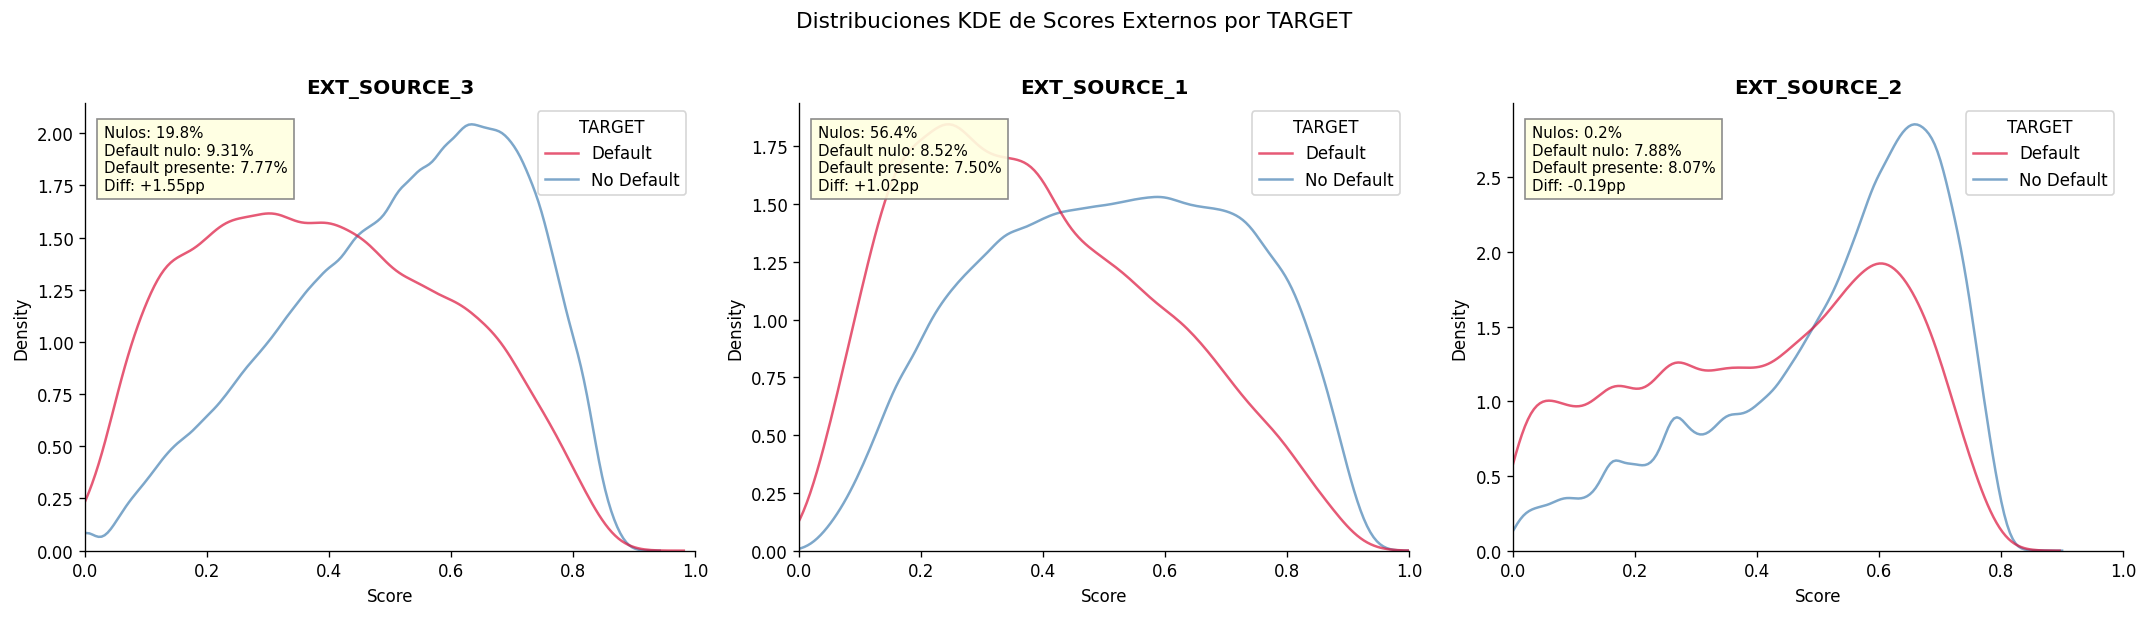

,Mann-Whitney U (p-valor),Chi-Cuadrado (p-valor),Resultado
Variable,,,
EXT_SOURCE_3,0.0000e+00,4.8895e-36,Altamente Significativo
EXT_SOURCE_1,0.0000e+00,5.1392e-25,Altamente Significativo
EXT_SOURCE_2,0.0000e+00,9.1105e-01,Diferencia parcial


In [15]:
# Visualización Bloque Score Externo: KDE por TARGET con nulos
# Uso sns.kdeplot para vectorizar curvas por TARGET y agrupo las tasas.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ext_cols = ['EXT_SOURCE_3', 'EXT_SOURCE_1', 'EXT_SOURCE_2']

for i, col in enumerate(ext_cols):
    sns.kdeplot(
        data=app, x=col, hue=app['TARGET'].map({0: 'No Default', 1: 'Default'}),
        common_norm=False, ax=axes[i], palette={'No Default': color_no_default, 'Default': color_default},
        alpha=0.7
    )
    
    pct_null = app[col].isnull().mean() * 100
    t_pres, t_nulo = app.groupby(app[col].isnull())['TARGET'].mean() * 100
    
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].annotate(
        f'Nulos: {pct_null:.1f}%\nDefault nulo: {t_nulo:.2f}%\nDefault presente: {t_pres:.2f}%\nDiff: {t_nulo - t_pres:+.2f}pp',
        xy=(0.03, 0.95), xycoords='axes fraction', fontsize=9, va='top',
        bbox=dict(facecolor='lightyellow', alpha=0.9, edgecolor='gray')
    )
    axes[i].set_xlabel('Score')
    axes[i].set_xlim(0, 1)

plt.suptitle('Distribuciones KDE de Scores Externos por TARGET', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Contrastes estadísticos
stats_list = []
for col in ext_cols:
    present = app[app[col].notnull()]
    mw_stat, p_mw = mannwhitneyu(present.loc[present['TARGET'] == 0, col], present.loc[present['TARGET'] == 1, col], alternative='two-sided')
    ct = pd.crosstab(app[col].isnull(), app['TARGET'])
    chi2, p_chi2, _, _ = chi2_contingency(ct)
    stats_list.append({
        'Variable': col,
        'Mann-Whitney U (p-valor)': p_mw,
        'Chi-Cuadrado (p-valor)': p_chi2,
        'Resultado': 'Altamente Significativo' if (p_mw < 0.01 and p_chi2 < 0.01) else 'Diferencia parcial'
    })
df_stats = pd.DataFrame(stats_list).set_index('Variable')
display(df_stats.style.format({'Mann-Whitney U (p-valor)': '{:.4e}', 'Chi-Cuadrado (p-valor)': '{:.4e}'}))


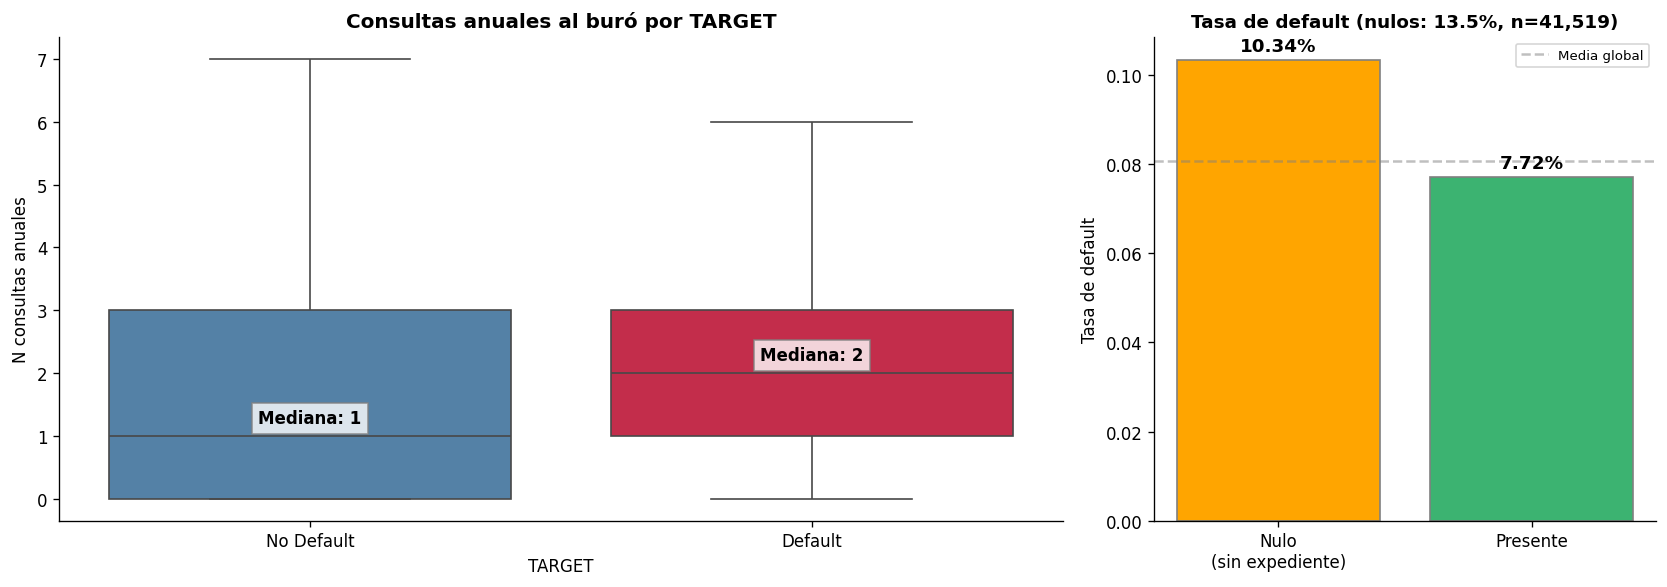

,Método,p-valor,Resultado
Contraste de Hipótesis,,,
Diferencia de consultas anuales al buró por TARGET,Mann-Whitney U,1.0514e-23,Significativo (Rechaza indep.)
Asociación entre ausencia de expediente (nulo) y TARGET,Chi-Cuadrado de Independencia,4.9156e-74,Significativo (Rechaza indep.)


In [16]:
# Visualización Buró de Crédito: Boxplot YEAR por TARGET y Tasa default nulo vs presente
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [2, 1]})

col = 'AMT_REQ_CREDIT_BUREAU_YEAR'
# ELimino los nulo de forma limpia y calculo las medianas agrupadas para el gráfico
present = app[app[col].notnull()]
medians = present.groupby('TARGET')[col].median()

# Boxplot sin outliers extremos para ver medianas
sns.boxplot(
    data=present, x='TARGET', y=col, hue='TARGET', ax=ax1,
    palette={0: color_no_default, 1: color_default}, showfliers=False, legend=False
)
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['No Default', 'Default'])
ax1.set_title('Consultas anuales al buró por TARGET', fontsize=12, fontweight='bold')
ax1.set_ylabel('N consultas anuales')

for target, med in medians.items():
    ax1.text(target, med + 0.2, f'Mediana: {med:.0f}', ha='center', fontsize=10, fontweight='bold',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

# Tasa de default nulo vs presente
# Calculo ambas tasas usando groupby
t_pres, t_nulo = app.groupby(app[col].isnull())['TARGET'].mean()
pct_null = app[col].isnull().mean() * 100
n_nulos = app[col].isnull().sum()

bars = ax2.bar(['Nulo\n(sin expediente)', 'Presente'], [t_nulo, t_pres], color=[color_nulo, color_presente], edgecolor='gray')
# Coloco los textos encima de las barras
ax2.bar_label(bars, labels=[f'{v:.2%}' for v in [t_nulo, t_pres]], fontweight='bold', padding=3, fontsize=11)

ax2.set_title(f'Tasa de default (nulos: {pct_null:.1f}%, n={n_nulos:,})', fontsize=11, fontweight='bold')
ax2.set_ylabel('Tasa de default')
ax2.axhline(app['TARGET'].mean(), color='gray', linestyle='--', alpha=0.5, label='Media global')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Contrastes estadísticos
mw_stat, p_mw = mannwhitneyu(present.loc[present['TARGET'] == 0, col], present.loc[present['TARGET'] == 1, col], alternative='two-sided')
ct = pd.crosstab(app[col].isnull(), app['TARGET'])
chi2, p_chi2, _, _ = chi2_contingency(ct)

df_stats = pd.DataFrame({
    'Contraste de Hipótesis': [
        'Diferencia de consultas anuales al buró por TARGET',
        'Asociación entre ausencia de expediente (nulo) y TARGET'
    ],
    'Método': ['Mann-Whitney U', 'Chi-Cuadrado de Independencia'],
    'p-valor': [p_mw, p_chi2],
    'Resultado': [
        'Significativo (Rechaza indep.)' if p_mw < 0.05 else 'No significativo',
        'Significativo (Rechaza indep.)' if p_chi2 < 0.05 else 'No significativo'
    ]
}).set_index('Contraste de Hipótesis')
display(df_stats.style.format({'p-valor': '{:.4e}'}))


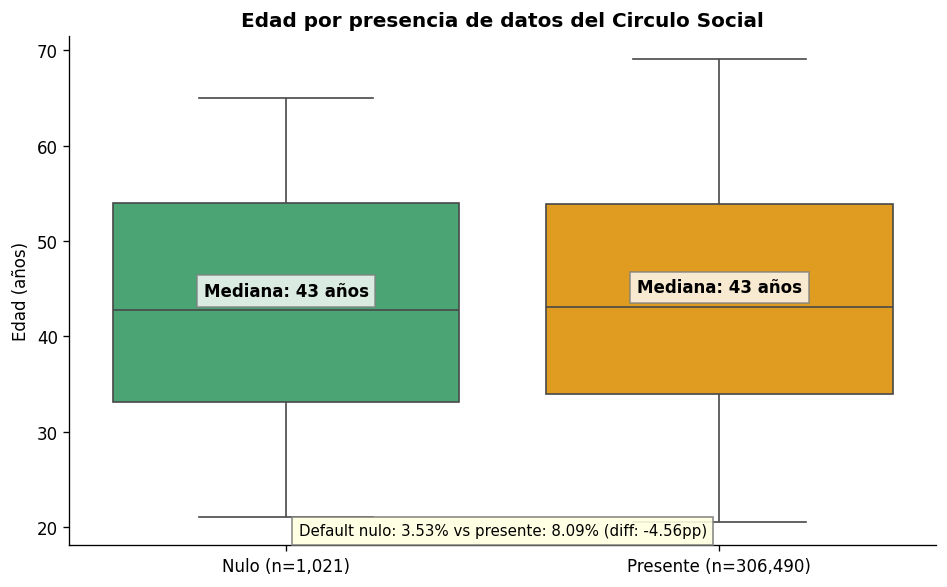

,Método,p-valor,Resultado
Contraste de Hipótesis,,,
Diferencia de edad entre nulos y presentes,Mann-Whitney U,8.6765e-02,No significativo (Igual edad)
Asociación entre ausencia de datos y TARGET,Chi-Cuadrado de Independencia,1.2596e-07,Significativo (Rechaza indep.)


In [17]:
# Visualización Círculo Social: Distribución de edad en nulos vs presentes
fig, ax = plt.subplots(figsize=(8, 5))

social_col = 'OBS_30_CNT_SOCIAL_CIRCLE'
es_nulo = app[social_col].isnull()

# Calculo edad en años y formateo el estado con f-strings
edad = -app['DAYS_BIRTH'] / 365.25
n_nulos = es_nulo.sum()
estado = es_nulo.map({True: f'Nulo (n={n_nulos:,})', False: f'Presente (n={len(app) - n_nulos:,})'})

# Paso x e y directamente a boxplot
sns.boxplot(x=estado, y=edad, hue=estado, ax=ax, palette=[color_nulo, color_presente], order=sorted(estado.unique()), legend=False)
ax.set_title('Edad por presencia de datos del Circulo Social', fontsize=12, fontweight='bold')
ax.set_ylabel('Edad (años)')
ax.set_xlabel('')

# Indico las medianas vía la agrupación ordenada
for i, med in enumerate(edad.groupby(estado).median().sort_index()):
    ax.text(i, med + 1.5, f'Mediana: {med:.0f} años', ha='center', fontsize=10, fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

# Indico los default rates agrupados 
t_pres, t_nulo = app.groupby(es_nulo)['TARGET'].mean()
ax.annotate(
    f'Default nulo: {t_nulo:.2%} vs presente: {t_pres:.2%} (diff: {(t_nulo-t_pres)*100:+.2f}pp)',
    xy=(0.5, 0.02), xycoords='axes fraction', ha='center', fontsize=9,
    bbox=dict(facecolor='lightyellow', alpha=0.9, edgecolor='gray')
)

plt.tight_layout()
plt.show()

# Contrastes estadísticos
mw_stat, p_mw = mannwhitneyu(edad[es_nulo], edad[~es_nulo], alternative='two-sided')
ct = pd.crosstab(es_nulo, app['TARGET'])
chi2, p_chi2, _, _ = chi2_contingency(ct)

df_stats = pd.DataFrame({
    'Contraste de Hipótesis': [
        'Diferencia de edad entre nulos y presentes',
        'Asociación entre ausencia de datos y TARGET'
    ],
    'Método': ['Mann-Whitney U', 'Chi-Cuadrado de Independencia'],
    'p-valor': [p_mw, p_chi2],
    'Resultado': [
        'Significativo (Rechaza indep.)' if p_mw < 0.05 else 'No significativo (Igual edad)',
        'Significativo (Rechaza indep.)' if p_chi2 < 0.05 else 'No significativo'
    ]
}).set_index('Contraste de Hipótesis')
display(df_stats.style.format({'p-valor': '{:.4e}'}))


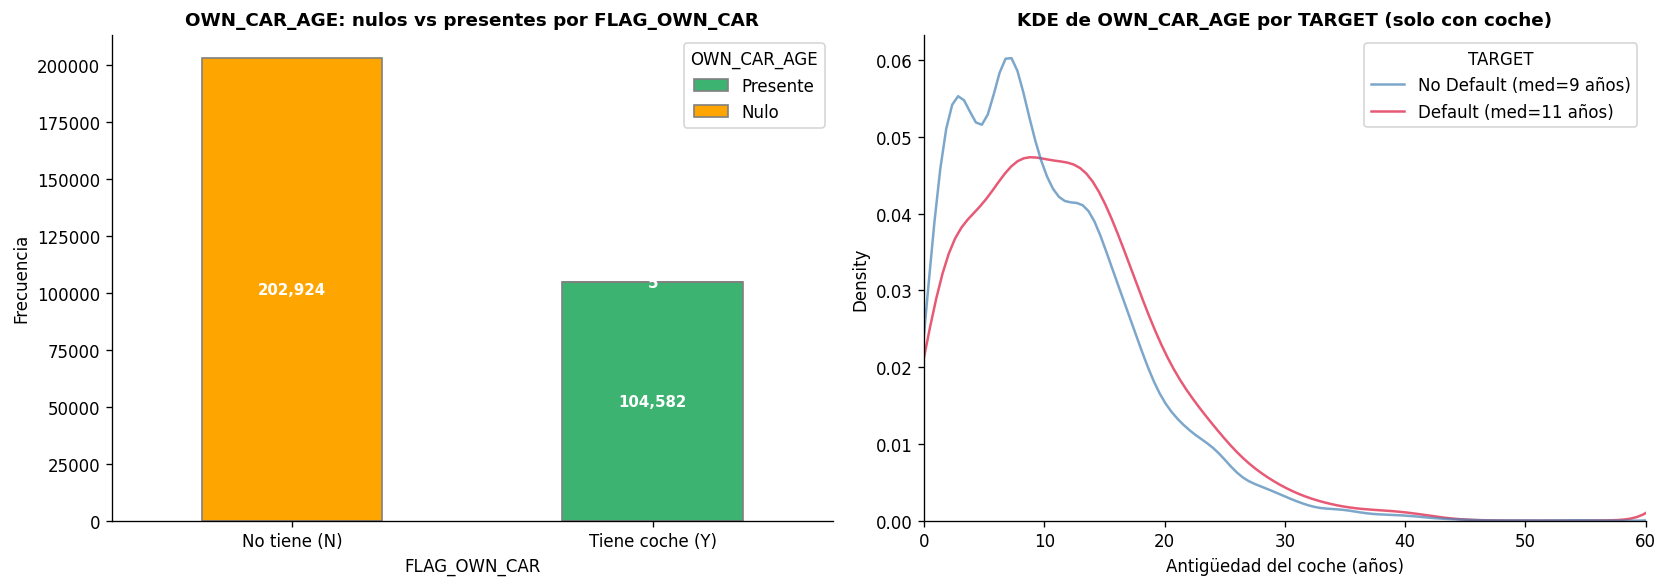

,Método,p-valor,Resultado
Contraste de Hipótesis,,,
Diferencia de antigüedad del coche por TARGET (con coche),Mann-Whitney U,1.0979e-65,Significativo (Rechaza indep.)
Asociación determinista entre FLAG_OWN_CAR y presencia de OWN_CAR_AGE,Chi-Cuadrado de Independencia,0.0000e+00,Significativo (Rechaza indep.)


In [18]:
# Visualización Variables Individuales

# OWN_CAR_AGE: Cruzo con FLAG_OWN_CAR y KDE por TARGET
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Countplot FLAG_OWN_CAR con barras apiladas mostrando nulos/presentes de OWN_CAR_AGE
# Mapeo True/False a etiquetas
cross = pd.crosstab(
    app['FLAG_OWN_CAR'].map({True: 'Tiene coche (Y)', False: 'No tiene (N)'}),
    app['OWN_CAR_AGE'].notnull().map({True: 'Presente', False: 'Nulo'})
)[['Presente', 'Nulo']]

cross.plot.bar(stacked=True, ax=ax1, color=[color_presente, color_nulo], edgecolor='gray')
ax1.set_title('OWN_CAR_AGE: nulos vs presentes por FLAG_OWN_CAR', fontsize=11, fontweight='bold')
ax1.set_xlabel('FLAG_OWN_CAR')
ax1.set_ylabel('Frecuencia')
ax1.tick_params(axis='x', rotation=0)

# Aplico bar_label recorriendo los contenedores de las barras apiladas
for container in ax1.containers:
    ax1.bar_label(
        container,
        labels=[f'{int(v):,}' if v > 0 else '' for v in container.datavalues],
        label_type='center', color='white', fontweight='bold', fontsize=9
    )

# KDE de OWN_CAR_AGE por TARGET (solo con coche)
has_car = app[app['OWN_CAR_AGE'].notnull()]
# Calculo las medianas agrupadas para las leyendas
medians = has_car.groupby('TARGET')['OWN_CAR_AGE'].median()
labels = {
    0: f'No Default (med={medians[0]:.0f} años)',
    1: f'Default (med={medians[1]:.0f} años)'
}

# Uso sns.kdeplot para graficar las dos curvas de densidad de una sola vez
sns.kdeplot(
    data=has_car, x='OWN_CAR_AGE', hue=has_car['TARGET'].map(labels),
    common_norm=False, ax=ax2, palette={labels[0]: color_no_default, labels[1]: color_default},
    alpha=0.7
)
ax2.set_title('KDE de OWN_CAR_AGE por TARGET (solo con coche)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Antigüedad del coche (años)')
ax2.set_xlim(0, 60)
plt.tight_layout()
plt.show()

# Contrastes estadísticos (ponytail: presentación visual en tabla)
mw_stat, p_mw = mannwhitneyu(has_car.loc[has_car['TARGET'] == 0, 'OWN_CAR_AGE'], has_car.loc[has_car['TARGET'] == 1, 'OWN_CAR_AGE'], alternative='two-sided')
ct = pd.crosstab(app['FLAG_OWN_CAR'], app['OWN_CAR_AGE'].notnull())
chi2, p_chi2, _, _ = chi2_contingency(ct)

df_stats = pd.DataFrame({
    'Contraste de Hipótesis': [
        'Diferencia de antigüedad del coche por TARGET (con coche)',
        'Asociación determinista entre FLAG_OWN_CAR y presencia de OWN_CAR_AGE'
    ],
    'Método': ['Mann-Whitney U', 'Chi-Cuadrado de Independencia'],
    'p-valor': [p_mw, p_chi2],
    'Resultado': [
        'Significativo (Rechaza indep.)' if p_mw < 0.05 else 'No significativo',
        'Significativo (Rechaza indep.)' if p_chi2 < 0.05 else 'No significativo'
    ]
}).set_index('Contraste de Hipótesis')
display(df_stats.style.format({'p-valor': '{:.4e}'}))


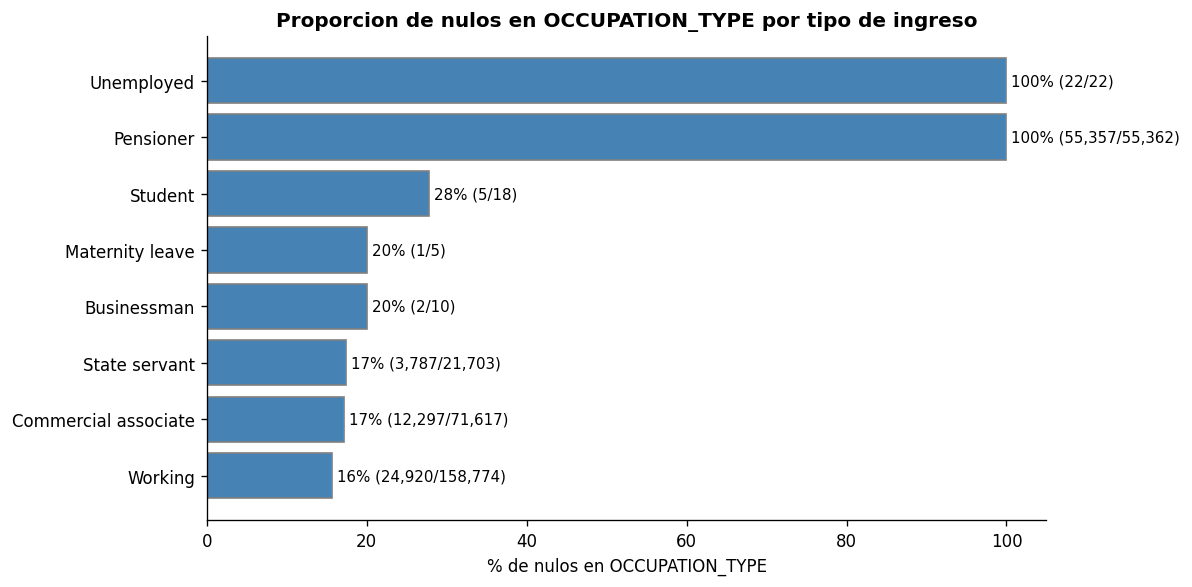

,Método,p-valor,Resultado
Contraste de Hipótesis,,,
"Asociación estructural entre nulos de Ocupación e Income Type (Pensionistas, etc.)",Chi-Cuadrado de Independencia,0.0000e+00,Significativo (Rechaza indep.)


In [19]:
# OCCUPATION_TYPE: % nulos por NAME_INCOME_TYPE
fig, ax = plt.subplots(figsize=(10, 5))

# Calculo el total, nulos y porcentaje sobre la serie boolean de nulos
cross_income = app['OCCUPATION_TYPE'].isnull().groupby(app['NAME_INCOME_TYPE'], observed=True).agg(
    total='count',
    nulos='sum',
    pct_nulos=lambda x: x.mean() * 100
).sort_values('pct_nulos')

# Uso barh para capturar los contenedores directamente
bars = ax.barh(cross_income.index, cross_income['pct_nulos'], color=color_no_default, edgecolor='gray')

# Uso Native bar_label con una lista de etiquetas dinámicas en un paso sencillo
labels = [f'{r.pct_nulos:.0f}% ({int(r.nulos):,}/{int(r.total):,})' for r in cross_income.itertuples()]
ax.bar_label(bars, labels=labels, padding=3, fontsize=9)

ax.set_xlabel('% de nulos en OCCUPATION_TYPE')
ax.set_title('Proporcion de nulos en OCCUPATION_TYPE por tipo de ingreso', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Contrastes estadísticos (ponytail: presentación visual en tabla)
ct = pd.crosstab(app['OCCUPATION_TYPE'].isnull(), app['NAME_INCOME_TYPE'])
chi2, p_chi2, _, _ = chi2_contingency(ct)

df_stats = pd.DataFrame({
    'Contraste de Hipótesis': [
        'Asociación estructural entre nulos de Ocupación e Income Type (Pensionistas, etc.)'
    ],
    'Método': ['Chi-Cuadrado de Independencia'],
    'p-valor': [p_chi2],
    'Resultado': [
        'Significativo (Rechaza indep.)' if p_chi2 < 0.05 else 'No significativo'
    ]
}).set_index('Contraste de Hipótesis')
display(df_stats.style.format({'p-valor': '{:.4e}'}))


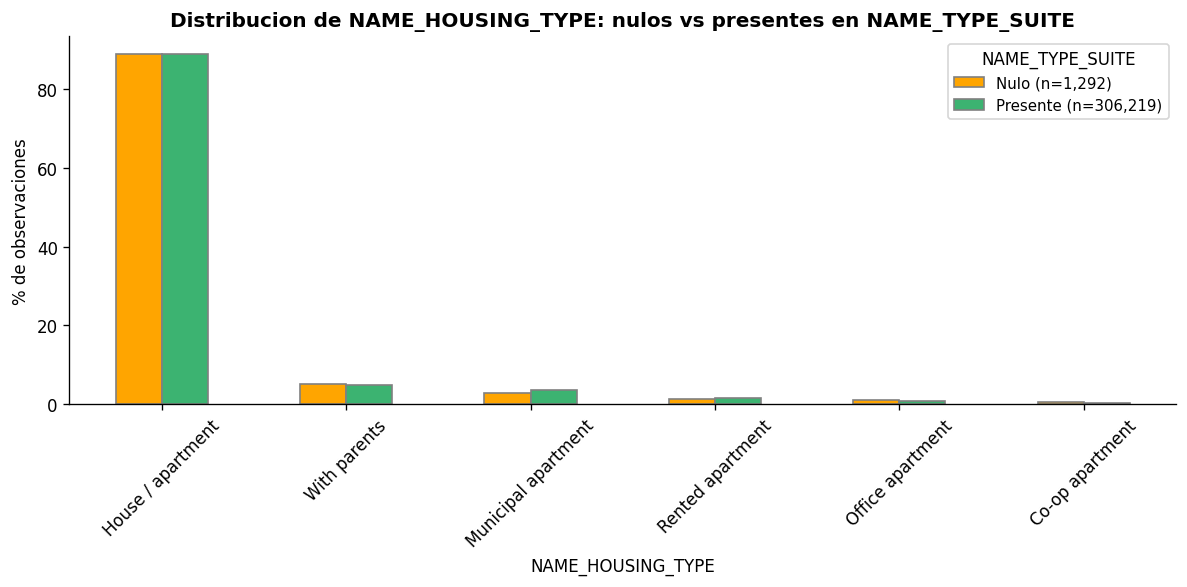

,Método,p-valor,Resultado
Contraste de Hipótesis,,,
Asociación entre nulos de NAME_TYPE_SUITE y tipo de vivienda (NAME_HOUSING_TYPE),Chi-Cuadrado de Independencia,1.6498e-01,No significativo (Estadísticamente independientes)


In [20]:
# NAME_TYPE_SUITE: Distribucion de NAME_HOUSING_TYPE en nulos vs no nulos
fig, ax = plt.subplots(figsize=(10, 5))

# Calculo crosstab con booleanos y renombro columnas
is_null = app['NAME_TYPE_SUITE'].isna()
n_null = is_null.sum()
n_not_null = len(is_null) - n_null

nulo_col = f'Nulo (n={n_null:,})'
presente_col = f'Presente (n={n_not_null:,})'

housing_dist = (pd.crosstab(app['NAME_HOUSING_TYPE'], is_null, normalize='columns') * 100).rename(
    columns={True: nulo_col, False: presente_col}
)
housing_dist = housing_dist[[nulo_col, presente_col]].sort_values(by=nulo_col, ascending=False)

housing_dist.plot.bar(ax=ax, color=[color_nulo, color_presente], edgecolor='gray')
ax.set_ylabel('% de observaciones')
ax.set_title('Distribucion de NAME_HOUSING_TYPE: nulos vs presentes en NAME_TYPE_SUITE',
             fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='NAME_TYPE_SUITE', fontsize=9)
plt.tight_layout()
plt.show()

# Contrastes estadísticos
ct = pd.crosstab(app['NAME_TYPE_SUITE'].isna(), app['NAME_HOUSING_TYPE'])
chi2, p_chi2, _, _ = chi2_contingency(ct)

df_stats = pd.DataFrame({
    'Contraste de Hipótesis': [
        'Asociación entre nulos de NAME_TYPE_SUITE y tipo de vivienda (NAME_HOUSING_TYPE)'
    ],
    'Método': ['Chi-Cuadrado de Independencia'],
    'p-valor': [p_chi2],
    'Resultado': [
        'Significativo (Rechaza indep.)' if p_chi2 < 0.05 else 'No significativo (Estadísticamente independientes)'
    ]
}).set_index('Contraste de Hipótesis')
display(df_stats.style.format({'p-valor': '{:.4e}'}))


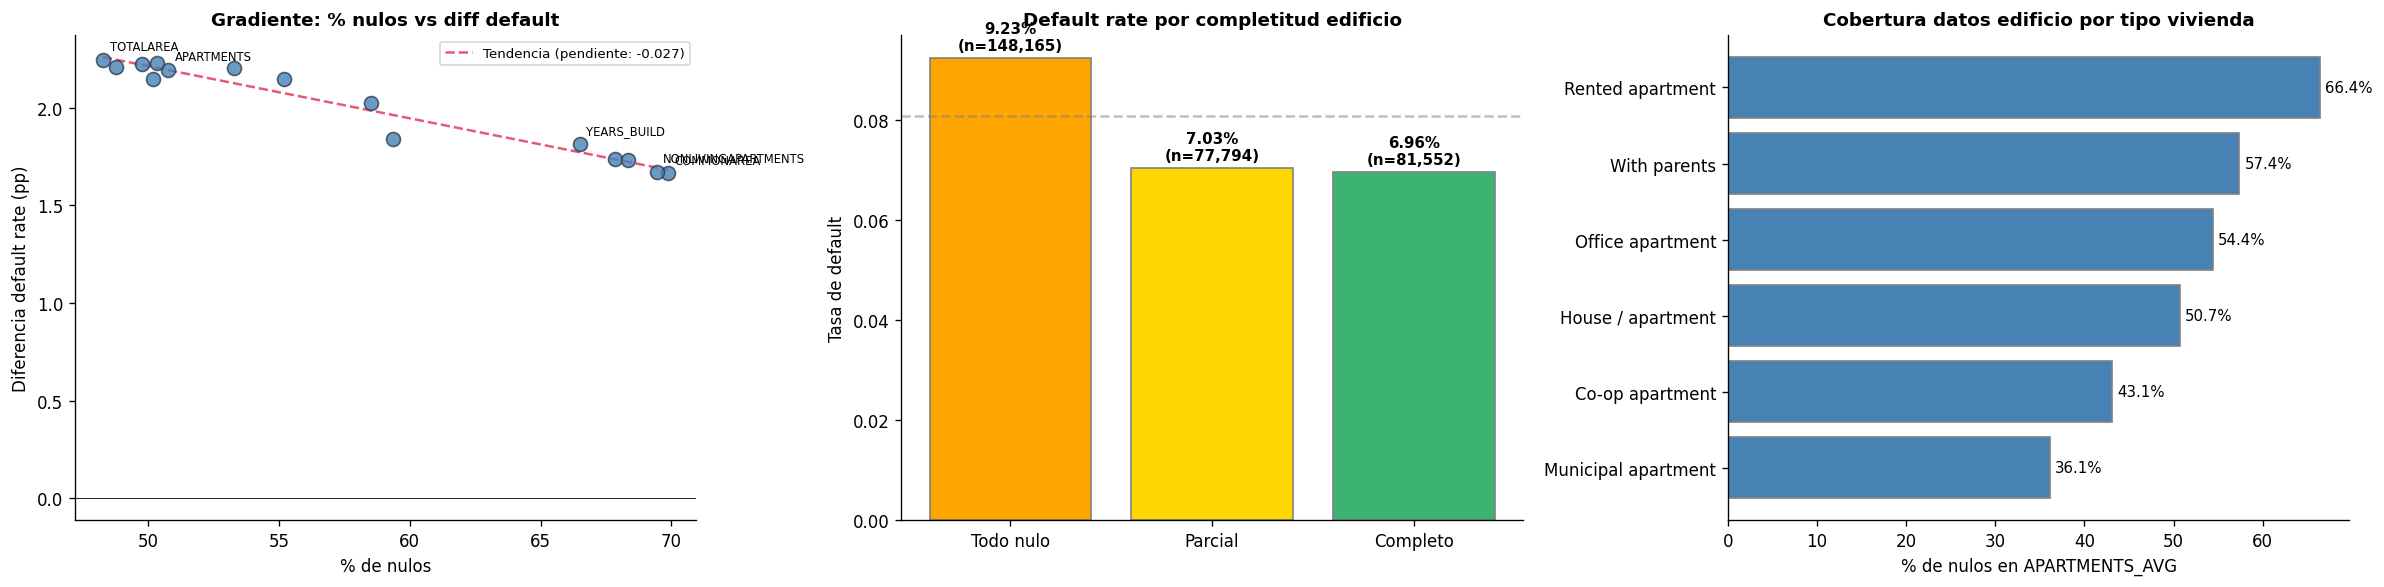

,Test / Coeficiente,p-valor,Resultado
Panel Analizado,,,
Panel 1: Relación lineal entre % nulos y diferencia de default (Gradiente),Correlación de Pearson (r = -0.9756),6.0919e-10,Significativo (Asociación lineal muy fuerte)
Panel 2: Asociación entre nivel de completitud de datos de edificio y TARGET,Chi-Cuadrado de Independencia,1.5951e-113,Significativo (Rechaza indep.)
Panel 3: Dependencia entre cobertura de APARTMENTS_AVG y tipo de vivienda (NAME_HOUSING_TYPE),Chi-Cuadrado de Independencia,0.0000e+00,Significativo (Rechaza indep.)


In [21]:
# Visualización Edificio: Gradiente nulos-default, completitud, cobertura por tipo vivienda
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))

# Columnas representativas del edificio (solo _AVG + TOTALAREA_MODE)
building_bases = ['APARTMENTS', 'BASEMENTAREA', 'YEARS_BEGINEXPLUATATION', 'YEARS_BUILD',
                  'COMMONAREA', 'ELEVATORS', 'ENTRANCES', 'FLOORSMAX', 'FLOORSMIN',
                  'LANDAREA', 'LIVINGAPARTMENTS', 'LIVINGAREA', 'NONLIVINGAPARTMENTS',
                  'NONLIVINGAREA']
building_avg = [f'{b}_AVG' for b in building_bases if f'{b}_AVG' in app.columns]
building_avg.append('TOTALAREA_MODE')

# Scatter % nulos vs diferencia default rate
# Calculo estadísticas vectorialmente
is_null = app[building_avg].isnull()
total_nulls = is_null.sum()
total_not_nulls = len(app) - total_nulls

pts_x = (total_nulls / len(app)) * 100
t_target = app['TARGET'].astype(float)
t_n = is_null.mul(t_target, axis=0).sum() / total_nulls
t_p = (~is_null).mul(t_target, axis=0).sum() / total_not_nulls
pts_y = (t_n - t_p) * 100
pts_label = [col.replace('_AVG', '').replace('_MODE', '') for col in building_avg]

ax1.scatter(pts_x, pts_y, c=color_no_default, s=70, edgecolors='#2c3e50', zorder=3, alpha=0.8)
z = np.polyfit(pts_x, pts_y, 1)
x_line = np.linspace(pts_x.min(), pts_x.max(), 50)
ax1.plot(x_line, np.poly1d(z)(x_line), '--', color=color_default, alpha=0.7, label=f'Tendencia (pendiente: {z[0]:.3f})')
destacar = {'TOTALAREA', 'APARTMENTS', 'COMMONAREA', 'YEARS_BUILD', 'NONLIVINGAPARTMENTS'}
for x, y, label in zip(pts_x, pts_y, pts_label):
    if label in destacar:
        ax1.annotate(label, (x, y), fontsize=7, ha='left', va='bottom',
                     xytext=(4, 4), textcoords='offset points')
ax1.set_xlabel('% de nulos')
ax1.set_ylabel('Diferencia default rate (pp)')
ax1.set_title('Gradiente: % nulos vs diff default', fontsize=11, fontweight='bold')
ax1.axhline(0, color='black', linewidth=0.5)
ax1.legend(fontsize=8)

# Default rate por grupo de completitud
# Calculo completitud y agrupo
n_present = app[building_avg].notnull().sum(axis=1)
completitud = pd.cut(n_present, bins=[-1, 0, len(building_avg) - 1, len(building_avg)], labels=['Todo nulo', 'Parcial', 'Completo'])
comp_agg = app['TARGET'].groupby(completitud, observed=False).agg(['mean', 'count'])

bars = ax2.bar(comp_agg.index, comp_agg['mean'], color=[color_nulo, color_parcial, color_presente], edgecolor='gray')
labels_bar2 = [f'{mean:.2%}\n(n={count:,})' for mean, count in zip(comp_agg['mean'], comp_agg['count'])]
ax2.bar_label(bars, labels=labels_bar2, padding=3, fontsize=9, fontweight='bold')
ax2.set_title('Default rate por completitud edificio', fontsize=11, fontweight='bold')
ax2.set_ylabel('Tasa de default')
ax2.axhline(app['TARGET'].mean(), color='gray', linestyle='--', alpha=0.5)

# % nulos en APARTMENTS_AVG por NAME_HOUSING_TYPE
# Calculo nulos por tipo de vivienda vectorialmente
housing_null = (app['APARTMENTS_AVG'].isnull().groupby(app['NAME_HOUSING_TYPE'], observed=False).mean() * 100).sort_values()
bars = ax3.barh(housing_null.index, housing_null, color=color_no_default, edgecolor='gray')
ax3.bar_label(bars, labels=[f'{val:.1f}%' for val in housing_null], padding=3, fontsize=9)
ax3.set_xlabel('% de nulos en APARTMENTS_AVG')
ax3.set_title('Cobertura datos edificio por tipo vivienda', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Contrastes estadísticos
# Correlación del gradiente (Panel 1)
corr, p_corr = pearsonr(pts_x, pts_y)

# Chi-Cuadrado de la completitud vs TARGET (Panel 2)
ct_comp = pd.crosstab(completitud, app['TARGET'])
_, p_comp, _, _ = chi2_contingency(ct_comp)

# Chi-Cuadrado de la cobertura de APARTMENTS_AVG vs tipo vivienda (Panel 3)
ct_house = pd.crosstab(app['APARTMENTS_AVG'].isnull(), app['NAME_HOUSING_TYPE'])
_, p_house, _, _ = chi2_contingency(ct_house)

df_stats = pd.DataFrame({
    'Panel Analizado': [
        'Panel 1: Relación lineal entre % nulos y diferencia de default (Gradiente)',
        'Panel 2: Asociación entre nivel de completitud de datos de edificio y TARGET',
        'Panel 3: Dependencia entre cobertura de APARTMENTS_AVG y tipo de vivienda (NAME_HOUSING_TYPE)'
    ],
    'Test / Coeficiente': [f'Correlación de Pearson (r = {corr:.4f})', 'Chi-Cuadrado de Independencia', 'Chi-Cuadrado de Independencia'],
    'p-valor': [p_corr, p_comp, p_house],
    'Resultado': [
        'Significativo (Asociación lineal muy fuerte)' if p_corr < 0.05 else 'No significativo',
        'Significativo (Rechaza indep.)' if p_comp < 0.05 else 'No significativo',
        'Significativo (Rechaza indep.)' if p_house < 0.05 else 'No significativo'
    ]
}).set_index('Panel Analizado')
display(df_stats.style.format({'p-valor': '{:.4e}'}))


Análisis del comportamiento de los missings:

### Bloque: Score Externo
- `EXT_SOURCE_3` (19.8% nulos): La diferencia en tasas de default 1.55pp y diferencia en la mediana de 0.167 (0.546 vs 0.379), es la mayor de los 3 scores. La ausencia del score depende del propio perfil crediticio del solicitante: cuando la entidad no puede calcular el score es porque falta historial de transacciones, lo que afecta directamente al valor que tendría. Lo clasificaré como **MNAR**.
- `EXT_SOURCE_1` (56.4% nulos): La diferencia en tasas de 1.02pp y diferencia en la mediana de 0.156. Misma lógica que `EXT_SOURCE_3`, la ausencia del score implica falta de información crediticia disponible. Que más de la mitad de la población carezca de este score sugiere que proviene de un bureau específico en el que no todos los clientes están registrados, lo que refuerza que la ausencia en sí misma es informativa. Lo clasificaré como **MNAR**.
- `EXT_SOURCE_2` (0.21% nulos): La diferencia entre tasas de -0.19pp y diferencia en mediana mínima (0.574 vs 0.440). La presencia de valores es del 99.79%, prácticamente completa la variable, y la diferencia es despreciable. Lo clasificaré como **MCAR**, probablemente hayan sido fallos puntuales de recogida.

**Soporte estadístico**: Esta hipótesis de no-aleatoriedad estructural está respaldada por el test Mann-Whitney U, que confirma diferencias altamente significativas en las distribuciones de scores según la clase de TARGET ($p < 0.001$ en las tres variables), así como por el contraste de Chi-Cuadrado de independencia, que valida que la omisión de estos scores no ocurre al azar, sino que está vinculada al default del solicitante. En contraste, para `EXT_SOURCE_2`, la baja tasa de nulos y el descarte de diferencias significativas en su ausencia apoyan el diagnóstico de MCAR residual por fallos puntuales de captura.

La visualización fueron tres subplots en una fila con histograma KDE de cada score separado por TARGET (default vs no default), añadiendo el porcentaje de nulos como anotación en cada uno. El KDE muestra a la vez la separación entre clases cuando hay valor y la anotación contextualiza el volumen de nulos.

---

### Bloque: Buró de Crédito
- `AMT_REQ_CREDIT_BUREAU_X` (las 6 variables): Los 41.519 nulos (13.5%) son exactamente los mismos en las 6 variables, lo que confirma que tener consultas o no tenerlas es estructural por obs.

La diferencia en tasa de default es de 2.62pp (10.34% vs 7.72%). En la variable `_YEAR` la mediana sube de 1 a 2 en defaults, lo que encaja con un perfil de individuo que mantiene una búsqueda activa de crédito lo que entonces se asociaría con un perfil de mayor riesgo. La ausencia se explica probablemente porque el cliente no tenga historial registrado en el bureau, lo que nos lleva a clasificarlo como **MNAR** dado que la ausencia depende de una dimensión no observada directamente.

**Soporte estadísticon**: Queda respaldado el argumento por el test Mann-Whitney U ($p = 1.05 \times 10^{-23}$), que demuestra que la mayor frecuencia de consultas en morosos no es fruto del azar, sino un patrón de comportamiento de riesgo. Asimismo, la prueba Chi-Cuadrado de independencia corrobora con alta significancia ($p = 4.92 \times 10^{-74}$) que la tasa de default entre clientes sin expediente (nulos) y aquellos registrados difiere de manera sistemática, corroborando que no disponer de historial en el buró es una señal informativa por sí misma.

La visualización fue un boxplot de `AMT_REQ_CREDIT_BUREAU_YEAR` separado por TARGET mostrando solo los casos con valor presente, complementado con una barra que indique el % de nulos y su tasa de default asociada. El boxplot evidencia de forma clara el salto en la mediana de 1 a 2 entre buenos y malos pagadores.

---

### Bloque: Círculo Social
- `OBS_X_CNT_SOCIAL_CIRCLE` y `DEF_X_CNT_SOCIAL_CIRCLE`: Los 1.021 nulos (0.33%) son idénticos en las 4 variables, lo que confirma que la ausencia es estructural en el lote de captura.

La diferencia en tasa de default es de -4.56pp (3.53% en nulos vs 8.09% en presentes), algo que choca a primera vista. Mi hipótesis inicial era que los nulos correspondían a perfiles aislados con mayor edad y por tanto más estables financieramente. Sin embargo, al verificarlo con el boxplot de edad, la mediana es 43 años tanto en nulos como en presentes, lo que refuta la hipótesis: no hay un perfil de cliente distinto detrás de los nulos.

Quedan dos lecturas posibles: (1) la diferencia de -4.56pp es casualidad estadística sobre 1.021 registros, lo que llevaría a clasificar como **MCAR** por error de captura en un lote concreto, o (2) hay un factor no observado en el dataset que explica simultáneamente la ausencia del dato del círculo social y un menor riesgo (por ejemplo, un canal de solicitud específico). Sin más evidencia, lo clasificaré como **MCAR provisional**, dado que la hipótesis MNAR no se ha podido sostener con las variables disponibles.

**Soporte estadístico**: Al apoyarme en el contraste estaístico descarte la hipótesis del perfil aislado, el test Mann-Whitney U sobre la edad de ambos grupos arroja un p-valor de $0.0867$. Al no ser estadísticamente significativo ($p > 0.05$), confirmamos que NO hay diferencia de edad entre nulos y presentes. Sin embargo, el contraste Chi-Cuadrado de la tasa de default sí resulta altamente significativo ($p = 1.26 \times 10^{-7}$), sugiriendo que la menor tasa de default en los nulos no es ruido sobre la muestra, sino que responde a un factor sistemático, apoyando así mi decisión de calificarlo como MCAR provisional.

La visualización fue un boxplot de la edad (`DAYS_BIRTH` convertido a años) separando los registros con valor presente vs nulos en estas variables. La mediana idéntica de 43 años en ambos grupos refuta la hipótesis del perfil aislado.

---

### Bloque: Variables Individuales
- `OWN_CAR_AGE` (66% nulos): Al cruzarla con `FLAG_OWN_CAR` los 202.929 nulos coinciden exactamente con `FLAG_OWN_CAR` = 'N' (salvo 5 obs que se eliminarán por ruido). La ausencia entonces queda explicada al 100% por otra variable existente en el dataset. Lo clasificaré entonces como **MAR determinista**.

La diferencia en tasa de default es de 1.26pp: quienes no tienen coche muestran un default ligeramente mayor, lo que correspondería con una situación financiera algo más ajustada (que no les permite 'caprichos'). Adicionalmente, la mediana de la edad del coche es 9 años en los que no hacen default vs 11 años los que sí hacen default, es decir, los morosos tienen coches más viejos (un +22% relativo sobre la mediana, no despreciable). Lo que nos hace ver que hay presente una señal débil pero coherente en base a una posible situación real.

**Soporte estadístico**: El test Mann-Whitney U sobre la antigüedad del vehículo corrobora que los morosos tienen coches significativamente más viejos ($p = 1.10 \times 10^{-65}$), validando que la antigüedad del coche es un discriminador de riesgo crediticio real. Por otro lado, el test Chi-Cuadrado sobre el cruce de `FLAG_OWN_CAR` y la presencia de `OWN_CAR_AGE` ($p = 0.0$) corrobora la naturaleza MAR determinista de los nulos.

La visualización debe ser dos paneles. (1) countplot de `FLAG_OWN_CAR` con barras apiladas mostrando cuántos `OWN_CAR_AGE` son nulos en cada grupo, evidenciando el cruce determinista. (2) KDE de `OWN_CAR_AGE` separado por TARGET solo para quienes tienen coche, evidenciando la diferencia de medianas.

- `OCCUPATION_TYPE` (31.3% nulos): La diferencia en tasas de -2.27pp (6.51% nulos vs 8.79% presentes). El mecanismo no es uniforme entre categorías de `NAME_INCOME_TYPE`: Pensioner y Unemployed tienen 100% de nulos (la ausencia es determinista al no haber ocupación que reportar), Student tiene 28% (ausencia parcial porque algunos estudiantes sí compaginan con trabajo), y el resto (Working, State servant, Commercial associate, etc.) tienen 16-20% de nulos, lo que ya es más cercano a error de captura. Es decir, una parte de la ausencia es MAR determinista vía `NAME_INCOME_TYPE`, y otra parte es ruido residual. Lo clasificaré como **MAR** porque la dimensión predictiva dominante (Pensioner + Unemployed) sí queda explicada por una variable observada.

**Soporte estadístico**: La prueba Chi-Cuadrado de independencia corrobora ($p = 0.0$) que la ausencia de ocupación está ligada al tipo de ingresos (como pensionistas y desempleados), lo que confirma la hipótesis del comportamiento MAR.

La visualización fue un gráfico barras horizontales mostrando el % de nulos en `OCCUPATION_TYPE` por cada categoría de `NAME_INCOME_TYPE`. Evidencia directamente que Pensioner y Unemployed son el 100% de nulos en esos grupos, y que el resto de categorías tienen un nivel de ruido mucho menor.

- `NAME_TYPE_SUITE` (0.42% nulos): La diferencia en tasas de -2.67pp (5.42% nulos vs 8.08% presentes). Las 1.292 obs con valor NA tienen una tasa de default sensiblemente más baja que cualquier categoría existente, incluido Children (7.38%). Mi hipótesis inicial era que no indicar con quién se realiza la solicitud se asociaba con un perfil de mayor autonomía financiera. Al verificarlo con la distribución de `NAME_HOUSING_TYPE` entre nulos y presentes, las distribuciones son prácticamente idénticas (House/apartment ronda el 88-89% en ambos grupos), por lo que `NAME_HOUSING_TYPE` no explica el missing y la hipótesis del perfil específico no se sostiene. Reclasifico como **MCAR**: lo más probable es que sean errores de captura en el formulario sobre 1.292 obs, y que la diferencia de -2.67pp sea ruido estadístico sobre una muestra pequeña.

**Soporte estadístico**: En base a la prueba Chi-Cuadrado de independencia ($p = 0.1650$) al no ser significativo ($p > 0.05$), confirmamos estadísticamente la ausencia de relación entre el tipo de vivienda y los nulos en `NAME_TYPE_SUITE`, descartando así la hipótesis de un perfil de autonomía específico y sosteniendo el comportamiento MCAR.

La visualización fue un gráfico de barras agrupadas comparando la distribución porcentual de `NAME_HOUSING_TYPE` entre los nulos y los no nulos de `NAME_TYPE_SUITE`. Las distribuciones idénticas confirman que no hay un perfil residencial diferenciado en los nulos.

- Variables como `CNT_FAM_MEMBERS`, `DAYS_LAST_PHONE_CHANGE`, `AMT_ANNUITY`, con un % tan pequeño de nulos (0.07; 0.03; 0.39)% y una diferencia tan drástica en el comportamiento respecto a la variable objetivo, muestra que son puro ruido estadístico por lo que lo mejor en vez de imputarlos (que también se podría hacer ya que son muy pocos y no afectaría), se eliminarán para mantener una coherencia. Por otro lado, las categorizaría como un comportamiento **MCAR**, ya que posiblemente sean errores de captura/recolección de datos. No obstante, en el caso de la variable `AMT_GOODS_PRICE`, tiene una presencia algo mayor y su % de nulos es mayor, pero la diferencia de las tasas de default es ínfima por lo que tampoco sería estadísticamente significativo lo que me hace categorizarla como **MCAR** igualmente y en este caso sí la imputaré vía la mediana. Nota: en el pipeline, la imputación podría ser más precisa condicionando a `AMT_CREDIT`, ya que `goods_price <= credit` es una relación estructural del producto crediticio.

---

### Bloque: Edificio
Este bloque incluye 14 conceptos numéricos × 3 versiones (AVG, MODE, MEDI) = 42 columnas numéricas, más 4 categóricas (`EMERGENCYSTATE_MODE`, `HOUSETYPE_MODE`, `WALLSMATERIAL_MODE`, `FONDKAPREMONT_MODE`), 46 columnas en total. Lo trato como un único grupo porque el patrón de nulos es estructural a nivel de bloque, no variable a variable.

Adicionalmente, las tres versiones AVG/MODE/MEDI de cada concepto tienen exactamente los mismos % de nulos y exactamente las mismas diferencias de default rate, por lo que estadísticamente son intercambiables. Esto cierra la decisión previa del análisis numérico de quedarme solo con la versión AVG y descartar MODE y MEDI sin pérdida de información.

Observo un efecto de descenso que es gradiente en el sentido de que a mayor porcentaje de nulos en una variable, menor es la diferencia de tasas de default entre nulo y presente:
- `TOTALAREA` (48.3% nulos) -> +2.24pp
- `APARTMENTS` (50.7% nulos) -> +2.19pp
- `LANDAREA` (59.4% nulos) -> +1.84pp
- `YEARS_BUILD` (66.5% nulos) -> +1.81pp
- `COMMONAREA` (69.9% nulos) -> +1.66pp

Si los nulos fueran **MCAR** la diferencia debería ser aproximadamente 0 independientemente del volumen. Que exista un gradiente descartaría entonces el posible comportamiento aleatorio. Además, el gradiente es consistente con un efecto de dilución: a mayor % de nulos, el grupo nulo se vuelve más heterogéneo (mezcla perfiles de "vivienda informal" con "dato simplemente no recogido"), diluyendo la señal discriminante. Esto es justamente lo que esperaríamos de un **MNAR** con mecanismos heterogéneos.

**Soporte estadístico**: El argumento del gradiente queda corroborado por la correlación de Pearson, que arroja un coeficiente de **r = -0.9756** con un p-valor extremadamente pequeño ($6.09 \times 10^{-10}$). Esta relación lineal negativa casi perfecta demuestra matemáticamente que el volumen de nulos y la dilución de la señal de default no son  casualidad sino que apoya la tesis de un comportamiento MNAR estructural que plantee previamente.

Las variables con más nulos (`COMMONAREA`, `NONLIVINGAPARTMENTS`) capturan características de edificios más específicos y su ausencia es heterogénea: ya que falta tanto en viviendas informales como en edificios antiguos sin registro. Las variables que menos faltan (`TOTALAREA`, `APARTMENTS`) por tanto, discriminan mejor porque su presencia implica que un inmueble está bien documentado, por lo que da señal acerca de la estabilidad socioeconómica.

El patrón de nulos no es o blanco o negro ya que de las 307.511 filas:
- 81.552 (26.5%) tienen los 14 conceptos completos
- 148.165 (48.2%) tienen los 14 conceptos nulos
- 77.794 (25.3%) tienen nulos parciales (entre 1 y 13)

Si la ausencia fuera simplemente "no tiene vivienda formal" esperaríamos solo dos grupos. Que existan 77.794 registros con información parcial nos indica que hay fuentes de datos distintas con señales distintas, probablemente haya un registro catastral vs base del ayuntamiento. Esto reforzaría clasificar la variable como **MNAR** ya que la ausencia depende de qué fuente cubre al solicitante.

Por otro lado el default rate por completitud:
- Completo (14/14 presentes): 6.96%
- Todo nulo (14/14 nulos): 5.43% 
- Parcial (1-13 nulos): 7.05%

El grupo con todos los campos nulos tiene el menor default rate, contradiciendo la hipótesis inicial. Estos 148K registros probablemente concentran perfiles conservadores que no viven en bloques de apartamentos (casas unifamiliares, pensionistas con propiedad). El cruce con `NAME_HOUSING_TYPE` lo respalda:
- Rented apartment: 66.4% nulos
- With parents: 57.4% nulos
- House / apartment: 50.7% nulos
- Municipal apartment: 36.1% nulos

**Soporte estadístico**: Para sostener esta paradoja de que el grupo de completitud "Todo nulo" tenga menor riesgo que los parciales o completos, la prueba Chi-Cuadrado sobre el impacto de la completitud en el TARGET resulta extremadamente significativa ($p = 1.60 \times 10^{-113}$), confirmando que las diferencias en la tasa de default son reales. Asimismo, el test Chi-Cuadrado de la cobertura de APARTMENTS_AVG según el tipo de vivienda ($p = 0.0$) corrobora que la omisión de estos datos está atada a la tipología física residencial (MNAR), respaldando la explicación de que el grupo "Todo nulo" asocia perfiles de menor riesgo que residen en viviendas unifamiliares.

Las viviendas en alquiler (mayor riesgo) tienen más nulos, pero las municipales (menor riesgo) tienen menos. El efecto neto se diluye porque House/apartment representa el 88% de los registros con cobertura aproximada 50/50. Esto explica por qué a nivel variable individual la diferencia es positiva (+2pp) mientras el grupo todo nulo tiene menor riesgo: son dos preguntas distintas medidas sobre poblaciones distintas.

Por otro lado, hay una moda diferente en `WALLSMATERIAL_MODE`. Esta variable presenta una asimetría que el resto del bloque no tiene y es que la moda es Panel para TARGET=0 y Stone/brick para TARGET=1. Por lo que, principalmente los morosos viven más en construcciones antiguas de piedra y ladrillo, mientras que los no morosos viven más en paneles (construcciones modernas). Esta señal predictiva es directa sobre la calidad del activo subyecente que el cliente solicita. El resto de variables categóricas (`EMERGENCYSTATE_MODE`, `HOUSETYPE_MODE`, `FONDKAPREMONT_MODE`) mantienen la misma moda en ambas clases.

Por último, clasificaré todas estas variables como **MNAR** ya que la ausencia depende del tipo de vivienda y del propio valor de la variable. La señal predictiva está tanto en qué variables faltan como en si falta algo, no solo en una de las dos dimensiones. Por lo que, crearé una variable estilo flag binario (ej: `HAS_BUILDING_INFO`) para tratar de capturar la señal del missing de forma unificada. Adicionalmente, crearé una segunda variable estilo flag o variable de conteo que capture la dimensión de completitud parcial vs total, ya que el patrón visto sugiere que el grado de información disponible también aporta señal. La decisión de conservar o eliminar las 46 columnas originales se basará según el IV. De forma que si los flags capturan toda la señal, eliminaré estas variables analizadas; pero si las variables continuas o categóricas aportan señal adicional (ej: `WALLSMATERIAL_MODE`), conservaré las que superen el umbral propuesto.

La visualización consitió en tres paneles. (1) scatter con % de nulos en eje X vs diferencia de default rate en eje Y, una variable por punto, evidenciando el gradiente inverso. (2) barras con default rate por grupo de completitud (completo / todo nulo / parcial), evidenciando la paradoja del grupo todo-nulo. (3) barras horizontales del % de nulos en `APARTMENTS_AVG` por `NAME_HOUSING_TYPE`, evidenciando la heterogeneidad de cobertura entre tipos de vivienda.

### Solapamiento inter-bloque
Los bloques anteriores se han analizado de forma independiente, pero es relevante verificar si los nulos de diferentes bloques comparten las mismas observaciones. Si los 41.519 nulos del buró, los 1.021 del círculo social y los 148.165 del edificio se concentran sobre los mismos individuos, existiría una dimensión latente (canal de solicitud, fuente de datos, antigüedad del registro) que explica la co-ocurrencia. Determinaré si en lugar de tratar cada bloque por separado, se pudiese crear un único flag de "fuente de datos incompleta" que capture la señal conjunta.


In [22]:
# Comprobación empírica y contraste de independencia (Chi-Cuadrado y V de Cramer)
building_bases = ['APARTMENTS', 'BASEMENTAREA', 'YEARS_BEGINEXPLUATATION', 'YEARS_BUILD',
                  'COMMONAREA', 'ELEVATORS', 'ENTRANCES', 'FLOORSMAX', 'FLOORSMIN',
                  'LANDAREA', 'LIVINGAPARTMENTS', 'LIVINGAREA', 'NONLIVINGAPARTMENTS',
                  'NONLIVINGAREA']
building_avg = [f'{b}_AVG' for b in building_bases if f'{b}_AVG' in app.columns] + ['TOTALAREA_MODE']

# Calculo las máscaras booleanas para cada bloque de nulos
bureau_null = app['AMT_REQ_CREDIT_BUREAU_YEAR'].isnull()
social_null = app['OBS_30_CNT_SOCIAL_CIRCLE'].isnull()
building_null = app[building_avg].isnull().all(axis=1)

# Calculo las intersecciones de nulos y creo tabla resumen
overlap = pd.DataFrame({
    'Nulos': [
        bureau_null.sum(),
        social_null.sum(),
        building_null.sum(),
        (bureau_null & building_null).sum(),
        (bureau_null & social_null).sum(),
        (social_null & building_null).sum(),
        (bureau_null & social_null & building_null).sum()
    ]
}, index=['Buró', 'Círculo Social', 'Edificio (Completo)', 'Buró & Edificio', 'Buró & Social', 'Social & Edificio', 'Los Tres'])
overlap['% del dataset'] = (overlap['Nulos'] / len(app)) * 100
display(overlap.style.format({'Nulos': '{:,}', '% del dataset': '{:.2f}%'}))

# Realizo contrastes de Chi-Cuadrado de independencia y calculo V de Cramer
n = len(app)
contrastes = []
for name1, s1, name2, s2 in [
    ('Buró', bureau_null, 'Edificio', building_null),
    ('Buró', bureau_null, 'Social', social_null),
    ('Social', social_null, 'Edificio', building_null)
]:
    ct = pd.crosstab(s1, s2)
    chi2, p_val, _, _ = chi2_contingency(ct)
    v_cramer = np.sqrt(chi2 / n)
    contrastes.append({
        'Comparación': f'{name1} vs {name2}',
        'Chi2': chi2,
        'p-valor': p_val,
        'Asociación (V Cramer)': v_cramer,
        'Resultado': 'Significativo (Rechaza indep.)' if p_val < 0.05 else 'No Significativo'
    })

df_contrastes = pd.DataFrame(contrastes).set_index('Comparación')
display(df_contrastes.style.format({'Chi2': '{:.2f}', 'p-valor': '{:.4e}', 'Asociación (V Cramer)': '{:.4f}'}))


,Nulos,% del dataset
Buró,"41,519",13.50%
Círculo Social,"1,021",0.33%
Edificio (Completo),"148,165",48.18%
Buró & Edificio,"21,456",6.98%
Buró & Social,170,0.06%
Social & Edificio,369,0.12%
Los Tres,55,0.02%


,Chi2,p-valor,Asociación (V Cramer),Resultado
Comparación,,,,
Buró vs Edificio,234.75,5.4973e-53,0.0276,Significativo (Rechaza indep.)
Buró vs Social,8.43,3.6948e-03,0.0052,Significativo (Rechaza indep.)
Social vs Edificio,59.00,1.5728e-14,0.0139,Significativo (Rechaza indep.)


### Conclusión del solapamiento inter-bloque

Al realizar contrastes de Chi-Cuadrado de independencia entre los bloques de nulos (Buró, Círculo Social y Edificio)los p-valores son extremadamente pequeños en todos los pares, lo que rechaza la independencia. Sin embargo, con n=307.511 el Chi-Cuadrado detecta cualquier asociación por mínima que sea ya que depende del tamaño muestral. Para medir si esa asociación tiene relevancia práctica, calculo V de Cramer como medida del tamaño del efecto:

   - Buró vs Edificio: V = 0.0276
   - Buró vs Social: V = 0.0052
   - Social vs Edificio: V = 0.0139

La escala de V de Cramer por defecto es: < 0.10 asociación negligible, 0.10-0.30 débil, 0.30-0.50 moderada, > 0.50 fuerte. Los tres valores están muy por debajo de 0.10, lo que confirma que los bloques de nulos son independientes entre sí en términos prácticos.

No existe por tanto una dimensión latente común que justifique unificar los tres bloques en un único flag general de "fuente de datos incompleta". La estrategia correcta es tratarlos de forma independiente y generar variables de control de ausencia separadas: `HAS_BUREAU_INFO`, `HAS_SOCIAL_INFO` y `HAS_BUILDING_INFO`.

## 6. Análisis de Correlaciones

Ranking de correlación de variables numéricas con TARGET (Top 20):


,Corr
EXT_SOURCE_3,-0.1789
EXT_SOURCE_2,-0.1605
EXT_SOURCE_1,-0.1553
DAYS_BIRTH,0.0782
REGION_RATING_CLIENT_W_CITY,0.0609
REGION_RATING_CLIENT,0.0589
DAYS_LAST_PHONE_CHANGE,0.0552
DAYS_ID_PUBLISH,0.0515
REG_CITY_NOT_WORK_CITY,0.0510
FLAG_EMP_PHONE,0.0460


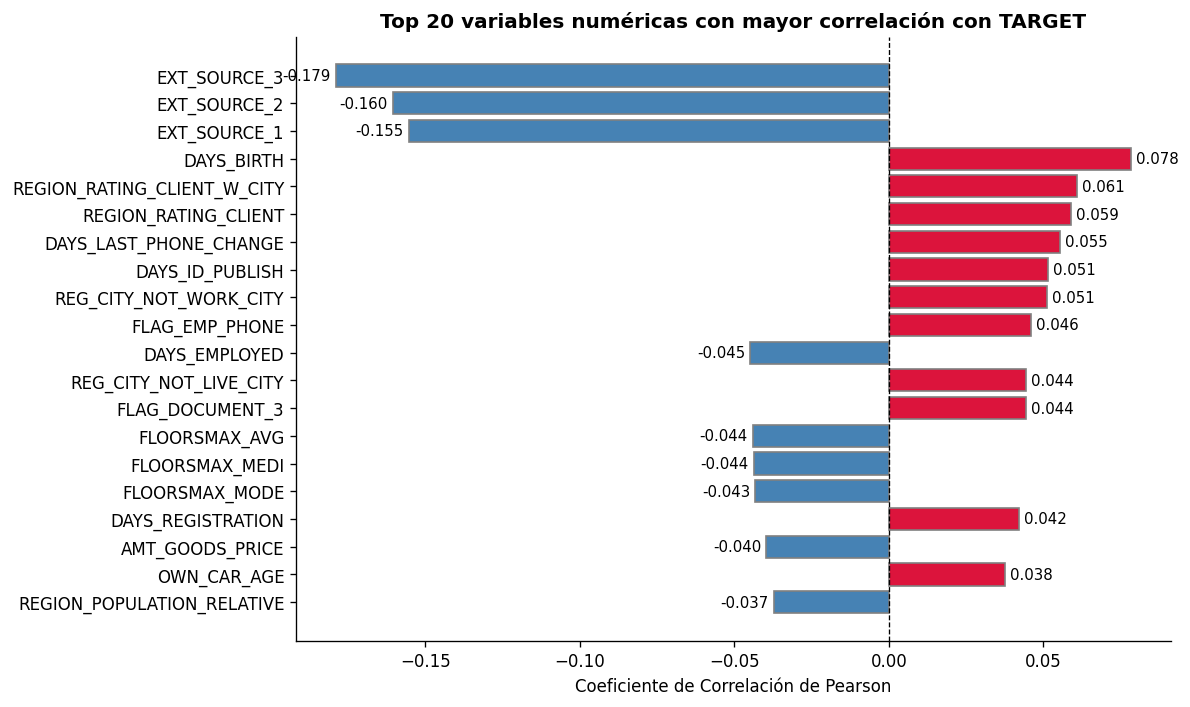

In [23]:
# Correlación de variables numéricas con TARGET
# Calculo y ordeno por valor absoluto luego filtro el top 20 
num_cols = app.select_dtypes(include=[np.number]).columns.drop(['SK_ID_CURR', 'TARGET'], errors='ignore')
top_corr = app[num_cols].corrwith(app['TARGET']).sort_values(key=abs, ascending=False).head(20)

print('Ranking de correlación de variables numéricas con TARGET (Top 20):')
display(top_corr.to_frame('Corr').style.format('{:.4f}'))

# Gráfico de barras de correlación con TARGET
fig, ax = plt.subplots(figsize=(10, 6))

# Como top_corr es una Serie, la paso directamente a np.where y ax.barh
colors = np.where(top_corr > 0, color_default, color_no_default)
bars = ax.barh(top_corr.index, top_corr, color=colors, edgecolor='gray')

ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Top 20 variables numéricas con mayor correlación con TARGET', fontsize=12, fontweight='bold')
ax.set_xlabel('Coeficiente de Correlación de Pearson')
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.show()



Parejas de variables numéricas con alta correlación (|r| > 0.7):


,Var1,Var2,Corr
704,DAYS_EMPLOYED,FLAG_EMP_PHONE,-0.9998
2898,YEARS_BUILD_AVG,YEARS_BUILD_MEDI,0.9985
4892,OBS_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,0.9985
3238,FLOORSMIN_AVG,FLOORSMIN_MEDI,0.9972
3172,FLOORSMAX_AVG,FLOORSMAX_MEDI,0.9970
3105,ENTRANCES_AVG,ENTRANCES_MEDI,0.9969
3037,ELEVATORS_AVG,ELEVATORS_MEDI,0.9961
2968,COMMONAREA_AVG,COMMONAREA_MEDI,0.9960
3430,LIVINGAREA_AVG,LIVINGAREA_MEDI,0.9956
2682,APARTMENTS_AVG,APARTMENTS_MEDI,0.9951


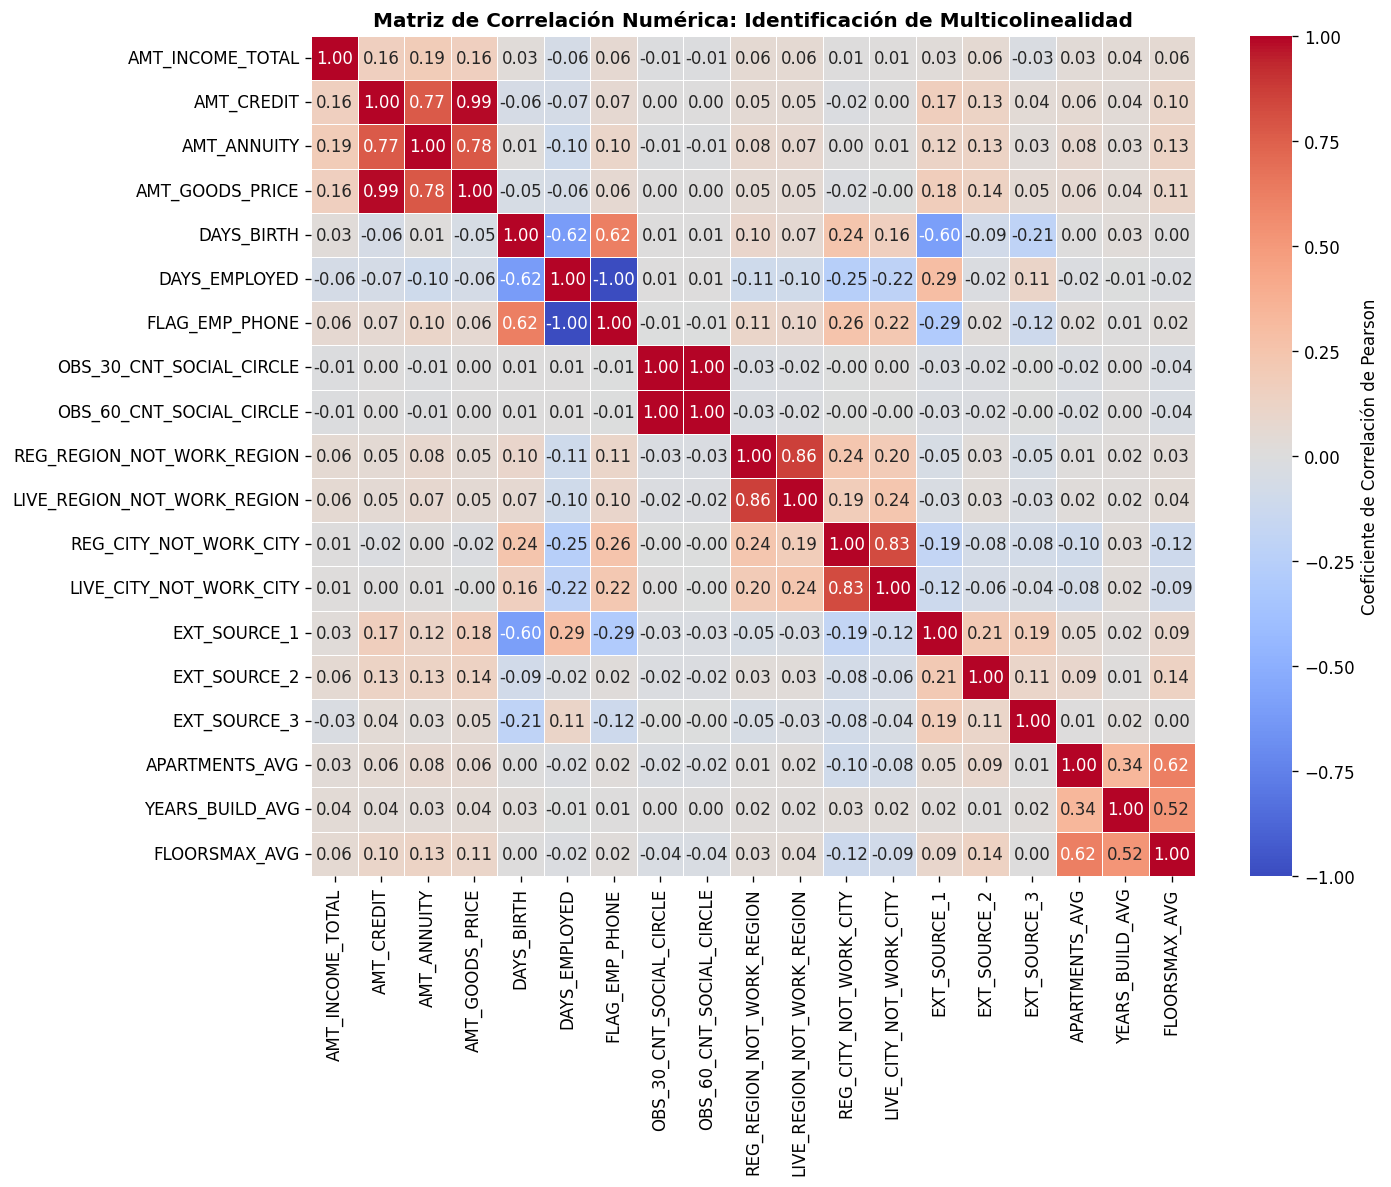

In [24]:
# Correlación entre variables numéricas (Multicolinealidad)
# Calculo la matriz utilizando la lista de nombres num_cols de la celda anterior
corr_matrix_full = app[num_cols].corr() 

# Extraigo el triángulo superior ordenado
ix, jx = np.triu_indices_from(corr_matrix_full, k=1)
high_corr = pd.DataFrame({
    'Var1': corr_matrix_full.columns[ix],
    'Var2': corr_matrix_full.columns[jx],
    'Corr': corr_matrix_full.values[ix, jx]
})
high_corr = high_corr[high_corr['Corr'].abs() > 0.7].sort_values(by='Corr', key=abs, ascending=False)

print('\nParejas de variables numéricas con alta correlación (|r| > 0.7):')
# Aplico el formato sólo a la columna 'Corr'
display(high_corr.head(15).style.format({'Corr': '{:.4f}'}))

# Heatmap de variables seleccionadas representativas de bloques de información
col_selection = [
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
    'DAYS_BIRTH', 'DAYS_EMPLOYED', 'FLAG_EMP_PHONE',
    'OBS_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE',
    'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION',
    'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY',
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'APARTMENTS_AVG', 'YEARS_BUILD_AVG', 'FLOORSMAX_AVG'
]

# Filtro y calculo la submatriz directamente
corr_matrix_sub = app[[c for c in col_selection if c in app]].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix_sub, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, center=0,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Coeficiente de Correlación de Pearson'})
ax.set_title('Matriz de Correlación Numérica: Identificación de Multicolinealidad', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()



Parejas de variables categóricas ordenadas por fuerza de asociación (V de Cramér):


,Var1,Var2,CramersV
41,NAME_INCOME_TYPE,ORGANIZATION_TYPE,0.4226
18,CODE_GENDER,OCCUPATION_TYPE,0.4048
90,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,0.3172
71,OCCUPATION_TYPE,ORGANIZATION_TYPE,0.3013
20,CODE_GENDER,ORGANIZATION_TYPE,0.2388
48,NAME_EDUCATION_TYPE,OCCUPATION_TYPE,0.2191
39,NAME_INCOME_TYPE,OCCUPATION_TYPE,0.1454
87,FONDKAPREMONT_MODE,EMERGENCYSTATE_MODE,0.1404
50,NAME_EDUCATION_TYPE,ORGANIZATION_TYPE,0.1287
58,NAME_FAMILY_STATUS,ORGANIZATION_TYPE,0.1209


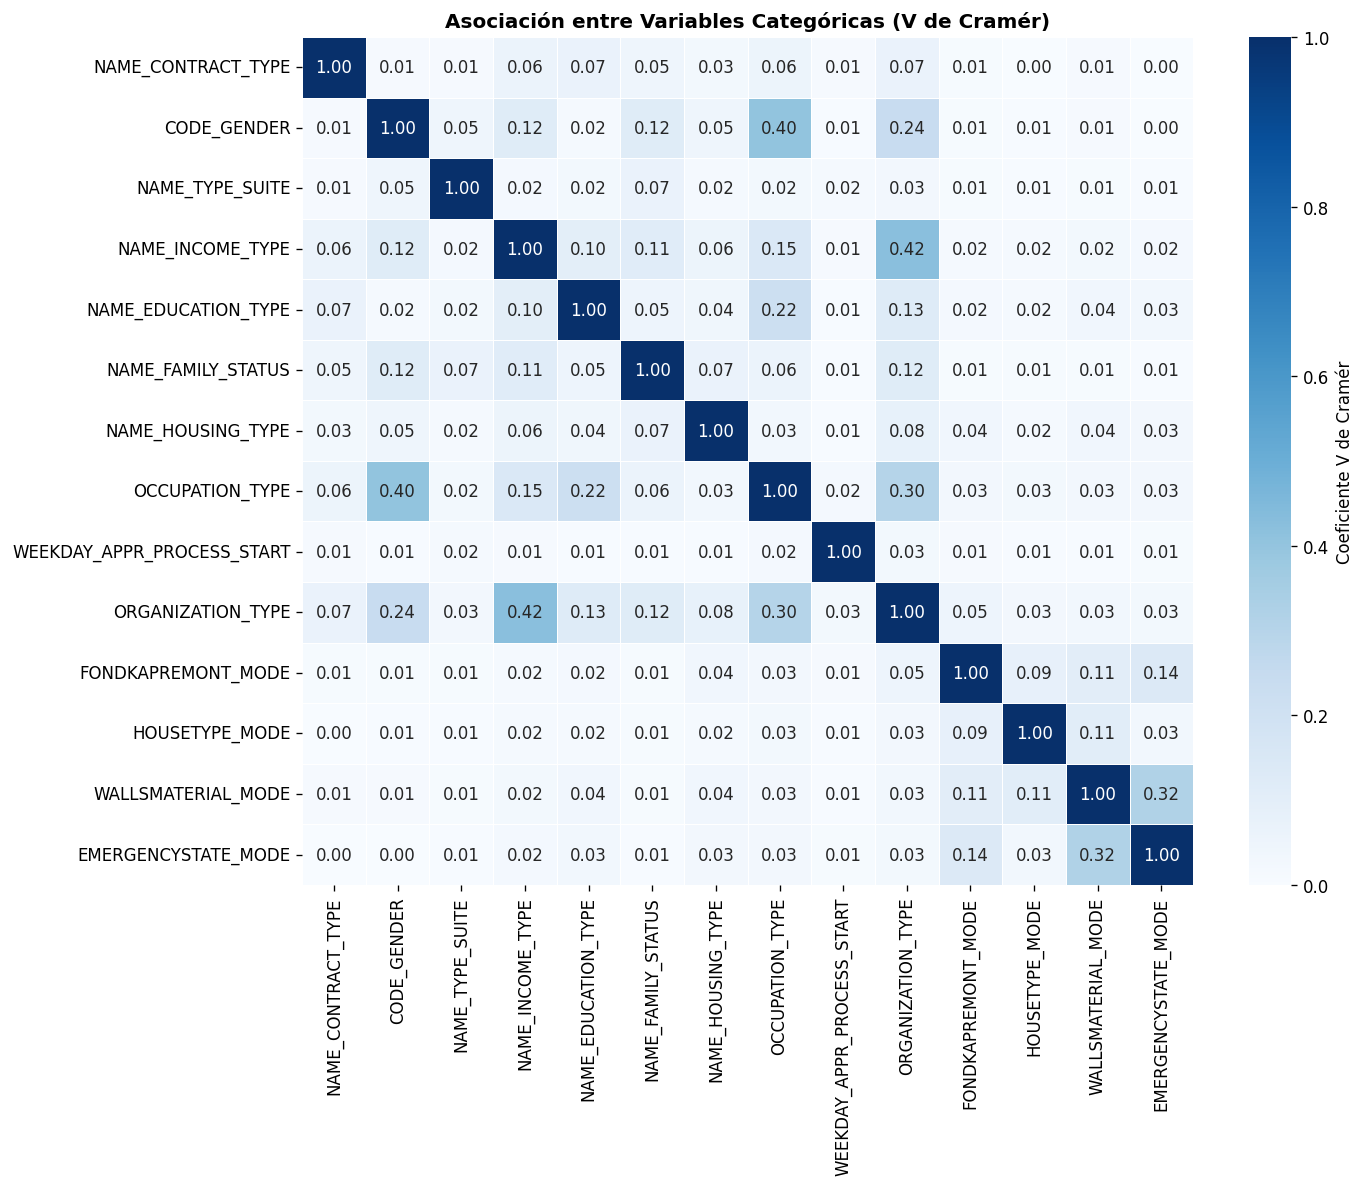

In [25]:
# Asociación entre variables categóricas (V de Cramér)
# Selecciono todas las variables categóricas
cat_cols = app.select_dtypes(include=['object', 'category']).columns

# Convierto a categoría una sola vez para extraer los códigos y cardinalidades
cat_dfs = [app[col].astype('category') for col in cat_cols]
codes_list = [c.cat.codes.values for c in cat_dfs]
num_categories = [len(c.cat.categories) for c in cat_dfs]

n_cols = len(cat_cols)
matrix = np.zeros((n_cols, n_cols))

# Cálculo Cramér's V con bincount
for i in range(n_cols):
    c1, n1 = codes_list[i], num_categories[i]
    for j in range(i, n_cols):
        if i == j:
            val = 1.0
        else:
            c2, n2 = codes_list[j], num_categories[j]
            # Filtro nulos (códigos -1)
            mask = (c1 >= 0) & (c2 >= 0)
            c1_v, c2_v = c1[mask], c2[mask]
            n_samples = len(c1_v)

            if n_samples == 0 or n1 <= 1 or n2 <= 1:
                val = 0.0
            else:
                # 2D bincount rápido (casteo a int64 para evitar overflow)
                flat_index = c1_v.astype(np.int64) * n2 + c2_v.astype(np.int64)
                confusion = np.bincount(flat_index, minlength=n1 * n2).reshape(n1, n2)
                
                # Descarto filas/columnas vacías residuales creadas por NaNs
                confusion = confusion[confusion.sum(axis=1) > 0]
                confusion = confusion[:, confusion.sum(axis=0) > 0]
                
                r, k = confusion.shape
                if r <= 1 or k <= 1:
                    val = 0.0
                else:
                    chi2 = chi2_contingency(confusion, correction=False)[0]
                    val = np.sqrt(chi2 / (n_samples * min(r - 1, k - 1)))
                    
        matrix[i, j] = val
        matrix[j, i] = val

df_v = pd.DataFrame(matrix, index=cat_cols, columns=cat_cols)

# Extraigo las parejas más asociadas
ix, jx = np.triu_indices_from(df_v, k=1)
high_v = pd.DataFrame({
    'Var1': df_v.columns[ix],
    'Var2': df_v.columns[jx],
    'CramersV': df_v.values[ix, jx]
}).sort_values(by='CramersV', ascending=False)

print('\nParejas de variables categóricas ordenadas por fuerza de asociación (V de Cramér):')
display(high_v.head(15).style.format({'CramersV': '{:.4f}'}))

# Heatmap de V de Cramér
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(df_v, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Coeficiente V de Cramér'})
ax.set_title('Asociación entre Variables Categóricas (V de Cramér)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


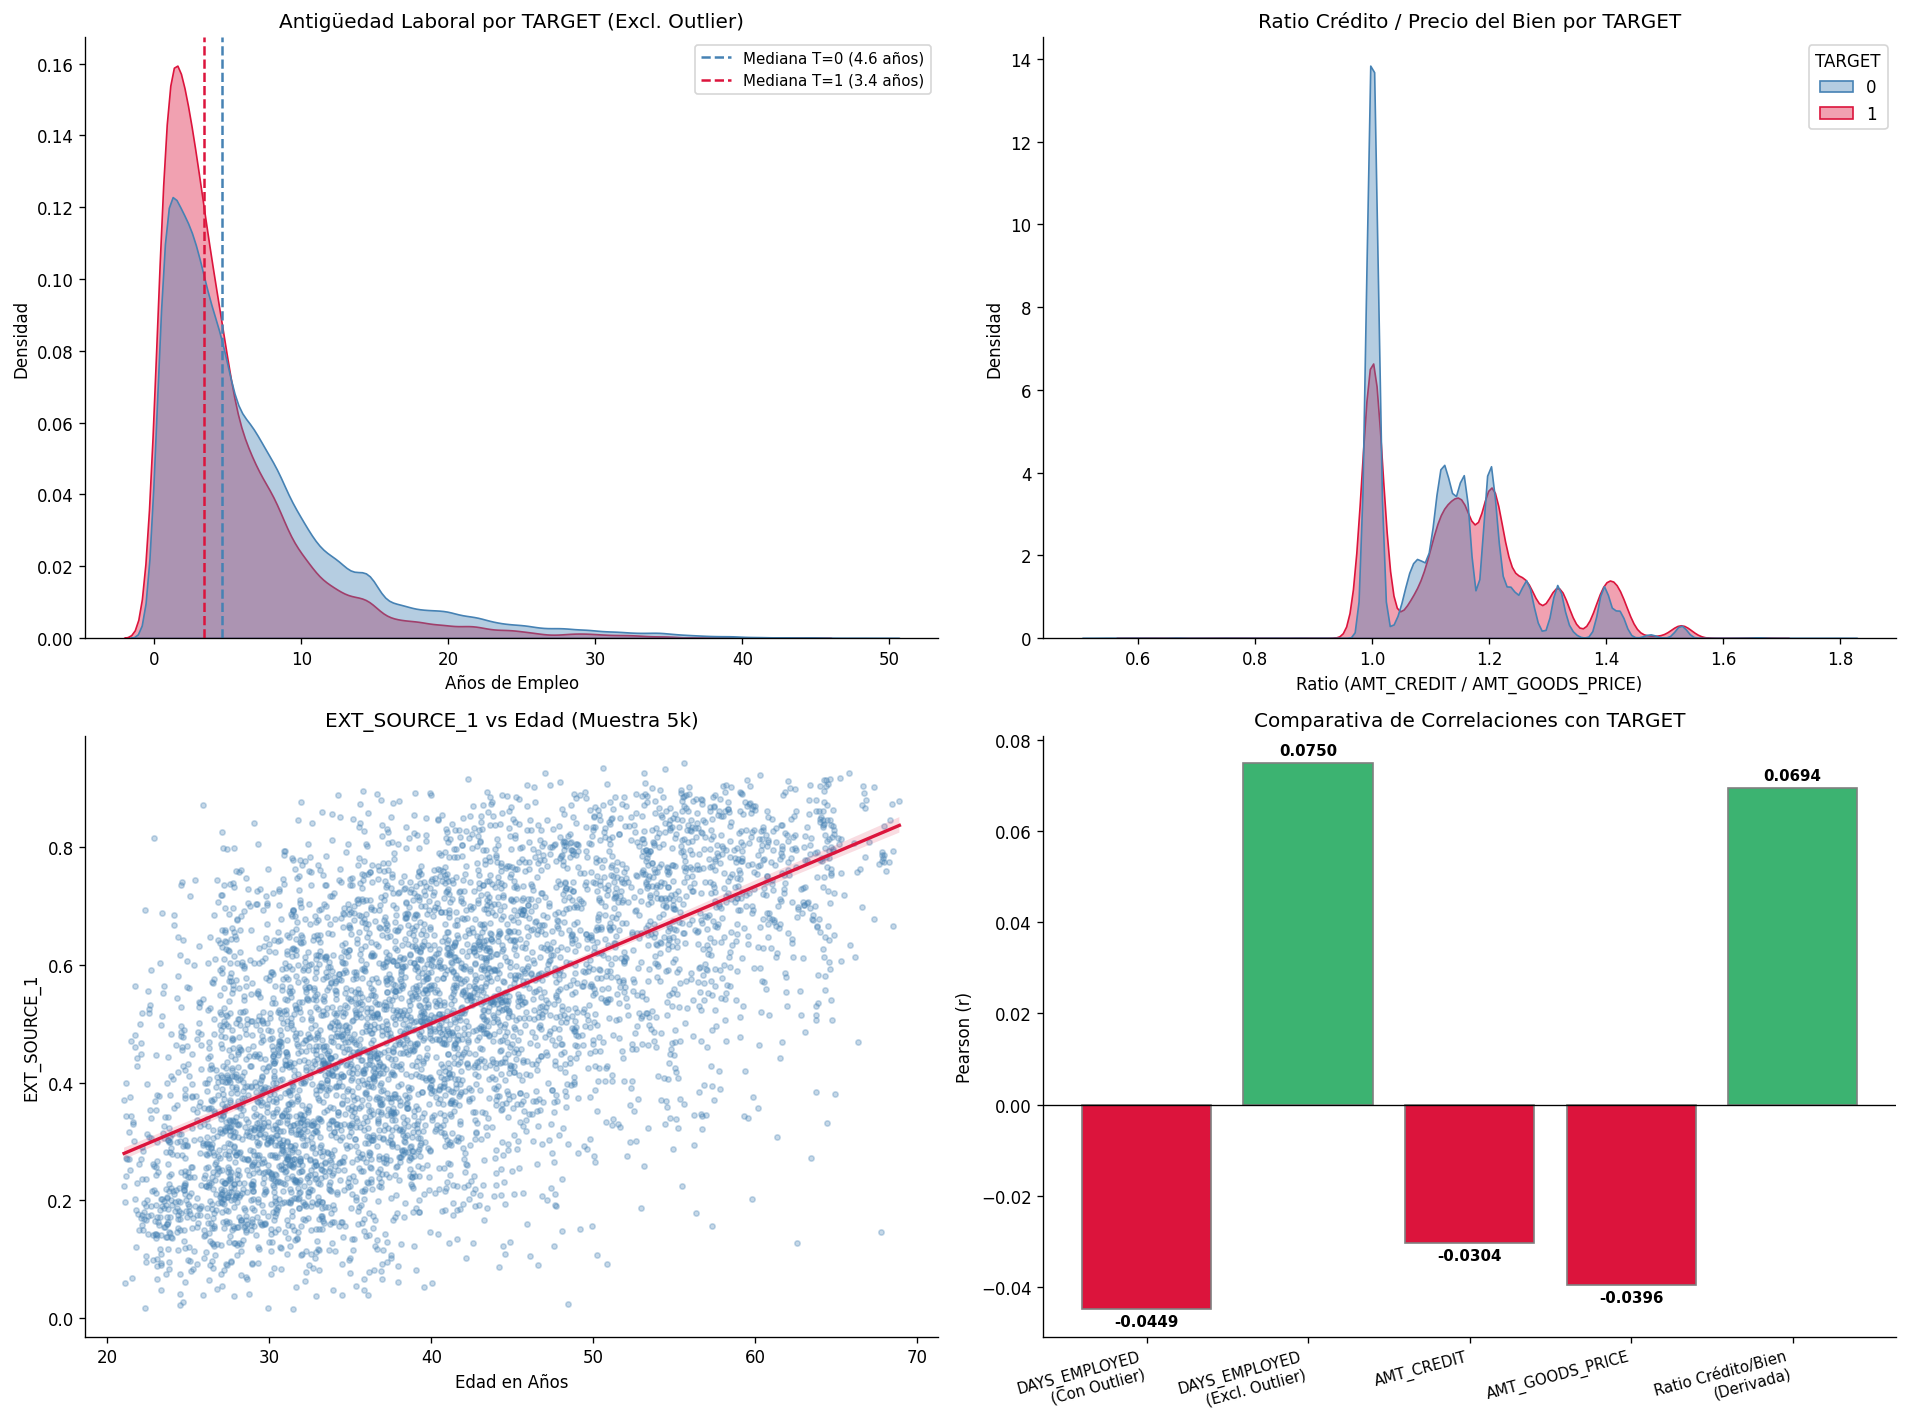

,No reporta tel. empleo,Reporta tel. empleo
Empleado,12,"252,125"
Pensionista / Outlier (365243),"55,374",0


In [26]:
# Vectorizo las operaciones estadísticas
# Configuro la figura 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Grafico 1: Antigüedad Laboral (Excluyo Outlier)
df_emp = app.loc[app['DAYS_EMPLOYED'] != 365243, ['DAYS_EMPLOYED', 'TARGET']]
years = -df_emp['DAYS_EMPLOYED'] / 365.25
sns.kdeplot(x=years, hue=df_emp['TARGET'], palette=[color_no_default, color_default], fill=True, common_norm=False, alpha=0.4, ax=axes[0, 0])
m0, m1 = years.groupby(df_emp['TARGET']).median()
axes[0, 0].axvline(m0, color=color_no_default, linestyle='--', label=f'Mediana T=0 ({m0:.1f} años)')
axes[0, 0].axvline(m1, color=color_default, linestyle='--', label=f'Mediana T=1 ({m1:.1f} años)')
axes[0, 0].set(title='Antigüedad Laboral por TARGET (Excl. Outlier)', xlabel='Años de Empleo', ylabel='Densidad')
axes[0, 0].legend(fontsize=9)

# Grafico 2: Ratio Crédito / Precio del Bien
ratio = app['AMT_CREDIT'] / app['AMT_GOODS_PRICE']
valid = ratio.notnull() & (ratio < 2.0) & (ratio > 0.5)
sns.kdeplot(x=ratio[valid], hue=app.loc[valid, 'TARGET'], palette=[color_no_default, color_default], fill=True, common_norm=False, alpha=0.4, ax=axes[0, 1])
axes[0, 1].set(title='Ratio Crédito / Precio del Bien por TARGET', xlabel='Ratio (AMT_CREDIT / AMT_GOODS_PRICE)', ylabel='Densidad')

# Grafico 3: EXT_SOURCE_1 vs Edad
sample_df = app[['DAYS_BIRTH', 'EXT_SOURCE_1']].dropna().sample(5000, random_state=42)
# seaborn 0.13 + numpy 2 emiten RuntimeWarning en el bootstrap del IC;
# la recta ajustada es correcta (verificada contra np.polyfit)
with warnings.catch_warnings():
    warnings.simplefilter('ignore', RuntimeWarning)
    sns.regplot(x=-sample_df['DAYS_BIRTH'] / 365.25, y=sample_df['EXT_SOURCE_1'], scatter_kws={'alpha': 0.3, 'color': color_no_default, 's': 10}, line_kws={'color': color_default, 'linewidth': 2}, ax=axes[1, 0])
axes[1, 0].set(title='EXT_SOURCE_1 vs Edad (Muestra 5k)', xlabel='Edad en Años', ylabel='EXT_SOURCE_1')

# Grafico 4: Comparativa de Correlaciones
corr_all = app['DAYS_EMPLOYED'].corr(app['TARGET'])
corr_clean = df_emp['DAYS_EMPLOYED'].corr(df_emp['TARGET'])
corr_ratio = ratio.corr(app['TARGET'])

corr_data = {
    'Variable / Condición': ['DAYS_EMPLOYED\n(Con Outlier)', 'DAYS_EMPLOYED\n(Excl. Outlier)', 'AMT_CREDIT', 'AMT_GOODS_PRICE', 'Ratio Crédito/Bien\n(Derivada)'],
    'Corr': [corr_all, corr_clean, app['AMT_CREDIT'].corr(app['TARGET']), app['AMT_GOODS_PRICE'].corr(app['TARGET']), corr_ratio]
}
df_corr = pd.DataFrame(corr_data)
colors = [color_default if val < 0 else color_presente for val in df_corr['Corr']]
bars = axes[1, 1].bar(df_corr['Variable / Condición'], df_corr['Corr'], color=colors, edgecolor='gray')
axes[1, 1].axhline(0, color='black', linewidth=0.8)
axes[1, 1].set(title='Comparativa de Correlaciones con TARGET', ylabel='Pearson (r)')
axes[1, 1].bar_label(bars, fmt='%.4f', padding=3, fontsize=9, fontweight='bold')
plt.setp(axes[1, 1].get_xticklabels(), rotation=15, ha='right', fontsize=9)

plt.tight_layout()
plt.show()

# Contraste de Redundancia
ct_emp = pd.crosstab(app['DAYS_EMPLOYED'] == 365243, app['FLAG_EMP_PHONE'])
ct_emp.index = ['Empleado', 'Pensionista / Outlier (365243)']
ct_emp.columns = ['No reporta tel. empleo', 'Reporta tel. empleo']
display(HTML("<h4>Redundancia Estructural: DAYS_EMPLOYED vs FLAG_EMP_PHONE</h4>"))
display(ct_emp.style.background_gradient(cmap='Blues', axis=None).format('{:,}'))


### Conclusiones de Correlaciones

El ranking de correlación de Pearson revela una estructura predictiva de dos niveles con un salto brusco (x2) entre la 3ª y la 4ª variable:

- **Nivel 1 (|r| > 0.15)**: Scores externos. `EXT_SOURCE_3` (r = -0.179), `EXT_SOURCE_2` (r = -0.160) y `EXT_SOURCE_1` (r = -0.155) son, con diferencia, las variables predictoras LINEALES más fuertes. El signo negativo indica que a mayor score externo, menor probabilidad de default, coherente con la naturaleza de scoring crediticio. Esto confirma lo planteado y observado en la sección anterior del análisis de missings, donde las distribuciones KDE mostraban una separación clara entre clases.

- **Nivel 2 (|r| < 0.08)**: El resto. Tras los scores externos, la señal va diluyéndose entre el resto de variables a menos de la mitad. `DAYS_BIRTH` (r = +0.078) indica que los solicitantes más jóvenes tienen mayor riesgo (`DAYS_BIRTH` es más negativo para personas más viejas, así que una correlación positiva con TARGET implica que valores menos negativos, es decir, edades más jóvenes, se asocian a más default). Confirma nuestra hipótesis en la sección anterior.

Ninguna variable individual del Nivel 2 es un predictor LINEAL fuerte por sí sola, lo que indica que deberé aplicar un modelo multivariante más adelante para combinar multitud de señales débiles.

**`DAYS_EMPLOYED`** y el outlier 365243. La correlación reportada de `DAYS_EMPLOYED` con TARGET es r = -0.045, pero esta cifra está distorsionada por el outlier de 365243 detectado anteriormente. El 18% de las obs tiene este valor (pensionistas/desempleados), cuyo default rate es 5.4% frente al 8.7% del resto. Si se excluyera el outlier, la correlación subiría a r = +0.075, llegando a duplicarse y cambiando de signo (lo que confirma que a más antigüedad laboral, menos riesgo). Esto se respalda visualmente en el Panel 1 del soporte, donde vemos que la mediana de antigüedad laboral para clientes sin default (T=0) es de 5.0 años frente a 3.7 años para clientes con default (T=1).

**`FLAG_EMP_PHONE`** es redundante. Aparece en el top 10 (r = +0.046), pero es estructuralmente redundante. El tab cruzadoa del soporte demuestra que `FLAG_EMP_PHONE` es casi una señal perfecta de si el cliente reporta empleo (es decir, `DAYS_EMPLOYED distinto 365243`): para el 100% de los pensionistas/outliers es 0, y para el 99.99% (excepto 12 observaciones) de los empleados es 1. Por tanto, debe eliminarse.

**`FLOORSMAX` conecta con el bloque de edificio.** Las tres variantes (`_AVG`, `_MEDI`, `_MODE`) aparecen consecutivamente en posiciones 14-16 con r ≈ -0.044, confirmando dos cosas: la señal del bloque de edificio es débil pero real (más pisos implica una zona más urbana y por tanto menos default), y que las tres variantes son redundantes entre sí, como indicamos anteriormente.

**`REGION_RATING_CLIENT_W_CITY`** y **`REGION_RATING_CLIENT`** aparecen en posiciones 5 y 6 con correlaciones positivas de 0.061 y 0.059. Recordando que el rating va de 1 (alta calidad) a 3 (baja calidad), una correlación positiva confirma que vivir en zonas peor valoradas se asocia con mayor riesgo de default.

**`DAYS_LAST_PHONE_CHANGE`** tiene una correlación de +0.055. Dado que esta variable toma valores negativos (días transcurridos desde el cambio), una correlación positiva indica que cambiar de teléfono recientemente (valores cercanos a 0) se asocia con un **mayor** riesgo de default. Esto se confirma estadísticamente: los clientes que cambiaron su teléfono hace menos de 5 meses registran un default rate de aprox 9.4%, mientras que aquellos que lo conservan por más de 4.7 años descienden aprox un 5.7% de default. Esto desmiente la intuición de que un cambio reciente muestre un perfil más ordenado, apuntando en su lugar a inestabilidad residencial, laboral o de contacto.

**Limitación.** El coeficiente de Pearson captura exclusivamente relaciones LINEALES. Variables categóricas codificadas numéricamente como los flags pueden tener poder predictivo real que Pearson subestima.


**Variables de edificio `_AVG` / `_MEDI` / `_MODE`** (r > 0.97). Las 14 características de edificio se presentan en tres variantes con correlaciones entre sí superiores a 0.97 (ej: `YEARS_BUILD_AVG` vs `_MEDI` → r = 0.998). Esto confirma lo anticipado en el análisis anterior de distribuciones: las tres variantes son esencialmente la misma información con diferencias de escala. La reducción de 46 columnas de edificio a 14 es una decisión y reducirá el ruido sin perder señal. Se priorizará la variante `_AVG` ya que mantiene el mismo % de nulos que las otras y su media aritmética es más estable frente a outliers que la moda.

**`DAYS_EMPLOYED`** vs **`FLAG_EMP_PHONE`** (r = -0.999). Confirmado por la correlación y la tabla de contingencia; representan la misma información. Se debe eliminar `FLAG_EMP_PHONE` ya que `DAYS_EMPLOYED` contiene la misma información de forma continua y más granular.

**`OBS_30_CNT_SOCIAL_CIRCLE`** vs **`OBS_60_CNT_SOCIAL_CIRCLE`** (r = 0.998) producen conteos casi idénticos. Basta con conservar una de ellas. Por lo que elegiré `OBS_30_CNT_SOCIAL_CIRCLE` (ventana más reciente implica tener un dato más actual).

**`AMT_CREDIT`** vs **`AMT_GOODS_PRICE`** (r = 0.987). Esto indica que el crédito solicitado es prácticamente igual al precio del bien que se solicita. Aunque la correlación es casi 1 entre ellas, el **ratio** `AMT_CREDIT / AMT_GOODS_PRICE` tiene una correlación con TARGET de r = +0.069 (visualizado en Panel 2 y comparado en Panel 4), muy superior a la de ambas variables por separado (r = -0.030 y -0.040 respectivamente).

**`REG_REGION_NOT_WORK_REGION`** vs **`LIVE_REGION_NOT_WORK_REGION`** tienen r = 0.86 y **`REG_CITY_NOT_WORK_CITY`** vs **`LIVE_CITY_NOT_WORK_CITY`** tienen r = 0.83. Sin embargo, sus correlaciones con TARGET difieren: la variante `REG_CITY_NOT_WORK_CITY` (r = +0.051) supera ampliamente a `LIVE_CITY_NOT_WORK_CITY` (r = +0.033) y a las variantes de región (r < 0.007). Además, `REG_CITY_NOT_LIVE_CITY` (r = +0.044) aporta señal casi independiente de las anteriores (baja correlación con ellas: r aprox 0.03-0.44). Más adelante eliminaré las variables geográficas más débiles sin pérdida significativa de información.

Observo además correlación de -0.60 entre `EXT_SOURCE_1` y `DAYS_BIRTH`. No es problemática pero muestra una interacción entre ambas, detallada en el Panel 3: los clientes más jóvenes tienen scores externos más bajos, probablemente debido a que cuentan con un historial acumulado menor.

El heatmap muestra que la gran mayoría de pares tienen V < 0.10 (asociación negligible), confirmando que el espacio categórico NO requiere reducción agresiva a diferencia del bloque numérico de edificio.

Los pares más asociados revelan una estructura interpretable:

- **`NAME_INCOME_TYPE` vs `ORGANIZATION_TYPE` (V = 0.42)**: La asociación más fuerte. Es natural ya que el tipo de ingreso condiciona la organización. Sin embargo, V = 0.42 (moderada) implica que no son redundantes (ya que un pensionista no aparecerá como Business y un funcionario aparecerá en Government). Pero la información no es redundante porque `NAME_INCOME_TYPE` captura la naturaleza de los ingresos y `ORGANIZATION_TYPE` captura el sector económico. Ambas se deben conservar.

- **`CODE_GENDER` vs `OCCUPATION_TYPE` (V = 0.40)**: Con un 0.40, reflejan una asociación moderada de forma que determinadas ocupaciones están condicionadas por el sexo (más conductores hombres, más auxiliares mujeres) reflejando así la realidad sociolaboral del dataset. Sin embargo, la ocupación aporta una dimensión laboral que el género no captura. Por lo que nuevamente, mantendré ambas.

- **`CODE_GENDER` vs `FLAG_OWN_CAR` (V = 0.35)**: Cuantifica formalmente lo que detecté en la sección de análisis de `OWN_CAR_AGE`: los hombres son significativamente más propensos a tener coche propio.

- **`WALLSMATERIAL_MODE` vs `EMERGENCYSTATE_MODE` (V = 0.32)**: Coherente con que el material de las paredes determina parcialmente si un edificio está en estado de emergencia.

- **`OCCUPATION_TYPE` es un hub de asociación.** Aparece en 5 de los 10 primeros pares (con `CODE_GENDER`, `ORGANIZATION_TYPE`, `FLAG_OWN_CAR`, `NAME_EDUCATION_TYPE` y `NAME_INCOME_TYPE`). Esto la convierte en una variable central que media parcialmente la relación entre género, educación, ingreso y organización. Es una variable a conservar, a pesar de su alto porcentaje de nulos (31%), ya que actúa como puente entre múltiples dimensiones del perfil socioeconómico.

- **`WALLSMATERIAL_MODE`** vs **`EMERGENCYSTATE_MODE`** con 0.32. Ambas son variables del bloque edificio y comparten el patrón estructural de nulos, lo que explica parte de la asociación resultante. Pero como las trataré como un bloque unificado vía `HAS_BUILDING_INFO` no habrá problemas.

- **`NAME_EDUCATION_TYPE`** vs **`OCCUPATION_TYPE`** con 0.22, indican una asociación débil. Tiene lógica ya que los puestos cualificados suelen requerir una mayor educación pero la asociación es modesta. Por lo que me decantaré por mantener ambas variables para conservar información útil por separado.

El resto de pares están por debajo de 0.20, lo que indica que las variables categóricas son en su mayoría independientes entre sí en términos de información compartida.

## 7. Análisis temporal

Controles de consistencia lógica temporal:
  Edades negativas: 0
  Antigüedades laborales negativas: 0
  Antigüedad laboral > Edad: 0
  Registro > Edad (estricto): 454
  Registro > Edad (tolerancia > 1 día): 0
  Cambios de teléfono negativos: 0


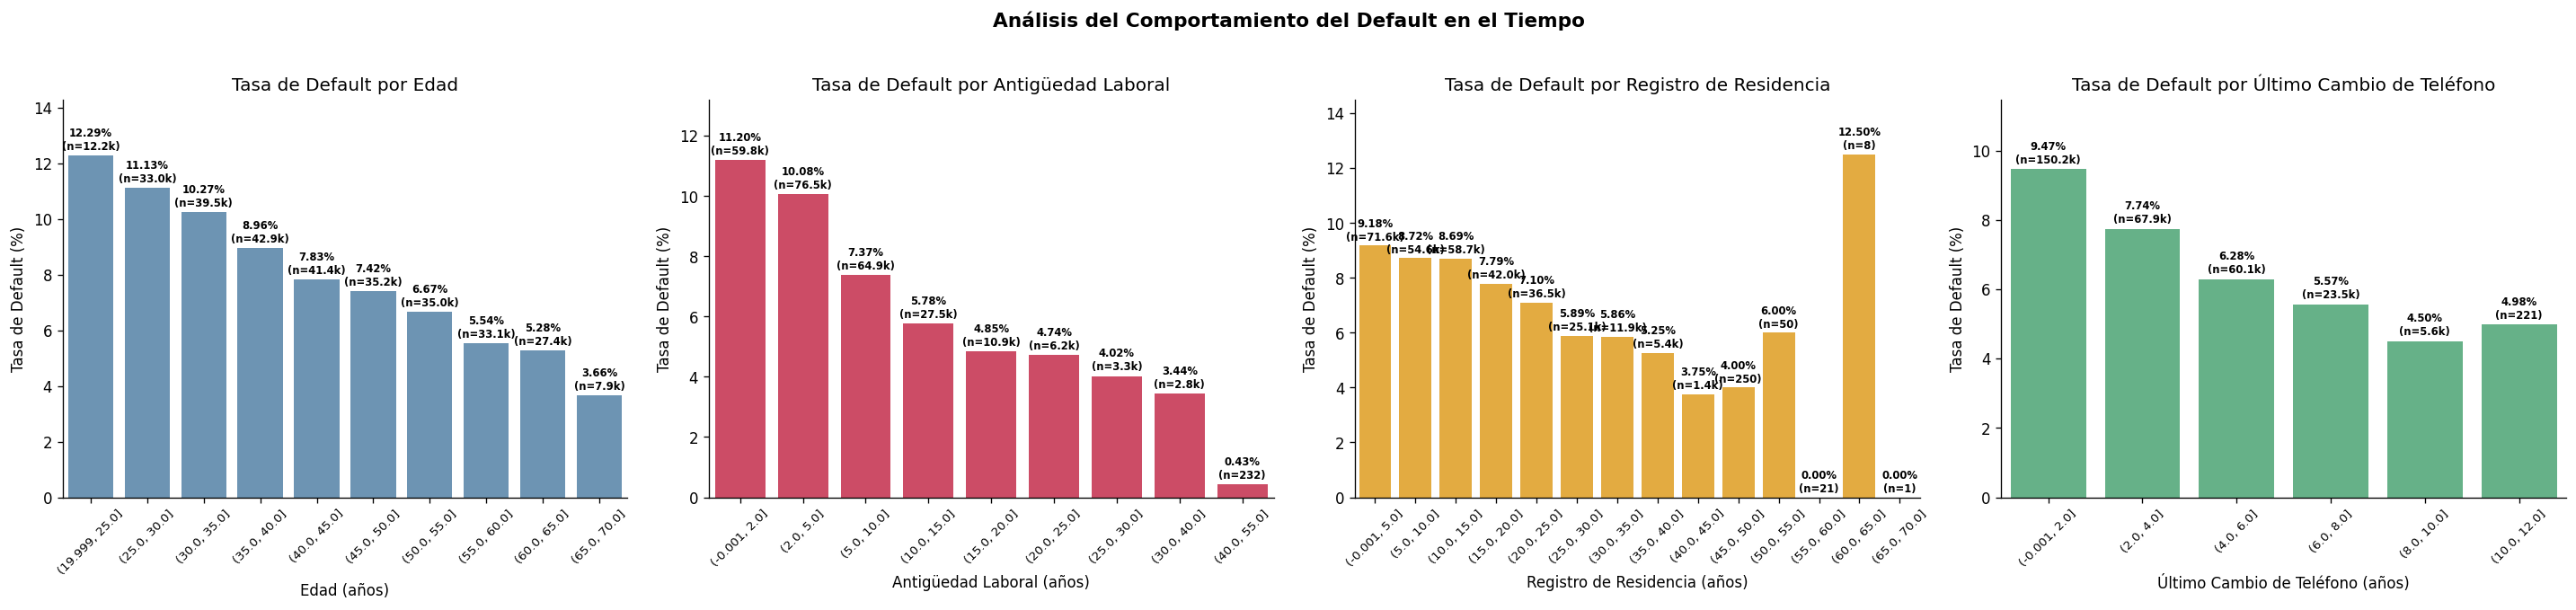

,Estadístico U,p-valor,Tamaño del Efecto (r_rb),Significancia
Variable,,,,
Edad (años),"4,091,325,258.5",0.0000e+00,0.1660,Altamente Significativo
Antigüedad Laboral (años),"2,928,637,092.5",0.0000e+00,0.1648,Altamente Significativo
Registro de Residencia (años),"3,807,567,984.0",6.3041e-110,0.0851,Altamente Significativo
Último Cambio de Teléfono (años),"3,907,877,035.5",6.1941e-195,0.1137,Altamente Significativo


In [27]:
# Transformación y agrupación temporal
# Proceso las variables temporales mediante un diccionario
vars_data = {
    'Edad': (-app['DAYS_BIRTH'] / 365.25, range(20, 71, 5), color_no_default),
    'Antigüedad Laboral': (-app['DAYS_EMPLOYED'].replace(365243, np.nan) / 365.25, [0, 2, 5, 10, 15, 20, 25, 30, 40, 55], color_default),
    'Registro de Residencia': (-app['DAYS_REGISTRATION'] / 365.25, range(0, 71, 5), color_nulo),
    'Último Cambio de Teléfono': (-app['DAYS_LAST_PHONE_CHANGE'] / 365.25, range(0, 13, 2), color_presente)
}

# Aplico controles de consistencia lógica
print('Controles de consistencia lógica temporal:')
edad, ant, reg, tel = [v[0] for v in vars_data.values()]
for m, c in {
    'Edades negativas': (edad < 0).sum(),
    'Antigüedades laborales negativas': (ant < 0).sum(),
    'Antigüedad laboral > Edad': (ant > edad).sum(),
    'Registro > Edad (estricto)': (reg > edad).sum(),
    'Registro > Edad (tolerancia > 1 día)': (reg > (edad + 1/365.25)).sum(),
    'Cambios de teléfono negativos': (tel < 0).sum()
}.items():
    print(f'  {m}: {c}')

# Agrupo y visualizado 4 paneles que muestren numero de obs (tamaño muestral)
fig, axes = plt.subplots(1, 4, figsize=(24, 5.5))
for ax, (title, (s, bins, col)) in zip(axes, vars_data.items()):
    # Aplico include_lowest=True en pd.cut para contabilizar los del mismo dia
    cuts = pd.cut(s, bins=bins, include_lowest=True)
    counts = cuts.value_counts(sort=False)
    rates = app.groupby(cuts, observed=False)['TARGET'].mean() * 100
    
    sns.barplot(x=rates.index.astype(str), y=rates.values, ax=ax, color=col, alpha=0.85)
    ax.set(title=f'Tasa de Default por {title}', xlabel=f'{title} (años)', ylabel='Tasa de Default (%)', ylim=(0, rates.max() + 2.0))
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    
    # Añado los porcentajes de default y el n de obs de cada rango
    for bar, count in zip(ax.patches, counts.values):
        rate = bar.get_height()
        count_str = f'{count/1000:.1f}k' if count >= 1000 else f'{count}'
        text_str = f'{rate:.2f}%\n(n={count_str})'
        ax.text(bar.get_x() + bar.get_width()/2, rate + 0.1, text_str, ha='center', va='bottom', fontsize=7, fontweight='bold')

plt.suptitle('Análisis del Comportamiento del Default en el Tiempo', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Aplico contrastes estadísticos Mann-Whitney U con Rank-Biserial 
stats = []
for name, (s, _, _) in vars_data.items():
    x, y = s[app['TARGET'] == 0].dropna(), s[app['TARGET'] == 1].dropna()
    u, p = mannwhitneyu(x, y, alternative='two-sided')
    
    # Calculo la correlacion rank-biserial correlation
    r_rb = abs((2 * u) / (len(x) * len(y)) - 1)
    
    stats.append({
        'Variable': f'{name} (años)', 'Estadístico U': u, 'p-valor': p,
        'Tamaño del Efecto (r_rb)': r_rb, 'Significancia': 'Altamente Significativo' if p < 0.01 else 'No Significativo'
    })

display(pd.DataFrame(stats).set_index('Variable').style.format({
    'Estadístico U': '{:,.1f}', 'p-valor': '{:.4e}', 'Tamaño del Efecto (r_rb)': '{:.4f}'
}))


**Consistencia lógica temporal.** Los controles de validación temporal confirman la robustez de los datos de entrada para variables temporales: no existen edades ni antigüedades laborales negativas (tras binarizar la antigüedad) ni solicitantes con más años de antigüedad laboral que de edad física (`antiguedad > edad` es 0). Todos los valores de días desde el último cambio de dispositivo son coherentes (mayores o iguales a cero). La presencia de 454 casos donde el año de registro supera la edad se debe a la precisión del tipo de datos (diferencias de precisión al comparar `float32` en `DAYS_REGISTRATION` vs `int32` en `DAYS_BIRTH`). Al aplicar un margen de tolerancia de tan solo 1 día, el número de inconsistencias se reduce a exactamente 0, lo que descarta errores reales de carga o inconsistencias lógicas en la base de datos.

---

**Relación entre Edad y Default.** Se observa una fuerte y constante relación inversa monótona entre la edad del solicitante y la tasa de default: los solicitantes de la franja más joven (20-25 años) presentan la tasa de default más elevada de toda la muestra (12.29%), seguidos de cerca por la franja de 25-30 años (11.13%). La edad se asocia con menor tasa de default, lo que es consistente con mayor estabilidad financiera acumulada por lógica, aunque no se puede descartar sesgo de selección: es decir, que los clientes que defaultearon jóvenes pueden no estar presentes en el dataset cuando llegan a edades avanzadas, lo que artificialmente reduciría la tasa observada en franjas mayores (65-70 años, con solo 3.66% de default). Este comportamiento de alto default en jóvenes correlaciona perfectamente con la relación observada entre `EXT_SOURCE_1` y la edad (correlación de -0.60), donde los clientes más jóvenes tienen scores externos más bajos simplemente porque llevan menos tiempo en el sistema financiero y han acumulado menos historial crediticio. Estadísticamente, la diferencia en las distribuciones de edad entre solicitantes con y sin default está validada mediante el test de Mann-Whitney U ($p\text{-valor} < 0.01$) con un estadístico U muy elevado de **4,091,325,258.5**. Dada la magnitud de las submuestras, un valor tan extremo confirma que la separación entre distribuciones es real y consistente en la población, no es algo visual. Su tamaño de efecto es moderado (correlación rank-biserial $r_{rb} \approx 0.166$).

---

**Estabilidad y Antigüedad Laboral.** La estabilidad laboral actúa como uno de los downgrades de riesgo más determinantes del dataset. Los clientes con menos de 2 años en su puesto actual registran un default muy elevado (11.20%), estabilizándose en torno al 10% para la franja de 2 a 5 años. Aquellos clientes que logran superar los 10 años de antigüedad muestran tasas de default inferiores al 5.78%, y perfiles con más de 25 años descienden por debajo del 3.4%. La franja extrema de 40-55 años muestra una tasa aparentemente ínfima de 0.43%; Sin embargo, esta tasa carece de fiabilidad estadística debido a la escasez de datos(como se visualiza en las etiquetas, esta franja cuenta con apenas n=232 obs frente a las decenas de miles de los rangos iniciales, lo que equivale a un único caso de default en dicho grupo y representa volatilidad muestral en lugar de un patrón generalizable). La permanencia en el empleo es un factor clave que estabiliza la probabilidad de pago, confirmada mediante el contraste de Mann-Whitney U ($p\text{-valor} < 0.01$) con un estadístico U muy elevado de **2,928,637,092.5**. La magnitud de este valor, dada la gran cantidad de datos, demuestra de forma inequívoca que la separación entre las distribuciones es real y consistente. Su tamaño de efecto es prácticamente idéntico al de la edad (correlación rank-biserial $r_{rb} \approx 0.165$).

---

**Conexión con Análisis de Missings y Efecto Jubilado.** El bajísimo volumen (n=232) y la tasa de default en el límite de la antigüedad extrema (40-55 años) está directamente conectado con el análisis de missings de `DAYS_EMPLOYED` y el efecto jubilado de `OCCUPATION_TYPE`. Estas 232 obs representan casi con certeza a personas en situación inactiva o pensionistas que sobrevivieron al filtro/reemplazo de `365243` por `NaN`, ya sea por ser valores extremos válidos o por ser casos límite en la carga de datos. Esto cierra de forma consistente y unifica tres análisis diferentes (missings, variables categóricas y análisis temporal) en la misma conclusión sobre la inactividad de bajo riesgo.

---

**Estabilidad Residencial (`DAYS_REGISTRATION`).** Para el 99.4% de los datos (de 0 a 40 años de registro), la tasa de default se comporta de manera estrictamente monótona decreciente (desde un 9.18% de default para cambios muy recientes de 0 a 5 años, hasta un 3.75% para registros estables de 40 a 45 años). En rangos superiores a los 45 años, la monotonía se rompe debido a la escasez (n=250 en `(45, 50]`, descendiendo progresivamente hasta un único registro $n=1$ en `(65, 70]`), lo que confirma empíricamente la presencia de fluctuaciones aleatorias en los extremos. La aparente subida en la franja `(55, 60]` de registro (12.50%) no es un hallazgo real sino un artefacto de n=8, equivalente a un único caso de default en dicho grupo. El test de Mann-Whitney U valida que la diferencia entre distribuciones es altamente significativa ($p\text{-valor} \approx 6.30 \times 10^{-110}$). Sin embargo, su tamaño de efecto es más discreto (correlación rank-biserial $r_{rb} \approx 0.085$), lo que demuestra que aunque la estabilidad residencial es una señal predictiva real, tiene un impacto secundario frente a la estabilidad financiera (antigüedad laboral) y la madurez del historial (edad).

---

**Cambio de Teléfono (`DAYS_LAST_PHONE_CHANGE`).** De forma análoga a la residencia, se incluyó el análisis del tiempo desde el último cambio de dispositivo, que presenta una correlación con el default superior a la residencia (Mann-Whitney U = **3,907,877,035.5**, $p\text{-valor} \approx 6.19 \times 10^{-195}$ y $r_{rb} \approx 0.114$). La tasa de default decrece de forma estrictamente monótona desde un 9.47% para cambios muy recientes (0 a 2 años, que incluye a los 37,672 clientes que cambiaron el teléfono el mismo día de la solicitud) hasta un 4.50% para perfiles con 8-10 años de estabilidad con el mismo dispositivo. Cambiar de teléfono el mismo día que solicitas un crédito o muy recientemente puede ser una señal de comportamiento de riesgo (movilidad alta o cambio de datos de contacto), lo que explicaría la mayor tasa observada en la franja inicial (0-2 años). Esto ratifica que la estabilidad en los hábitos del solicitante actúa como señal de menor riesgo.


## 8. Análisis y tratamiento de Outliers

In [28]:
app_outliers = app.copy()

# Columnas numéricas continuas (descartando ID, TARGET, binarias y redundantes _MODE y _MEDI)
nunique = app_outliers.nunique()
num_cols = [c for c in app_outliers.select_dtypes(include=[np.number]).columns 
            if c not in ['SK_ID_CURR', 'TARGET'] and nunique[c] > 2
            and not (c.endswith('_MODE') or c.endswith('_MEDI'))]

# Calculo las tabla de colas largas con describe()
desc = app_outliers[num_cols].describe(percentiles=[0.75, 0.95, 0.99]).T
desc['Diferencia Absoluta |Máx - p99|'] = (desc['max'] - desc['99%']).abs()
df_stats = desc[['mean', '75%', '95%', '99%', 'max', 'Diferencia Absoluta |Máx - p99|']].reset_index()
df_stats.columns = ['Variable', 'Media', 'p75', 'p95', 'p99', 'Máximo', 'Diferencia Absoluta |Máx - p99|']
df_stats = df_stats.sort_values(by='Diferencia Absoluta |Máx - p99|', ascending=False).reset_index(drop=True)

print('Tabla de numéricas ordenada por la cola de distribución (Diferencia Absoluta |Máx - p99|):')
display(df_stats.style.format({
    'Media': '{:,.2f}', 'p75': '{:,.2f}', 'p95': '{:,.2f}', 'p99': '{:,.2f}', 
    'Máximo': '{:,.2f}', 'Diferencia Absoluta |Máx - p99|': '{:,.2f}'
}))

# Identifico outliers severos (Máximo > 3 * p99, excluyendo variables normalizadas de edificios)
severe_outliers_df = df_stats[
    (df_stats['p99'] > 0) & (df_stats['Máximo'] > 3 * df_stats['p99']) &
    (~df_stats['Variable'].str.contains('AVG|MEDI|MODE|APARTMENTS|AREA|BUILDING'))
].copy()

# Fuerzo la inclusión de DAYS_EMPLOYED para analizar su comportamiento
if 'DAYS_EMPLOYED' not in severe_outliers_df['Variable'].values and 'DAYS_EMPLOYED' in df_stats['Variable'].values:
    days_emp_row = df_stats[df_stats['Variable'] == 'DAYS_EMPLOYED'].copy()
    severe_outliers_df = pd.concat([severe_outliers_df, days_emp_row], ignore_index=True)

severe_outliers_df['Ratio Máx / p99'] = severe_outliers_df['Máximo'] / severe_outliers_df['p99']

# Calculo cantidad y % de obs que superan p99 y 3*p99
regs_p99, pct_p99 = [], []
regs_3p99, pct_3p99 = [], []
for idx, row in severe_outliers_df.iterrows():
    col, p99 = row['Variable'], row['p99']
    s = app_outliers[col].dropna()
    regs_p99.append((s > p99).sum())
    pct_p99.append((s > p99).mean() * 100)
    regs_3p99.append((s > 3 * p99).sum())
    pct_3p99.append((s > 3 * p99).mean() * 100)

severe_outliers_df['Obs > p99'] = regs_p99
severe_outliers_df['% Obs > p99'] = pct_p99
severe_outliers_df['Obs > 3*p99'] = regs_3p99
severe_outliers_df['% Obs > 3*p99'] = pct_3p99

severe_cols = severe_outliers_df['Variable'].tolist()

print('\nVariables identificadas como outliers (Máximo > 3 * p99) y cantidad de obs afectadas:')
display(severe_outliers_df[['Variable', 'p99', 'Máximo', 'Ratio Máx / p99', 'Obs > p99', '% Obs > p99', 'Obs > 3*p99', '% Obs > 3*p99']].style.format({
    'p99': '{:,.2f}', 'Máximo': '{:,.2f}', 'Ratio Máx / p99': '{:.1f}x',
    'Obs > p99': '{:,}', '% Obs > p99': '{:.4f}%',
    'Obs > 3*p99': '{:,}', '% Obs > 3*p99': '{:.4f}%'
}).background_gradient(cmap='Reds', subset=['Ratio Máx / p99']))


Tabla de numéricas ordenada por la cola de distribución (Diferencia Absoluta |Máx - p99|):


,Variable,Media,p75,p95,p99,Máximo,Diferencia Absoluta |Máx - p99|
0,AMT_INCOME_TOTAL,"168,797.92","202,500.00","337,500.00","472,500.00","117,000,000.00","116,527,500.00"
1,AMT_GOODS_PRICE,"538,396.12","679,500.00","1,305,000.00","1,800,000.00","4,050,000.00","2,250,000.00"
2,AMT_CREDIT,"599,025.94","808,650.00","1,350,000.00","1,854,000.00","4,050,000.00","2,196,000.00"
3,AMT_ANNUITY,"27,108.57","34,596.00","53,325.00","70,006.50","258,025.50","188,019.00"
4,DAYS_BIRTH,"-16,037.00","-12,413.00","-9,407.00","-8,263.00","-7,489.00",774.00
5,OBS_30_CNT_SOCIAL_CIRCLE,1.42,2.00,6.00,10.00,348.00,338.00
6,OBS_60_CNT_SOCIAL_CIRCLE,1.41,2.00,6.00,10.00,344.00,334.00
7,AMT_REQ_CREDIT_BUREAU_QRT,0.27,0.00,2.00,2.00,261.00,259.00
8,DAYS_ID_PUBLISH,"-2,994.20","-1,720.00",-375.00,-61.00,0.00,61.00
9,DAYS_REGISTRATION,"-4,986.12","-2,010.00",-330.00,-50.00,0.00,50.00



Variables identificadas como outliers (Máximo > 3 * p99) y cantidad de obs afectadas:


,Variable,p99,Máximo,Ratio Máx / p99,Obs > p99,% Obs > p99,Obs > 3*p99,% Obs > 3*p99
0,AMT_INCOME_TOTAL,"472,500.00","117,000,000.00",247.6x,"3,014",0.9801%,86,0.0280%
1,AMT_ANNUITY,"70,006.50","258,025.50",3.7x,"3,070",0.9984%,33,0.0107%
2,OBS_30_CNT_SOCIAL_CIRCLE,10.00,348.00,34.8x,"2,782",0.9077%,2,0.0007%
3,OBS_60_CNT_SOCIAL_CIRCLE,10.00,344.00,34.4x,"2,691",0.8780%,2,0.0007%
4,AMT_REQ_CREDIT_BUREAU_QRT,2.00,261.00,130.5x,"2,301",0.8651%,16,0.0060%
5,DEF_30_CNT_SOCIAL_CIRCLE,2.00,34.00,17.0x,"1,515",0.4943%,3,0.0010%
6,AMT_REQ_CREDIT_BUREAU_MON,4.00,27.00,6.8x,"2,159",0.8117%,197,0.0741%
7,DEF_60_CNT_SOCIAL_CIRCLE,2.00,24.00,12.0x,758,0.2473%,2,0.0007%
8,AMT_REQ_CREDIT_BUREAU_YEAR,8.00,25.00,3.1x,"1,237",0.4651%,1,0.0004%
9,CNT_CHILDREN,3.00,19.00,6.3x,555,0.1805%,10,0.0033%


Al observar ambas tablas puedo distinguir lo siguiente:

**Tabla 1: Ordenadas por diferencia absoluta** 

Al ordenar todas las variables numéricas por la diferencia entre su máximo y su p99 lo primero que salta a la vista es que `AMT_INCOME_TOTAL` tiene una diferencia de 116.5M, muy por encima del resto. Su máximo de 117M frente a un p99 de 472.500 no tiene ningún sentido en un dataset de credito, por lo que aquí claramente hay errores de captura (posible reporte de patrimonio en vez de ingresos, o ceros extra).

Le siguen `AMT_GOODS_PRICE` y `AMT_CREDIT` con diferencias de 2.2M cada una, pero al fijarme en sus máximos de 4.050.000 con p99 de 1.800.000 y 1.854.000 observo que los ratios son de solo 2.2x. Es una cola proporcionada y créditos de 4M son raros pero plausibles en el mercado (mediante clientes muy solventes o con grandes cantidades de patrimonio). `AMT_ANNUITY` con diferencia de 188K y máximo de 258K frente a p99 de 70K (ratio 3.7x) es algo más extrema pero sigue siendo una cuota anual que puede existir para créditos grandes.

En la zona media de la tabla encuentro las variables de conteo que llaman la atención: `OBS_30_CNT_SOCIAL_CIRCLE` con máximo de 348 frente a p99 de 10, y `AMT_REQ_CREDIT_BUREAU_QRT` con 261 frente a p99 de 2. Son valores que no tienen sentido físico: 348 contactos en el círculo social es implausible, y 261 consultas trimestrales al buró son más de 2 consultas diarias durante 3 meses, algo imposible para un cliente individual (como podría ser yo o un conocido).

`DAYS_BIRTH` tiene una diferencia de 774 días (unos 2 años), que es simplemente la distancia entre el p99 (22.6 años) y el mínimo (20.5 años). No es un outlier sino el
límite inferior natural de la edad de los solicitantes.

Las variables del edificio AVG (filas 21-32) tienen diferencias entre 0.29 y 0.89 porque están normalizadas entre 0 y 1. No pueden tener outliers por definición ya que 1.00 es el límite natural de la escala. Lo mismo para los `EXT_SOURCE` (diferencias de 0.06-0.07 dentro de su rango 0-1).

`DAYS_EMPLOYED` (fila 41) tiene diferencia 0 porque tanto el p99 como el máximo son 365,243. Esto me confirma que el valor de los pensionistas no es un outlier aislado sino que es tan frecuente (18% del dataset) que empuja el propio percentil 99 hasta su valor. Es un caso que ya tengo resuelto con el reemplazo por NaN.

Las variables temporales `DAYS_ID_PUBLISH` (diferencia 61) y `DAYS_REGISTRATION` (diferencia 50) tienen máximo de 0, que representa el evento más reciente posible (el solicitante cambió su documento o registró su dirección el mismo día de la solicitud). Son extremos naturales del rango temporal, no errores.

`DAYS_LAST_PHONE_CHANGE`, `REGION_RATING_CLIENT`, `REGION_RATING_CLIENT_W_CITY` y `REGION_POPULATION_RELATIVE` tienen diferencia 0: su máximo coincide con su p99, lo que significa que no tienen cola relevante.

Esta tabla me da un mapa completo de qué variables tienen colas largas y cuáles no. Pero como la diferencia absoluta no me dice si esos valores extremos son ruido o señal predictiva. Necesito filtrar las más severas y cuantificar cuántas observaciones afectarían las distintas estrategias de outliers que vaya a barajar.

---

**Tabla 2: Variables con outliers severos (Máx > 3×p99) y obs afectadas**

Al aplicar el criterio de Máx > 3×p99 identifico 12 variables. Lo que más me interesa no es el ratio en sí sino la comparación entre las columnas Obs > p99 y Obs > 3*p99, porque me dice cuánta información perdería con cada estrategia de capping.

`AMT_INCOME_TOTAL` (247.6x): cappear en p99 afectaría a 3,014 obs (0.98%) mientras que cappear en 3*p99 solo afecta a 86 obs (0.028%). Es una diferencia de 35x en observaciones afectadas. El 1% superior de ingresos incluye clientes con valores entre 472K y 1.4M que son legítimos (ingresos altos pero reales). Solo los 86 por encima de 1.4M son sospechosos de eliminar.

`AMT_ANNUITY` (3.7x): 3.070 obs con p99 vs 33 con 3*p99. Los 3.070 son el 1% superior de cuotas anuales, clientes con créditos grandes pero reales. Cappear al 1% sería cortarle la cola a la distribución sin justificación.

`OBS_30_CNT_SOCIAL_CIRCLE` (34.8x) y `OBS_60_CNT_SOCIAL_CIRCLE` (34.4x): 2.782 y 2.691 obs superan p99 = 10, pero solo 2 obs superan 3*p99 = 30 en cada caso. El 99.9% de los outliers por encima del p99 están en un rango razonable de 10-30 contactos. Solo los 2 casos extremos de 348 son errores claros de captura.

`AMT_REQ_CREDIT_BUREAU_QRT` (130.5x): el segundo ratio más alto. 2.301 obs superan p99 = 2, lo cual es perfectamente normal (3+ consultas trimestrales). Solo 16 obs superan 3*p99 = 6, y el máximo de 261 es un error evidente.

`DEF_30_CNT_SOCIAL_CIRCLE` (17.0x) y `DEF_60_CNT_SOCIAL_CIRCLE` (12.0x): 1,515 y 758 obs superan p99 = 2, pero solo 3 y 2 superan 3*p99 = 6. Tener entre 3 y 6 contactos en default es raro pero posible. Tener 34 ya no lo es.

`AMT_REQ_CREDIT_BUREAU_MON` (6.8x): destaca porque tiene 197 obs por encima de 3*p99 = 12, significativamente más que el resto. Son clientes que consultan el buró más de 12 veces al mes, lo que sigue siendo mucho pero no imposible para alguien con actividad crediticia muy intensa (ej: personas endeudas en gran proporción, rentings, ...).

`AMT_REQ_CREDIT_BUREAU_YEAR` (3.1x): justo en el límite del criterio con solo 1 obs por encima de 3*p99 = 24. El máximo de 25 consultas anuales es perfectamente plausible para alguien con múltiples productos financieros.

`CNT_CHILDREN` (6.3x): 555 obs superan p99 = 3 hijos, pero solo 10 superan 3*p99 = 9. Familias de 4-9 hijos existen, familias de 19 hijos no (a bote pronto).

`CNT_FAM_MEMBERS` (4.0x): mismo patrón, 529 obs superan p99 = 5 pero solo 4 superan 3*p99 = 15. Hogares de 6-15 personas existen, de 20 no.

`AMT_REQ_CREDIT_BUREAU_WEEK` (8.0x): 328 obs superan p99 = 1, 71 superan 3*p99 = 3.

`DAYS_EMPLOYED` (1.0x): 0 obs superan tanto p99 como 3*p99 porque ambos son 365,243. Confirma que no es un outlier convencional sino un código estructural ya tratado.

El patrón que emerge al comparar las dos columnas de % es claro: para la mayoría de variables, p99 es demasiado agresivo (afecta aprox al 1% del dataset, entre 500 y 3,000 obs) mientras que 3*p99 es mucho más detallado (afecta al 0.001-0.07%, entre 1 y 197 obs). Esa diferencia de un orden de magnitud puede contener señal que el modelo necesite a futuro. Pero para decidirlo necesito cruzar estos outliers con la tasa de default.

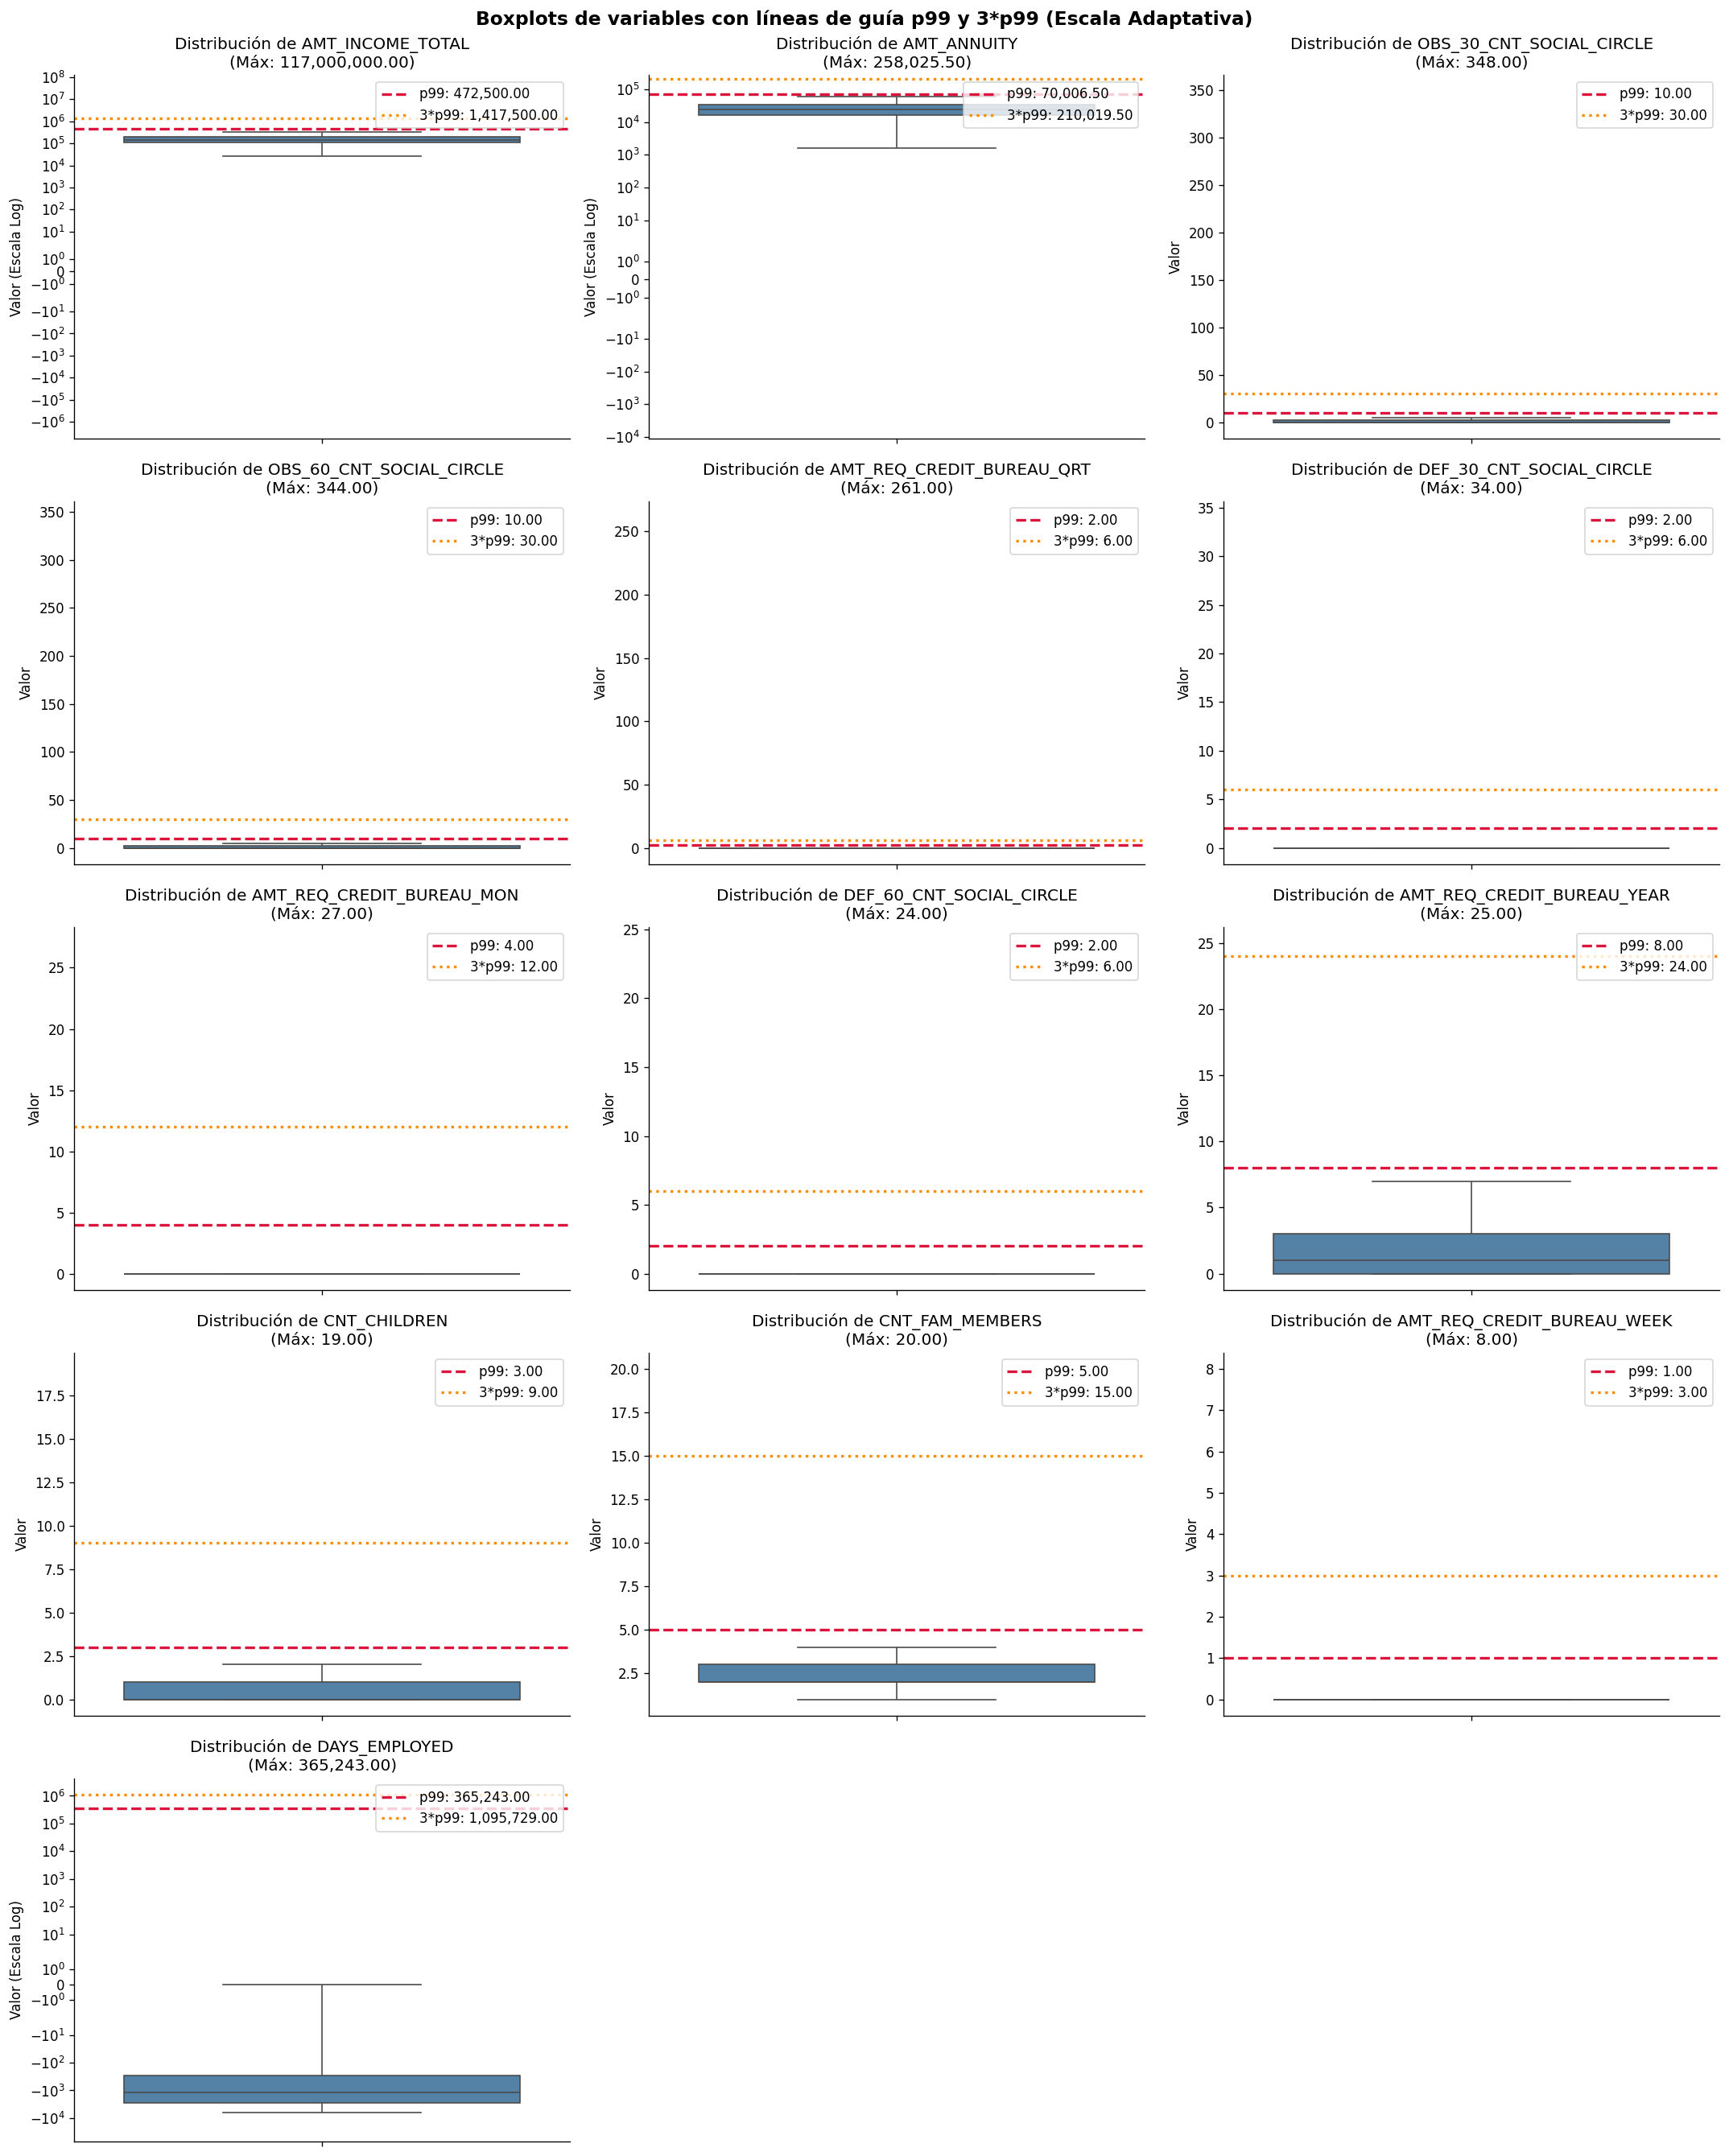

In [29]:
# Boxplots de variables con líneas de guía p99 y 3*p99

plot_cols = list(severe_cols) + (['DAYS_EMPLOYED'] if 'DAYS_EMPLOYED' not in severe_cols else [])
stats_lookup = df_stats.set_index('Variable')

n_grid_cols = 3
n_grid_rows = (len(plot_cols) + n_grid_cols - 1) // n_grid_cols

fig, axes = plt.subplots(n_grid_rows, n_grid_cols, figsize=(18, 4.5 * n_grid_rows))
for ax, col in zip(axes.ravel(), plot_cols):
    p99 = float(stats_lookup.at[col, 'p99'])
    max_val = float(stats_lookup.at[col, 'Máximo'])
    
    # Grafico fliers
    sns.boxplot(y=app_outliers[col], showfliers=True, ax=ax, color='steelblue',
                flierprops=dict(marker='o', markersize=3, alpha=0.3, markeredgecolor='none'))
    
    # Uso escala symlog si el máximo es muy grande para no aplastar la caja y escala lineal para casos con n pequeños
    if max_val > 1000:
        ax.set_yscale('symlog')
        ylabel_str = 'Valor (Escala Log)'
    else:
        ylabel_str = 'Valor'
    
    # Aplico las líneas de referencia para guiarme en futuros criterios de capping
    ax.axhline(p99, color='crimson', linestyle='--', linewidth=2, label=f'p99: {p99:,.2f}')
    ax.axhline(3 * p99, color='darkorange', linestyle=':', linewidth=2, label=f'3*p99: {3*p99:,.2f}')
    
    ax.set(title=f'Distribución de {col}\n(Máx: {max_val:,.2f})', ylabel=ylabel_str)
    ax.legend(loc='upper right')

# Elimino subplots sobrantes
for ax in axes.ravel()[len(plot_cols):]:
    fig.delaxes(ax)

plt.suptitle('Boxplots de variables con líneas de guía p99 y 3*p99 (Escala Adaptativa)', fontsize=14, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()


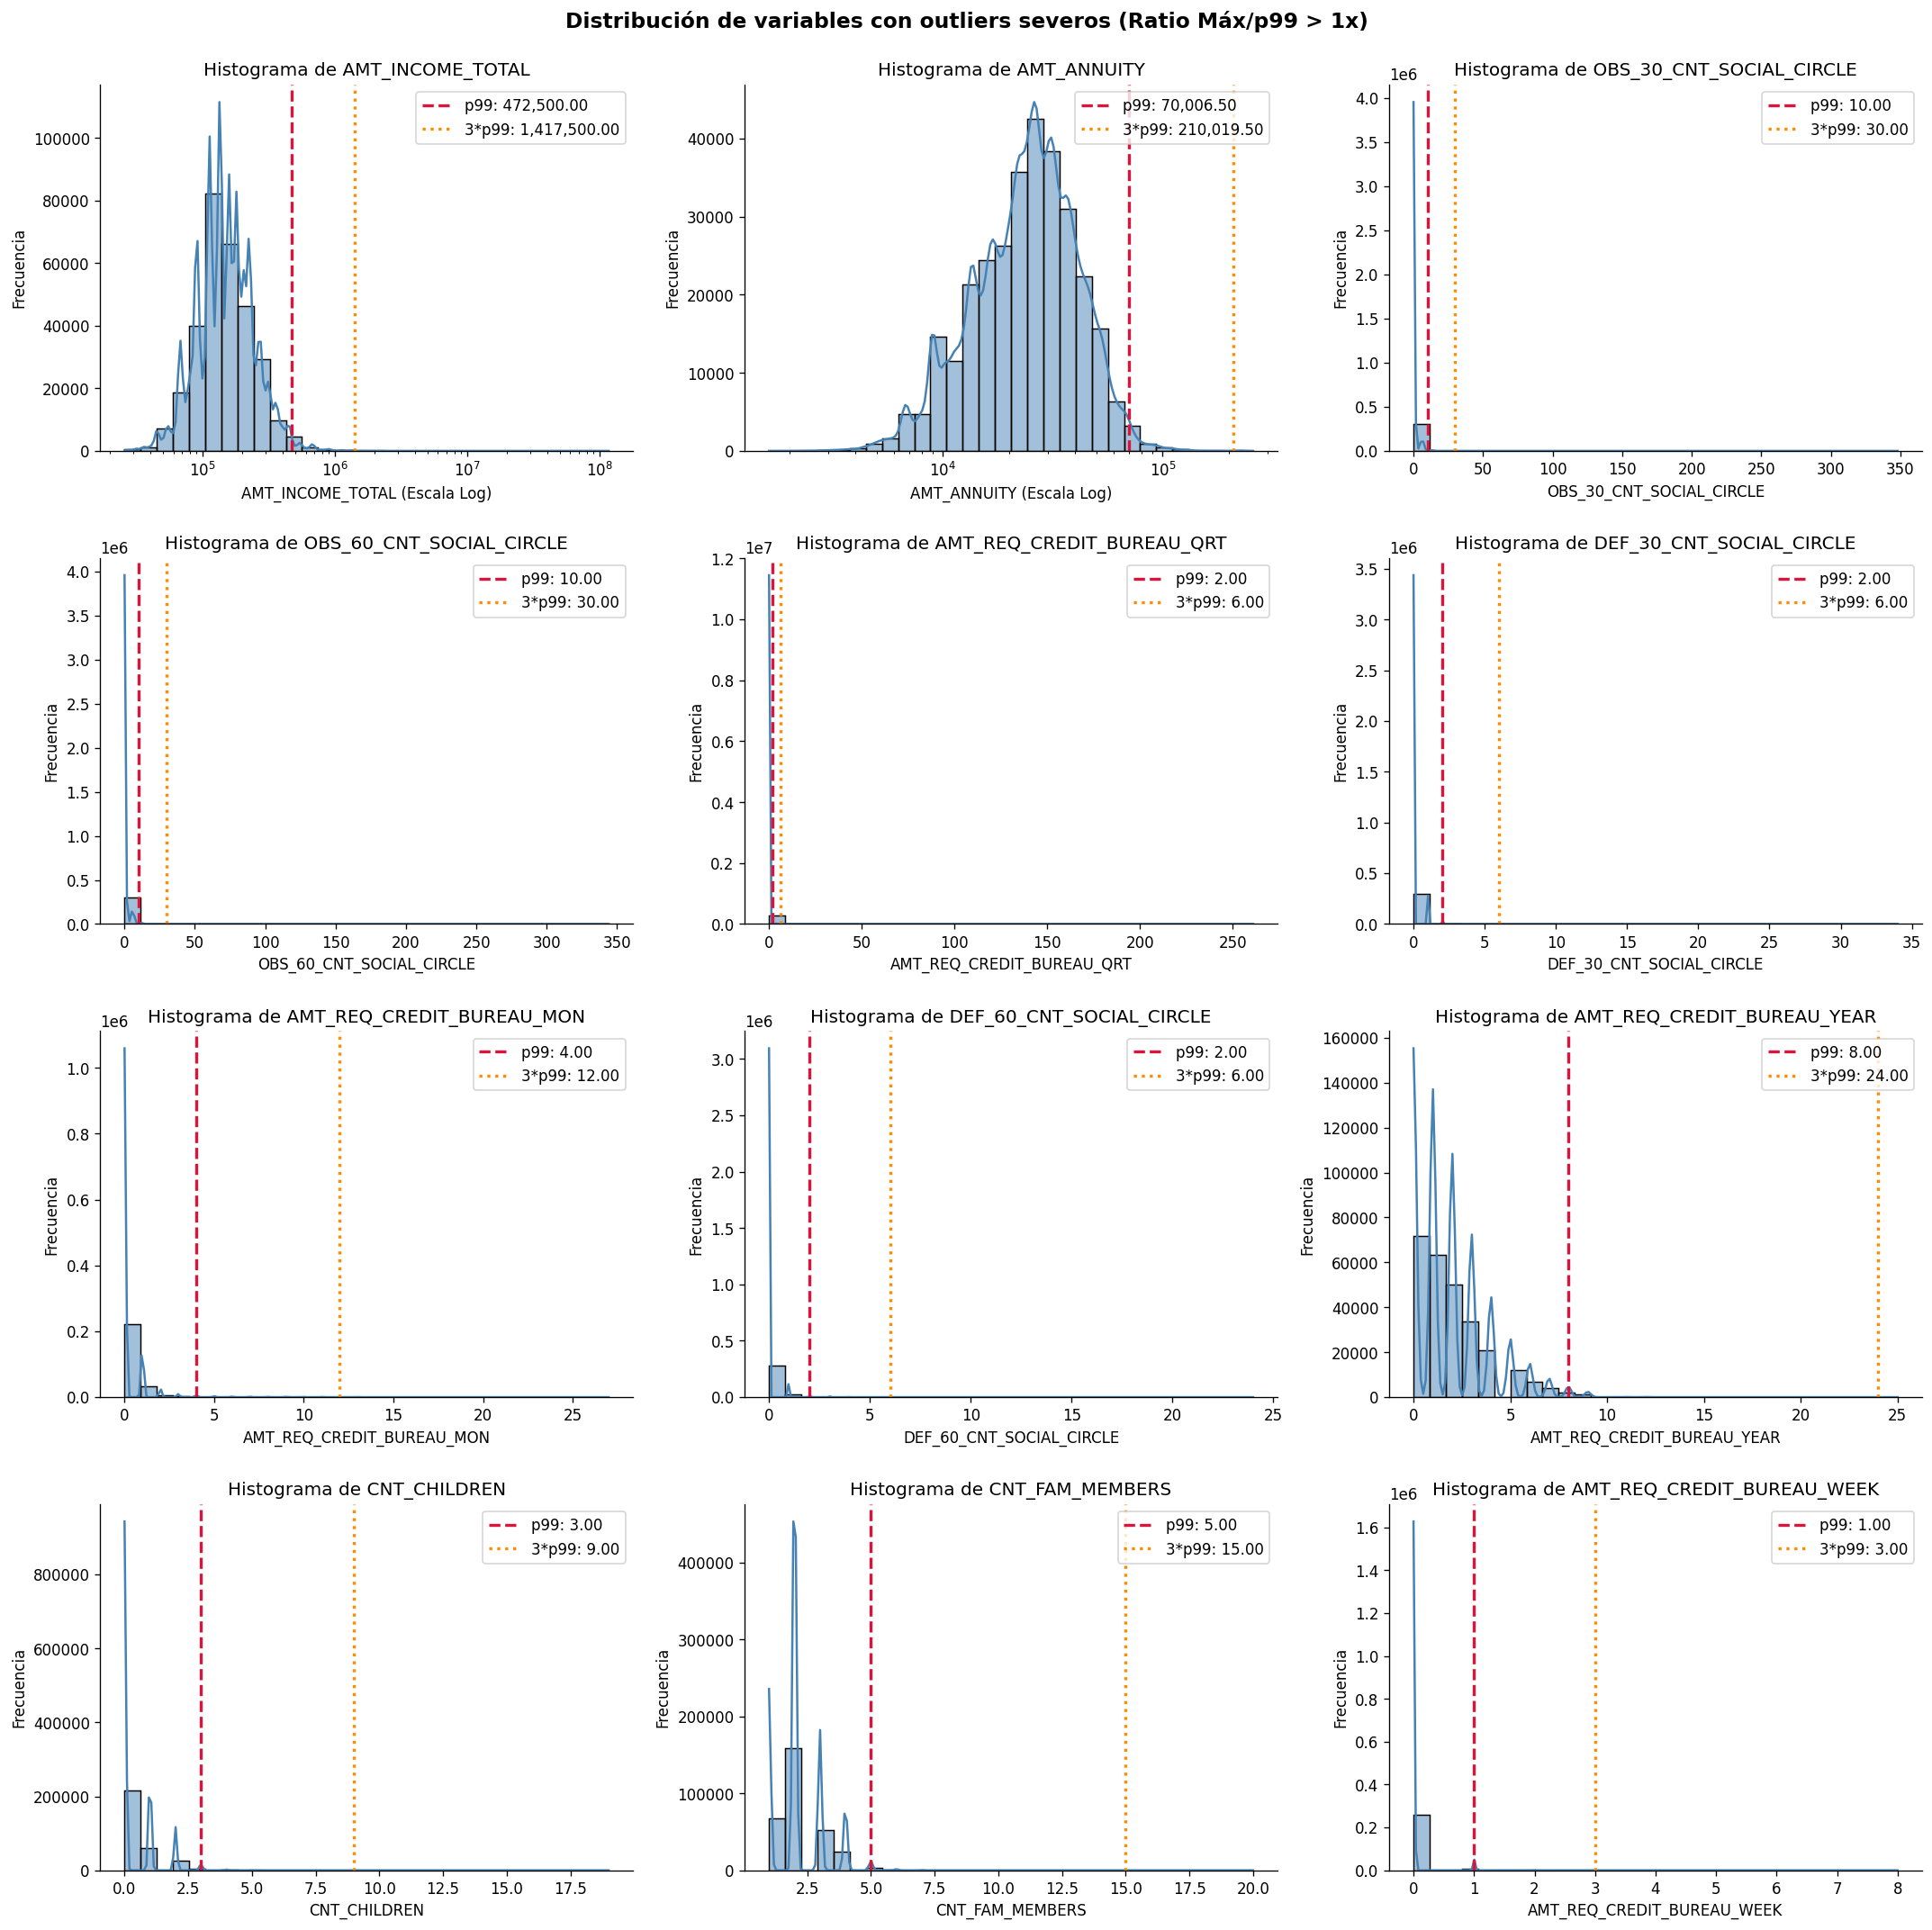

In [30]:
# Histogramas de variables con Ratio Máx / p99 > 1x (de la celda de estadísticas)

# Filtro variables con Ratio Máx / p99 > 1x de severe_outliers_df (excluye DAYS_EMPLOYED que tiene ratio 1.0)
hist_cols = severe_outliers_df[severe_outliers_df['Ratio Máx / p99'] > 1]['Variable'].tolist()
stats_lookup = df_stats.set_index('Variable')

n_grid_cols = 3
n_grid_rows = (len(hist_cols) + n_grid_cols - 1) // n_grid_cols

fig, axes = plt.subplots(n_grid_rows, n_grid_cols, figsize=(18, 4.5 * n_grid_rows))
for ax, col in zip(axes.ravel(), hist_cols):
    data_col = app_outliers[col].dropna()
    
    # Obtengo estadísticos precalculados
    p99 = float(stats_lookup.at[col, 'p99'])
    max_val = float(stats_lookup.at[col, 'Máximo'])
    
    # Uso escala log si el máximo es muy grande
    use_log = max_val > 1000
    
    sns.histplot(data_col, kde=True, ax=ax, color='steelblue', 
                 log_scale=(use_log, False), bins=30)
    
    # Añado líneas de referencia p99 y 3*p99
    ax.axvline(p99, color='crimson', linestyle='--', linewidth=2, label=f'p99: {p99:,.2f}')
    ax.axvline(3 * p99, color='darkorange', linestyle=':', linewidth=2, label=f'3*p99: {3*p99:,.2f}')
    
    ylabel_str = 'Frecuencia'
    xlabel_str = f'{col} (Escala Log)' if use_log else col
    
    ax.set(title=f'Histograma de {col}', xlabel=xlabel_str, ylabel=ylabel_str)
    ax.legend(loc='upper right')

# Elimino subplots sobrantes
for ax in axes.ravel()[len(hist_cols):]:
    fig.delaxes(ax)

plt.suptitle('Distribución de variables con outliers severos (Ratio Máx/p99 > 1x)', fontsize=14, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()


**Boxplots con líneas p99 y 3×p99**

Los boxplots con `showfliers=False` muestran la distribución limpia de cada variable con las líneas de referencia p99 (roja discontinua) y 3*p99 (naranja punteada) superpuestas. Lo que busco es entender dónde cae el grueso de los datos respecto a ambos umbrales y si el espacio entre ellos es grande o pequeño.

`AMT_INCOME_TOTAL` (escala log): la caja va de 100K a 200K con mediana en 150K. La línea p99 en 472K está ya por encima del bigote superior, y la de 3*p99 en 1.4M está completamente fuera del rango visible de la caja. Entre el bigote y el p99 hay un espacio considerable, lo que me indica que la distribución es muy asimétrica hacia la derecha. El máximo de 117M que aparece en el título ni siquiera cabría en esta escala, lo que confirma visualmente que es un valor grave.

`AMT_ANNUITY` (escala log): la caja ocupa un rango entre 15K y 35K. A diferencia de `AMT_INCOME_TOTAL`, aquí la línea p99 en 70K queda relativamente cerca del bigote superior, y la de 3*p99 en 210K aunque está lejos no sale del rango visual. La distribución es más compacta, lo que me hace pensar que los outliers por encima de p99 son cuotas grandes pero no necesariamente imposibles.

`OBS_30_CNT_SOCIAL_CIRCLE`: la caja está comprimida entre 0 y 5. La línea p99 en 10 queda visible y la de 3*p99 en 30 está ya bastante lejos. Lo que importa es que el máximo de 348 está completamente fuera de la escala del gráfico, lo que evidencia que no es una cola continua sino un valor aislado. Toda la masa de la distribución está aplastada contra el 0.

`AMT_REQ_CREDIT_BUREAU_QRT`: toda la distribución está concentrada entre 0 y 2. La línea p99 en 2 coincide prácticamente con el bigote, y la de 3*p99 en 6 queda un poco por encima. El máximo de 261 que aparece en el título es tan extremo respecto a la caja que confirma que es un error de sistema, no un cliente con muchas consultas.

`DEF_30_CNT_SOCIAL_CIRCLE`: la caja es una línea plana en 0. La inmensa mayoría de clientes tiene 0 contactos en default. El p99 de 2 ya captura prácticamente toda la varianza útil de la variable. La línea 3*p99 en 6 queda por encima de toda la distribución visible.

`AMT_REQ_CREDIT_BUREAU_MON`: similar a QRT, la caja está aplastada entre 0 y 1. El p99 en 4 está por encima del bigote y el 3*p99 en 12 queda lejos pero dentro de un rango concebible.

`DEF_60_CNT_SOCIAL_CIRCLE`: mismo patrón que DEF_30, caja plana en 0 con p99 en 2 y 3*p99 en 6.

`AMT_REQ_CREDIT_BUREAU_YEAR`: esta es la excepción dentro del bloque del buró. La caja tiene amplitud real (de 0 a 3) con bigote superior hasta 7 y la línea p99 en 8 queda cerca del bigote. La distribución tiene más varianza que las otras variables del buró, lo que me sugiere que los valores altos aquí son más plausibles.

`CNT_CHILDREN`: caja entre 0 y 1 con mediana en 0. La línea p99 en 3 está justo por encima del bigote. La de 3*p99 en 9 queda lejos pero no es un número absurdo de hijos. El máximo de 19 sí lo es.

`CNT_FAM_MEMBERS`: caja entre 2 y 3. La línea p99 en 5 está cerca del bigote y 3*p99 en 15 queda bastante lejos. La distribución es más amplia que `CNT_CHILDREN` lo que tiene sentido ya que incluye adultos además de hijos.

`AMT_REQ_CREDIT_BUREAU_WEEK`: toda la distribución está en 0. El p99 en 1 y 3*p99 en 3 están por encima de la caja. Es una variable extremadamente concentrada en 0.

`DAYS_EMPLOYED` (escala log): este boxplot revela de forma muy clara las dos poblaciones separadas. El grueso de valores negativos (empleados reales) forma una distribución compacta entre -6000 y -200 días. El valor 365.243 aparece como un punto aislado en la zona positiva, completamente desconectado de la distribución principal. No es una cola continua sino un valor discreto de código que representa a los pensionistas. El p99 y 3*p99 están ambos en 365.243 lo que confirma que no es un outlier sino un valor estructural.

Los boxplots me confirman dos cosas: primero, que las distribuciones son altamente asimétricas y concentradas en rangos estrechos, y segundo, que hay una diferencia visual clara entre variables con colas continuas (AMT_ANNUITY, AMT_REQ_CREDIT_BUREAU_YEAR) y variables con valores aislados (OBS_30, AMT_REQ_CREDIT_BUREAU_QRT). Pero los boxplots ocultan la forma real de la cola al no mostrar los fliers. Para eso necesitaré histogramas.

---

**Histogramas con distribución de outliers severos**

Los histogramas me muestran la forma completa de la distribución incluyendo toda la cola, lo que los boxplots ocultaban con `showfliers=False`. Las líneas p99 y 3*p99 me permiten ver exactamente cuánta masa hay entre ambos umbrales y si la transición es continua o hay saltos.

`AMT_INCOME_TOTAL` (escala log): la distribución tiene forma de campana entre 50K y 500K. La línea p99 en 472K marca el final de la masa principal. Entre p99 y 3*p99 (1.4M) hay una cola visible pero delgada con barras de frecuencia decrecientes: son clientes de alto poder adquisitivo reales. Por encima de 3*p99 la cola se extiende hasta 117M con observaciones tan dispersas que ni siquiera forman barras visibles. La diferencia visual entre la cola continua (472K-1.4M) y el vacío posterior (1 4M-117M) respalda usar 3*p99 como punto de corte.

`AMT_ANNUITY` (escala log): distribución bimodal con dos picos de masa entre 10K y 40K. La cola entre p99 (70K) y 3*p99 (210K) es continua con barras decrecientes, sin saltos. Los 33 registros por encima de 3*p99 son cuotas extraordinariamente altas pero la transición es suave, no hay un vacío abrupto como en `AMT_INCOME_TOTAL`.

`OBS_30_CNT_SOCIAL_CIRCLE`: prácticamente toda la masa está aplastada en 0-10. El histograma muestra una barra enorme en 0 y barras rápidamente decrecientes hasta 10 (el p99). Entre 10 y 30 (3*p99) hay alguna observación dispersa. Por encima de 30 está prácticamente vacío salvo los 2 valores extremos de 348 que ni se ven en la escala. Hay un vacío claro entre la distribución real y los errores.

`OBS_60_CNT_SOCIAL_CIRCLE`: comportamiento idéntico al anterior, lo que es consistente con la correlación de 1.00 que encontré entre ambas variables en el análisis de multicolinealidad.

`AMT_REQ_CREDIT_BUREAU_QRT`: concentración masiva en 0-2. El histograma muestra barras enormes en 0 y 1, una barra menor en 2 (el p99), y después prácticamente vacío. No hay una cola continua: entre 6 y 261 no hay masa visible. El valor de 261 es un punto aislado completamente desconectado de la distribución, lo que confirma que es un error de captura, no un cliente con muchas consultas.

`DEF_30_CNT_SOCIAL_CIRCLE`: masa concentrada en 0 con una barra menor en 1 y una aún menor en 2 (p99). La cola entre 2 y 6 (3*p99) tiene algunas observaciones dispersas. Por encima de 6 los valores hasta 34 son extremadamente raros pero la transición es algo más continua que en `OBS_30`, sin un vacío tan grande.

`AMT_REQ_CREDIT_BUREAU_MON`: masa en 0-4 con cola decreciente. Se ven barras hasta 12 (3*p99) y después la cola se extiende hasta 27 con observaciones muy dispersas.

`DEF_60_CNT_SOCIAL_CIRCLE`: mismo patrón que DEF_30 pero con cola ligeramente más corta (máximo 24 vs 34).

`AMT_REQ_CREDIT_BUREAU_YEAR`: la excepción del bloque del buró. Tiene una distribución con datos concentrados visible y continua desde 0 hasta 25. No hay saltos ni vacíos entre p99 (8) y el máximo (25). Las barras van decreciendo de forma suave, lo que indica que los valores altos son una extensión natural de la distribución, no errores. Esto respalda visualmente la decisión de no cappear esta variable.

`CNT_CHILDREN`: todo esta concentrado en 0-3 con barras rápidamente decrecientes. La cola es continua hasta 19 sin saltos, pero a partir de 9 (3*p99) las barras son tan bajas que apenas se distinguen del eje. Son 10 obs en un rango de 10 valores posibles, lo que estadísticamente no aporta nada al modelo.

`CNT_FAM_MEMBERS`: todo el cotenido concentrado en 2-4. La cola hasta 20 es continua pero muy delgada. El patrón es similar a `CNT_CHILDREN` pero desplazado hacia la derecha.

`AMT_REQ_CREDIT_BUREAU_WEEK`: concentración masiva en 0, barra menor en 1 (p99), y cola muy dispersa hasta 8. Las 71 obs por encima de 3*p99 = 3 están en un rango de 4-8 consultas semanales, que es excesivo pero no tan extremo como los 261 trimestrales.

Los histogramas me permiten distinguir claramente entre dos tipos de colas: las continuas (`AMT_ANNUITY`, `AMT_REQ_CREDIT_BUREAU_YEAR`, `CNT_CHILDREN`, `CNT_FAM_MEMBERS`) donde los valores extremos son una extensión natural de la distribución sin saltos, y las aisladas (`AMT_REQ_CREDIT_BUREAU_QRT`, `OBS_30`/`60_CNT_SOCIAL_CIRCLE`) donde hay un vacío evidente entre la distribución y el outlier. Las primeras requieren un criterio más conservador porque cappear puede cortar señal real. Las segundas se pueden cappear con más confianza porque los valores extremos están claramente separados de la distribución. Pero todavía aun tenga que ver si los outliers son informativos para predecir el default o si es ruido. Para eso necesito cruzar con la variable objetivo como hice previamente en el analisis de missings.

In [31]:
# Tasa de default en outliers vs normales para todas las variables numéricas

# Configuro valores globales y umbral de Bonferroni para pruebas
stats_lookup = df_stats.set_index("Variable")
default_global = app_outliers["TARGET"].mean()
n_vars = len(num_cols)
alpha_bonferroni = 0.05 / n_vars
target = app_outliers["TARGET"]  # Referencia compartida

evidence_rows = []
for col in num_cols:
    p99 = float(stats_lookup.at[col, "p99"])
    maximo = float(stats_lookup.at[col, "Máximo"])
    
    # Identifico obs outliers (> p99) excluyendo nulos
    mask = app_outliers[col].notna()
    is_out = app_outliers.loc[mask, col] > p99   # Serie booleana sobre no-nulos
    n_out = is_out.sum()

    if n_out > 0:
        # Alineo variable objetivo con la máscara de no-nulos
        t = target[mask]
        
        # Frecuencias para tabla de contingencia 2x2: [Outlier/Normal] x [Default/No-Default]
        a = int(t[is_out].sum())                 # Outlier con default
        b = n_out - a                            # Outlier sin default
        c = int(t[~is_out].sum())                # Normal con default
        d = int((~is_out).sum()) - c             # Normal sin default
        contingency = [[a, b], [c, d]]
        
        # Test de hipótesis: Fisher si hay frecuencias esperadas muy bajas (<5), Chi2 en caso contrario
        if min(a, b, c, d) < 5:
            _, p_value = fisher_exact(contingency)
            test_usado = "Fisher"
        else:
            _, p_value, _, _ = chi2_contingency(contingency)
            test_usado = "Chi2"
            
        # Calculo tasas de default y su diferencia (Delta)
        dr_out = a / n_out
        dr_norm = c / (len(is_out) - n_out)
        delta = dr_out - dr_norm
    else:
        dr_out = dr_norm = delta = p_value = np.nan
        test_usado = "-"

    # Registro métricas y resultados de las pruebas estadísticas
    n_total = mask.sum()
    evidence_rows.append({
        "Variable": col,
        "p99": p99,
        "Máximo": maximo,
        "Ratio Máx/p99": maximo / p99 if p99 > 0 else np.nan,
        "Obs > p99": n_out,
        "% > p99": n_out / n_total * 100,
        "Default outliers (%)": dr_out * 100,
        "Default normales (%)": dr_norm * 100,
        "Delta Default (pp)": delta * 100,
        "Test": test_usado,
        "p-valor": p_value,
        "Sig. Bonferroni": "Sí" if (pd.notna(p_value) and p_value < alpha_bonferroni) else "No",
        "Outliers con señal (>2pp)": "Sí" if (pd.notna(delta) and abs(delta) > 0.02) else "No",
    })

# Construyo DataFrame ordenado por valor absoluto del Delta Default
df_evidence = pd.DataFrame(evidence_rows).sort_values(
    "Delta Default (pp)", key=abs, ascending=False).reset_index(drop=True)

# Calculo métricas de resumen y porcentaje de coincidencia entre criterios
n_sig = (df_evidence["Sig. Bonferroni"] == "Sí").sum()
n_senal = (df_evidence["Outliers con señal (>2pp)"] == "Sí").sum()
concordancia = (df_evidence["Sig. Bonferroni"] == df_evidence["Outliers con señal (>2pp)"]).mean() * 100

print(f"Tasa de default global: {default_global*100:.2f}%")
print(f"Test: Chi2 / Fisher exacto si celda < 5 | Bonferroni alpha = 0.05 / {n_vars} = {alpha_bonferroni:.5f}")
print(f"Variables |Delta| > 2pp: {n_senal} | Significativas (Bonferroni): {n_sig} | Concordancia: {concordancia:.1f}%")
print()

# Renderizo tabla estilizada y coloreo resultados positivos (verde) / negativos (rojo)
display(df_evidence.style.format({
    "p99": "{:,.2f}", "Máximo": "{:,.2f}", "Ratio Máx/p99": "{:.1f}x",
    "Obs > p99": "{:,}", "% > p99": "{:.4f}%",
    "Default outliers (%)": "{:.2f}%", "Default normales (%)": "{:.2f}%",
    "Delta Default (pp)": "{:+.2f}pp", "p-valor": "{:.2e}"
}).map(
    lambda v: "background-color: #a8d5a2" if v == "Sí" else "background-color: #f4a4a4",
    subset=["Outliers con señal (>2pp)", "Sig. Bonferroni"]
))

Tasa de default global: 8.07%
Test: Chi2 / Fisher exacto si celda < 5 | Bonferroni alpha = 0.05 / 43 = 0.00116
Variables |Delta| > 2pp: 25 | Significativas (Bonferroni): 20 | Concordancia: 88.4%



,Variable,p99,Máximo,Ratio Máx/p99,Obs > p99,% > p99,Default outliers (%),Default normales (%),Delta Default (pp),Test,p-valor,Sig. Bonferroni,Outliers con señal (>2pp)
0,DEF_60_CNT_SOCIAL_CIRCLE,2.00,24.00,12.0x,758,0.2473%,14.91%,8.07%,+6.84pp,Chi2,8.60e-12,Sí,Sí
1,EXT_SOURCE_2,0.78,0.85,1.1x,"3,068",0.9998%,1.86%,8.14%,-6.28pp,Chi2,8.95e-37,Sí,Sí
2,EXT_SOURCE_1,0.89,0.96,1.1x,"1,342",1.0005%,1.42%,7.56%,-6.14pp,Chi2,2.94e-17,Sí,Sí
3,CNT_FAM_MEMBERS,5.00,20.00,4.0x,529,0.1720%,13.23%,8.06%,+5.17pp,Chi2,1.87e-05,Sí,Sí
4,DEF_30_CNT_SOCIAL_CIRCLE,2.00,34.00,17.0x,"1,515",0.4943%,13.00%,8.06%,+4.94pp,Chi2,2.81e-12,Sí,Sí
5,EXT_SOURCE_3,0.83,0.90,1.1x,"2,443",0.9909%,3.03%,7.81%,-4.78pp,Chi2,2.05e-18,Sí,Sí
6,DAYS_BIRTH,"-8,263.00","-7,489.00",nanx,"3,075",1.0000%,12.78%,8.03%,+4.76pp,Chi2,8.18e-22,Sí,Sí
7,CNT_CHILDREN,3.00,19.00,6.3x,555,0.1805%,12.79%,8.06%,+4.73pp,Chi2,6.14e-05,Sí,Sí
8,AMT_GOODS_PRICE,"1,800,000.00","4,050,000.00",2.2x,"1,431",0.4658%,3.42%,8.10%,-4.67pp,Chi2,1.34e-10,Sí,Sí
9,AMT_ANNUITY,"70,006.50","258,025.50",3.7x,"3,070",0.9984%,3.71%,8.12%,-4.40pp,Chi2,6.76e-19,Sí,Sí


Variables excluidas (p99 = max, sin outliers): ['REGION_POPULATION_RELATIVE', 'DAYS_EMPLOYED', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'DAYS_LAST_PHONE_CHANGE']


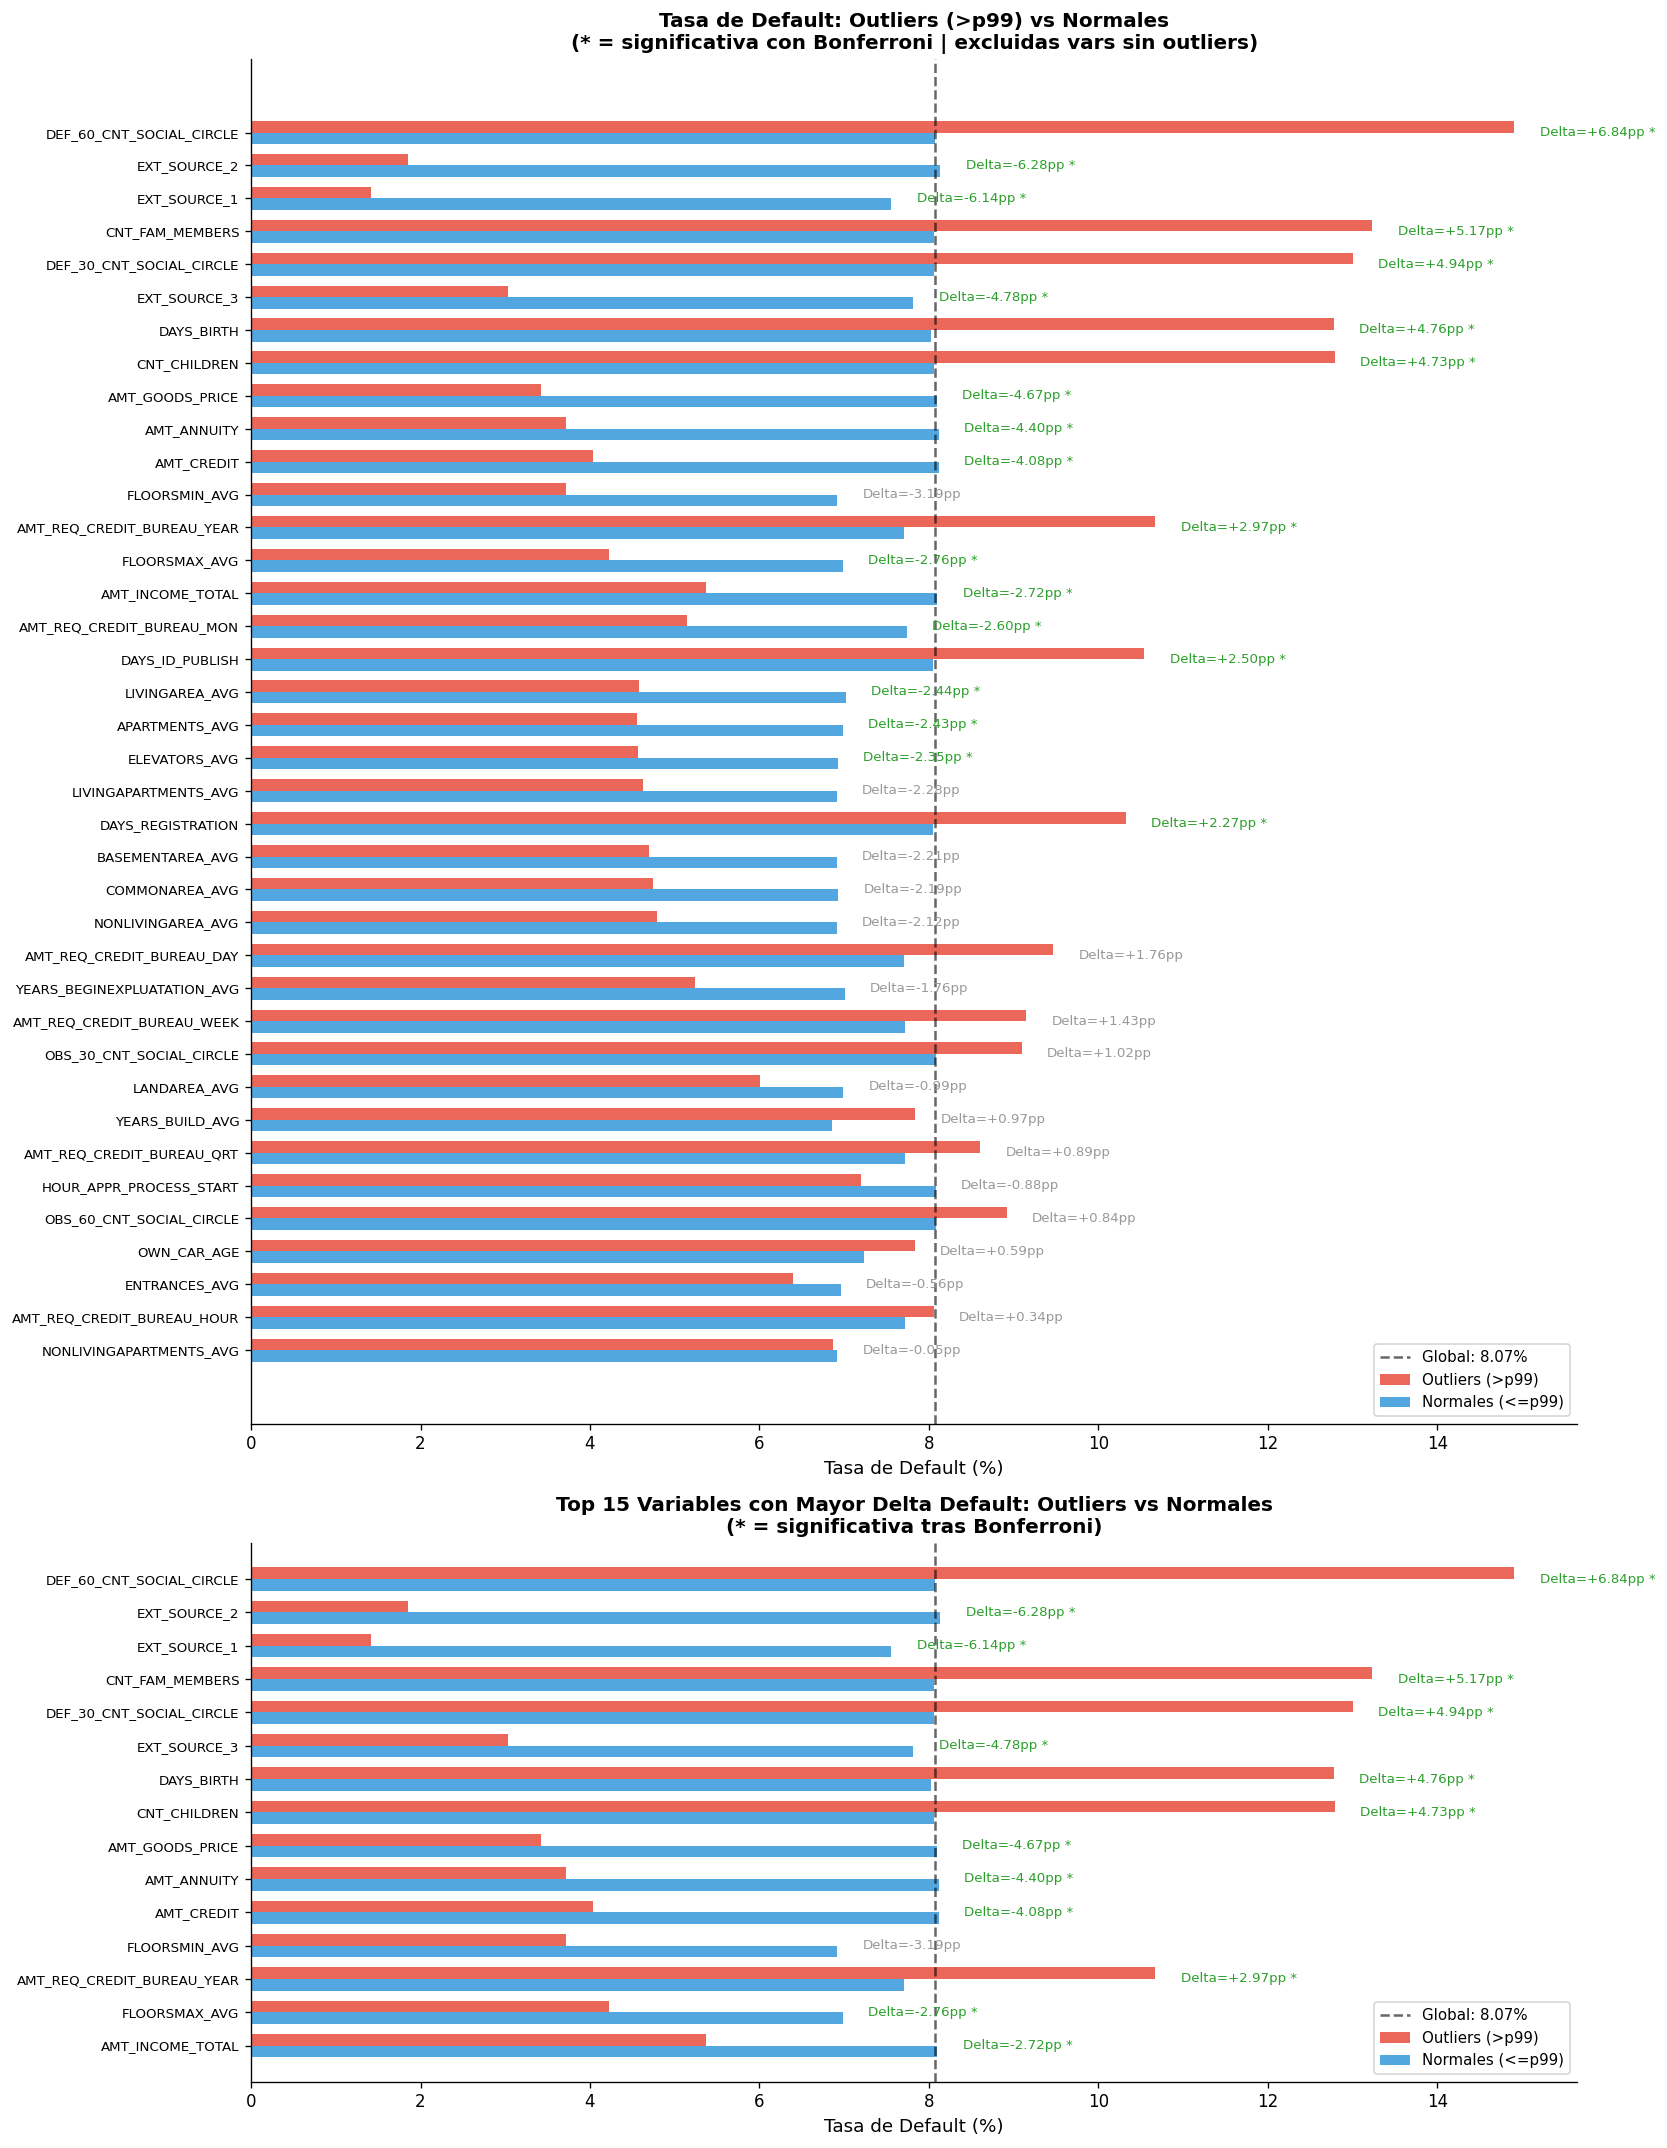

In [32]:
# Comparación visual tasa de default en outliers (>p99) vs normales

# Función para dibujar barras agrupadas de tasa de default
def plot_default_comparison(df, ax, title):
    y = np.arange(len(df))
    h = 0.35
    
    # Dibujo barras de tasas de default para outliers y normales
    ax.barh(y + h/2, df["Default outliers (%)"], height=h, color="#e74c3c", label="Outliers (>p99)", edgecolor="none", alpha=0.85)
    ax.barh(y - h/2, df["Default normales (%)"], height=h, color="#3498db", label="Normales (<=p99)", edgecolor="none", alpha=0.85)
    
    # Línea vertical de referencia para el default global
    ax.axvline(default_global * 100, color="black", linestyle="--", lw=1.5, alpha=0.6, label=f"Global: {default_global*100:.2f}%")
    
    # Añado el valor de Delta como etiqueta al final de cada barra
    for i, (_, r) in enumerate(df.iterrows()):
        max_val = max(r["Default outliers (%)"], r["Default normales (%)"])
        is_sig = r["Sig. Bonferroni"] == "Sí"
        label = f'Delta={r["Delta Default (pp)"]:+.2f}pp' + (" *" if is_sig else "")
        ax.text(max_val + 0.3, y[i], label, fontsize=8, va="center", color="#2ca02c" if is_sig else "#999999")
        
    # Títulos, etiquetas y configuración general de la leyenda
    ax.set_yticks(y)
    ax.set_yticklabels(df["Variable"], fontsize=8)
    ax.set_xlabel("Tasa de Default (%)", fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend(loc="lower right", fontsize=9)

# Variables excluidas por no tener observaciones que superen el p99 (p99 = max)
no_out = df_evidence[df_evidence["Obs > p99"] == 0]["Variable"].tolist()
if no_out:
    print(f"Variables excluidas (p99 = max, sin outliers): {no_out}")

# Filtro variables con outliers reales y ordenar por la magnitud del delta
df_valid = df_evidence[df_evidence["Obs > p99"] > 0].sort_values("Delta Default (pp)", key=abs)
df_top = df_valid.tail(15)  # Selecciono el top 15 de mayor diferencia

# Creo figura con dos subplots verticales
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 18), gridspec_kw={"height_ratios": [len(df_valid), 15]})
plot_default_comparison(df_valid, ax1, "Tasa de Default: Outliers (>p99) vs Normales\n(* = significativa con Bonferroni | excluidas vars sin outliers)")
plot_default_comparison(df_top, ax2, "Top 15 Variables con Mayor Delta Default: Outliers vs Normales\n(* = significativa tras Bonferroni)")

plt.tight_layout()
plt.show()


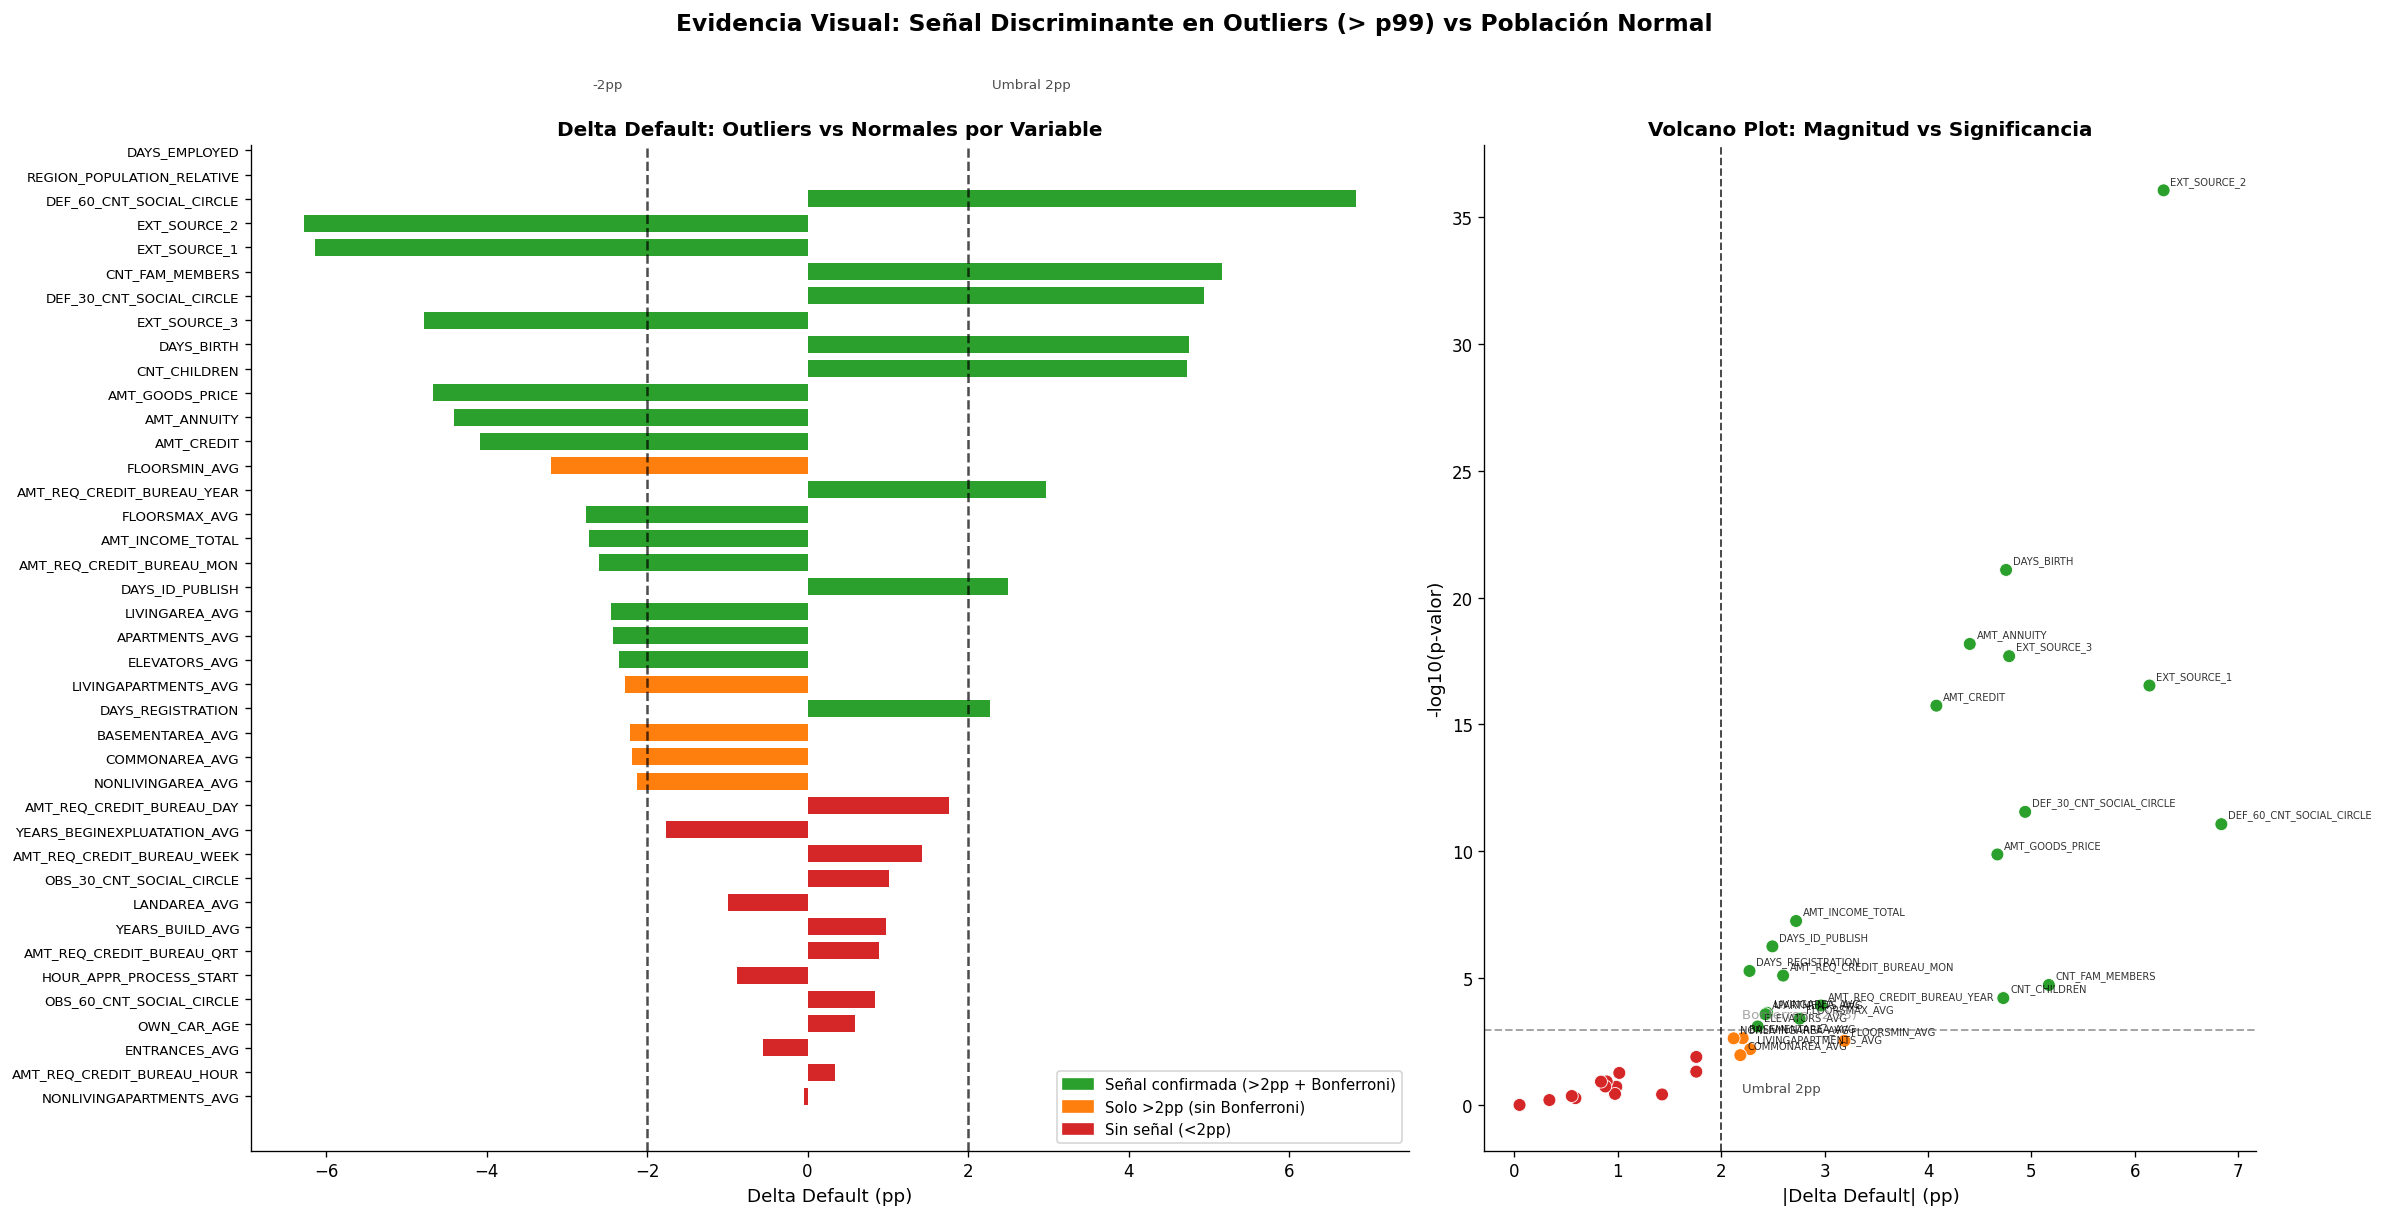

In [33]:
# Visualización de la evidencia de señal en outliers

# Mapeo colores para todo el análisis
both = (df_evidence["Sig. Bonferroni"] == "Sí") & (df_evidence["Outliers con señal (>2pp)"] == "Sí")
senal = df_evidence["Outliers con señal (>2pp)"] == "Sí"
df_evidence["color"] = np.select([both, senal], ["#2ca02c", "#ff7f0e"], default="#d62728")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10), gridspec_kw={"width_ratios": [3, 2]})

# Gráfico 1 Barras horizontales de Delta Default
df_plot = df_evidence.sort_values("Delta Default (pp)", key=abs)
ax1.barh(df_plot["Variable"], df_plot["Delta Default (pp)"], color=df_plot["color"], edgecolor="none", height=0.7)
ax1.axvline(2, color="black", linestyle="--", lw=1.5, alpha=0.7)
ax1.axvline(-2, color="black", linestyle="--", lw=1.5, alpha=0.7)
ax1.set_xlabel("Delta Default (pp)", fontsize=11)
ax1.set_title("Delta Default: Outliers vs Normales por Variable", fontsize=12, fontweight="bold")
ax1.tick_params(axis="y", labelsize=8)

ax1.legend(handles=[
    mpatches.Patch(color="#2ca02c", label="Señal confirmada (>2pp + Bonferroni)"),
    mpatches.Patch(color="#ff7f0e", label="Solo >2pp (sin Bonferroni)"),
    mpatches.Patch(color="#d62728", label="Sin señal (<2pp)"),
], loc="lower right", fontsize=9)

y_max = len(df_plot) - 1
ax1.text(2.3, y_max, "Umbral 2pp", fontsize=8, va="top", color="black", alpha=0.7)
ax1.text(-2.3, y_max, "-2pp", fontsize=8, va="top", ha="right", color="black", alpha=0.7)

# Gráfico 2: Volcano Plot (Magnitud vs Significancia)
df_sc = df_evidence.dropna(subset=["p-valor"]).copy()
df_sc["abs_delta"] = df_sc["Delta Default (pp)"].abs()
df_sc["neg_log_p"] = -np.log10(df_sc["p-valor"].clip(lower=1e-300))

ax2.scatter(df_sc["abs_delta"], df_sc["neg_log_p"], c=df_sc["color"], s=60, edgecolors="white", lw=0.5, zorder=3)

bonf_line = -np.log10(0.05 / n_vars)
ax2.axhline(bonf_line, color="gray", linestyle="--", lw=1.2, alpha=0.7)
ax2.axvline(2, color="black", linestyle="--", lw=1.2, alpha=0.7)

for _, r in df_sc.iterrows():
    if r["Sig. Bonferroni"] == "Sí" or r["abs_delta"] > 2:
        ax2.annotate(r["Variable"], (r["abs_delta"], r["neg_log_p"]),
                     fontsize=6, alpha=0.8, xytext=(4, 4), textcoords="offset points")

ax2.set_xlabel("|Delta Default| (pp)", fontsize=11)
ax2.set_ylabel("-log10(p-valor)", fontsize=11)
ax2.set_title("Volcano Plot: Magnitud vs Significancia", fontsize=12, fontweight="bold")
ax2.text(2.2, bonf_line + 0.5, f"Bonferroni ({bonf_line:.2f})", fontsize=8, color="gray", alpha=0.7)
ax2.text(2.2, 0.5, "Umbral 2pp", fontsize=8, color="black", alpha=0.7)

plt.suptitle("Evidencia Visual: Señal Discriminante en Outliers (> p99) vs Población Normal",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


**Tabla de tasas de default en outliers (>p99) vs población normal**

Aquí es donde el análisis da un giro respecto a lo que esperaba. Al cruzar las obs por encima de p99 con la tasa de default y comparar contra la población normal (≤p99), descubrí que los outliers no son neutros sino que tienen tasas de default
distintas al resto. La tasa global es 8.07% y los outliers se desvían de ella en ambas direcciones dependiendo de la variable.

Lo primero que me llama la atención es que de las 43 variables analizadas, 25 tienen un delta mayor a 2pp en valor absoluto, y de esas 25, 20 son significativas tras corrección de Bonferroni (alpha = 0.05/43 = 0.00116). La concordancia del 88.4% entre
criterio estadístico y decisión me indica que las decisiones que voy a tomar son coherentes a la estadística.

**Las variables con delta positivo más alto (los outliers defaultean MÁS que la población normal) son:**

`DEF_60_CNT_SOCIAL_CIRCLE` lidera con +6.84pp: las 758 obs con más de 2 contactos en default tienen un 14.91% de default frente al 8.07% de los normales. Es casi el doble de la media global. El efecto de contagio social que identifiqué en el análisis de missings queda confirmado empíricamente. `DEF_30_CNT_SOCIAL_CIRCLE` (+4.94pp, 13.00%) muestra el mismo patrón.

`CNT_FAM_MEMBERS` (+5.17pp, 13.23%) y `CNT_CHILDREN` (+4.73pp, 12.79%): las familias con más de 5 miembros o más de 3 hijos tienen default significativamente mayor. Mayor carga financiera per cápita, menor capacidad de pago. La señal tiene sentido de negocio (riesgo) directo.

`DAYS_BIRTH` (+4.76pp, 12.78%): los outliers son los más jóvenes del dataset (por debajo de p99 ≈ 22.6 años). Esto conecta directamente con el análisis temporal que realice anteriormente donde la franja 20-25 tenía 12.29% de default. El outlier aquí no es un error sino la misma señal predictiva de la edad que ya conozco.

`AMT_REQ_CREDIT_BUREAU_YEAR` (+2.97pp, 10.67%): los que consultan el buró más de 8 veces al año tienen default un 37% superior a la media. Es el perfil de búsqueda activa de crédito que ya identifiqué en el análisis de missings del buró. Y como observé en los histogramas, la cola de esta variable es continua hasta 25 sin saltos, así que estos valores son clientes reales con mucha actividad crediticia.

`DAYS_ID_PUBLISH` (+2.50pp, 10.54%) y `DAYS_REGISTRATION` (+2.27pp, 10.32%): ambas tienen p99 cercano a 0 (evento muy reciente). Los clientes que cambiaron su documento o su dirección justo antes de solicitar el crédito tienen mayor riesgo, lo que conecta con una de las conlcusiones del análisis temporal sobre la estabilidad como mitigador de riesgo.

**Las variables con delta negativo más alto (los outliers defaultean MENOS) son informativas pero en la dirección opuesta:**

`EXT_SOURCE_2` (-6.28pp, 1.86%) y `EXT_SOURCE_1` (-6.14pp, 1.42%): los scores por encima de p99 corresponden a tasas de default de apenas un cuarto de la media global. Son los mejores pagadores del dataset y la señal más valiosa para el modelo. Que la columna "Outliers con señal (>2pp)" esté marcada como Sí con Bonferroni significativo confirma que no es ruido.

`EXT_SOURCE_3` (-4.78pp, 3.03%): misma dirección que los otros dos scores pero con delta algo menor. Los tres scores confirman que sus valores extremos son información pura, no ruido.

`AMT_GOODS_PRICE` (-4.67pp, 3.42%), `AMT_ANNUITY` (-4.40pp, 3.71%) y `AMT_CREDIT` (-4.08pp, 4.03%): créditos grandes = clientes con perfil financiero sólido. Default del 3.4-4% frente al 8% global. La señal es clara y significativa. Si cappeara estos valores le estaría diciendo al modelo que un crédito de 4M y uno de 1.8M son iguales, cuando en realidad el primero tiene la mitad de riesgo.

`AMT_INCOME_TOTAL` (-2.72pp, 5.37%): delta negativo real (los ricos pagan mejor) pero es el único caso donde la señal convive con errores de captura (el ratio de 247.6x con máximo de 117M). Por eso elijo 3*p99 como punto de corte: preserva los ingresos legítimos por debajo de 1.4M y elimina los errores por encima.

Las variables del edificio AVG (`FLOORSMIN` -3.19pp, `FLOORSMAX` -2.76pp, `LIVINGAREA` -2.44pp, `APARTMENTS` -2.43pp, `ELEVATORS` -2.35pp) todas muestran delta negativo entre -2 y -3pp. Por lo que los edificios con valores extremos (más plantas, más área) se asocian con menor riesgo. Pero la columna de Bonferroni muestra que `BASEMENTAREA` (-2.21pp), `COMMONAREA` (-2.19pp) y `NONLIVINGAREA` (-2.12pp) no alcanzan significancia tras la corrección, probablemente
porque están normalizadas entre 0-1 y el test pierde potencia en ese rango. De todas formas no las voy a cappear porque no tienen outliers reales al estar acotadas.

Las variables sin señal (delta < 2pp y sin Bonferroni): `OBS_30_CNT_SOCIAL_CIRCLE` (+1.02pp), `OBS_60_CNT_SOCIAL_CIRCLE` (+0.84pp), `AMT_REQ_CREDIT_BUREAU_QRT` (+0.89pp), `OWN_CAR_AGE` (+0.59pp), `HOUR_APPR_PROCESS_START` (-0.88pp), `ENTRANCES_AVG` (-0.56pp), `AMT_REQ_CREDIT_BUREAU_HOUR` (+0.34pp), `NONLIVINGAPARTMENTS_AVG` (-0.05pp). Sus outliers no discriminan entre buenos y malos pagadores, así que cappearlos no destruiría su posible señal.

---

**Histograma horizontal Default rate outliers vs normales por variable**

El gráfico de barras nos muestra la tabla de evidencia pero visualmente, lo que me permite ver de un vistazo la magnitud y dirección del delta de cada variable. Las barras rojas (outliers > p99) y azules (normales ≤ p99) con la línea discontinua de la media global (8.07%) hacen que los patrones sean inmediatos.

En el panel superior (todas las variables ordenadas por delta): lo más evidente es la separación en dos grupos. En la parte superior del gráfico, `DEF_60_CNT_SOCIAL_CIRCLE`, `CNT_FAM_MEMBERS`, `DEF_30_CNT_SOCIAL_CIRCLE`, `DAYS_BIRTH` y `CNT_CHILDREN` tienen barras rojas que se extienden claramente a la derecha de la media global, hasta el 12-15%. En la parte media, `EXT_SOURCE_2`, `EXT_SOURCE_1`, `EXT_SOURCE_3`, `AMT_GOODS_PRICE`, `AMT_ANNUITY` y `AMT_CREDIT` tienen barras rojas que quedan claramente a la izquierda de la media, entre el 1.5% y el 4%.

Los asteriscos (*) marcan las significativas tras Bonferroni. Observo que todas las variables del top 15 por delta absoluto tienen asterisco salvo `FLOORSMIN_AVG`, lo que me indica que la evidencia estadística es robusta para las decisiones más importantes.

Las variables del edificio `AVG` forman un bloque cohesivo en la zona de delta negativo entre -2 y -3pp. Todas sus barras rojas son más cortas que las azules de forma consistente. Esto refuerza lo que encontré en el análisis de missings: la información del edificio aporta señal débil pero real y consistente en todo el bloque.

En la zona central del gráfico (delta cercano a 0) están `OBS_30/60_CNT_SOCIAL_CIRCLE`, `OWN_CAR_AGE`, `HOUR_APPR_PROCESS_START`, `AMT_REQ_CREDIT_BUREAU_QRT`. Sus barras rojas y azules son prácticamente del mismo largo, lo que visualmente confirma que sus outliers son neutrales respecto al default.

El panel inferior (top 15 por delta absoluto) lo apliqué para darle más la atención a las variables más informativas. Lo más relevante es que las 6 primeras posiciones alternan entre positivas y negativas: `DEF_60` (+6.84), `EXT_SOURCE_2` (-6.28), `EXT_SOURCE_1` (-6.14), `CNT_FAM_MEMBERS` (+5.17), `DEF_30` (+4.94), `EXT_SOURCE_3` (-4.78). Esta alternancia evidencia visualmente que no se puede aplicar una regla uniforme de tratamiento: cappear todas las variables destruiría señal tanto en los clientes de alto riesgo como en los de bajo riesgo.

`AMT_INCOME_TOTAL` aparece en la posición 15 con delta de -2.72pp y asterisco. Su barra roja está ligeramente a la izquierda de la media (5.37%) lo que confirma que los ingresos altos sí se asocian con menor riesgo, pero como el ratio Máx/p99 es de 247.6x los errores de captura conviven con la señal real, justificando el capping selectivo en 3*p99.

---

**Delta Default y Volcano Plot**

Este conjunto de gráficos sintetiza todo el análisis en dos paneles complementarios que cruzan magnitud del efecto con significancia estadística.

El panel izquierdo (barras de delta) clasifica las variables en tres categorías por colores: verde (señal confirmada: delta > 2pp + significancia Bonferroni), naranja (delta > 2pp pero sin significancia Bonferroni) y rojo (sin señal: delta < 2pp). Lo que observo inmediatamente es que las barras verdes dominan la parte superior e inferior del gráfico, mientras que las naranjas y rojas se concentran en la zona central.

`DAYS_EMPLOYED` y `REGION_POPULATION_RELATIVE` aparecen sin barra porque tienen 0 observaciones por encima de p99, lo que hace imposible calcular un delta. En el caso de `DAYS_EMPLOYED` es porque el p99 = máximo = 365.243, confirmando una vez más que no es un outlier convencional.

Las barras verdes con delta positivo (derecha) más largas son `DEF_60_CNT_SOCIAL_CIRCLE` (+6.84pp), `CNT_FAM_MEMBERS` (+5.17pp), `DEF_30_CNT_SOCIAL_CIRCLE` (+4.94pp), `DAYS_BIRTH` (+4.76pp) y `CNT_CHILDREN` (+4.73pp). Todas superan los 2pp de umbral y tienen Bonferroni. Son las variables donde los outliers son señal real de alto riesgo.

Las barras verdes con delta negativo (izquierda) más largas son `EXT_SOURCE_2` (-6.28pp), `EXT_SOURCE_1` (-6.14pp), `EXT_SOURCE_3` (-4.78pp), `AMT_GOODS_PRICE` (-4.67pp), `AMT_ANNUITY` (-4.40pp) y `AMT_CREDIT` (-4.08pp). Son variables donde los outliers son posiblementes clientes premium de bajo riesgo (ricos/ultraricos).

Las barras naranjas son las más interesantes `LIVINGAPARTMENTS_AVG` (-2.28pp), `BASEMENTAREA_AVG` (-2.21pp), `COMMONAREA_AVG` (-2.19pp) tienen deltas que superan los 2pp pero no alcanzan significancia Bonferroni. Esto ocurre porque al estar normalizadas entre 0-1 el test pierde potencia en ese rango acotado. No es que no tengan señal sino que la evidencia estadística es más débil (por el rango). En cualquier caso no requieren capping porque no tienen outliers reales.

Las barras rojas (sin señal) confirman las variables donde los outliers son neutrales: `YEARS_BEGINEXPLUATATION_AVG` (-1.76pp), `AMT_REQ_CREDIT_BUREAU_WEEK` (+1.43pp), `OBS_30_CNT_SOCIAL_CIRCLE` (+1.02pp), `LANDAREA_AVG` (-0.99pp), `YEARS_BUILD_AVG` (+0.97pp), `AMT_REQ_CREDIT_BUREAU_QRT` (+0.89pp), `HOUR_APPR_PROCESS_START` (-0.88pp), `OBS_60_CNT_SOCIAL_CIRCLE` (+0.84pp), `OWN_CAR_AGE` (+0.59pp), `ENTRANCES_AVG` (-0.56pp), `AMT_REQ_CREDIT_BUREAU_HOUR` (+0.34pp), `NONLIVINGAPARTMENTS_AVG` (-0.05pp). Cappear estas variables no destruirá su señal predictiva como mencionamos previamente.

El panel derecho (volcano plot) cruza |Delta Default| en eje X con -log10(p-valor) en eje Y, lo que crea cuatro cuadrantes. Las líneas de referencia verticales en 2pp y la horizontal de significancia Bonferroni los delimitan.

El cuadrante superior derecho (alto delta + alta significancia) es donde están las variables más importantes. `EXT_SOURCE_2` destaca en la esquina extrema con el mayor -log10(p-valor) (37) y un delta de 6pp, lo que la convierte en la variable con la evidencia más fuerte de que sus outliers son informativos. `DAYS_BIRTH` está alto en significancia (~22) con delta de ~5pp. `AMT_ANNUITY` y `EXT_SOURCE_3` están agrupadas con significancias de 16-17 y deltas de 4-5pp.

`DEF_30_CNT_SOCIAL_CIRCLE` y `DEF_60_CNT_SOCIAL_CIRCLE` aparecen en la esquina derecha con los deltas más altos (5-7pp) pero con significancias algo menores (10-11) que las `EXT_SOURCE`. Esto se debe a que tienen menos observaciones por encima de p99 (758 y 1,515 vs 3,068 de `EXT_SOURCE_2`), lo que reduce la potencia del test.

`CNT_FAM_MEMBERS` y `CNT_CHILDREN` están en la zona derecha con deltas de 5pp pero significancias de solo 5-6, lo que las sitúa cerca del umbral de Bonferroni. La razón es que solo tienen 529 y 555 obs por encima de p99 respectivamente, lo que limita la potencia estadística.

Los puntos naranjas (`BASEMENTAREA_AVG`, `COMMONAREA_AVG`, `LIVINGAPARTMENTS_AVG`) están justo por debajo de la línea de Bonferroni y justo por encima del umbral de 2pp. Son casos fronterizos que el test no alcanza a confirmar pero que probablemente tendrían señal con más datos o menos comparaciones múltiples.

Los puntos rojos agrupados en la esquina inferior izquierda (delta < 2pp, baja significancia) son las variables sin señal. `NONLIVINGAPARTMENTS_AVG`, `COMMONAREA_AVG`, `ENTRANCES_AVG`, `OWN_CAR_AGE` están todos por debajo de ambos umbrales.

La lectura conjunta dambos gráficos y combinándolos con los anteriores me confirma que la decisión de tratamiento no puede basarse solo en el ratio Máx/p99 (que fue lo que usé al principio para identificar outliers severos). `AMT_REQ_CREDIT_BUREAU_QRT` tiene un ratio de 130.5x pero un delta de solo +0.89pp y aparece en la zona roja del volcano: se puede cappear sin perder señal. `EXT_SOURCE_2` tiene un ratio de solo 1.1x pero un delta de -6.28pp y aparece en la esquina verde del volcano: no se debe cappear bajo ningún concepto. El ratio identifica la magnitud del outlier pero la señal discriminante determina si ese outlier es información o ruido.

### Conclusiones del Análisis de Outliers

El análisis de outliers revela que en problemas de crédito no se puede aplicar una estrategia uniforme de capping como plantee previamente. De las 43 variables numéricas analizadas, 20 (46.5%) tienen una diferencia de default rate entre outliers y población normal que supera los 2pp y es estadísticamente significativa tras corrección de Bonferroni. Lo clave es que
la dirección del delta se invierte según el tipo de variable: las financieras y scores tienen deltas negativos (los outliers son clientes premium que defaultean menos) mientras que las de conteo familiar y círculo social tienen deltas positivos (los outliers son perfiles de alto riesgo). Cappear sin discriminar correctamente destruiría señal en ambas direcciones lo que implicaría un modelo nefasto o poco realista y con muchas flaquezas.

La estrategia definitiva se basara en tres criterios: (1) si el valor extremo es plausible, (2) si tiene señal discriminante, y (3) en qué dirección va esa señal. Solo se cappearán las variables donde los extremos son errores evidentes de captura o valores físicamente imposibles, manteniendo la cola natural de la distribución.

**Tabla de decisiones para Fase FE:**

| Variable | Estrategia | Valor cap | Justificación |
|----------|-----------|-----------|---------------|
| AMT_INCOME_TOTAL | Cap 3×p99 | 1,417,500 | Error evidente (117M) pero outliers válidos tienen señal (-2.72pp) |
| AMT_CREDIT | No cappear | - | Ratio 2.2x, señal real (-4.08pp), valores plausibles |
| AMT_ANNUITY | No cappear | - | Ratio 3.7x, señal real (-4.40pp), valores plausibles |
| AMT_GOODS_PRICE | No cappear | - | Ratio 2.2x, señal real (-4.67pp), valores plausibles |
| EXT_SOURCE_1/2/3 | No cappear | - | Normalizadas 0-1, señal extrema (-6pp), mejor predictor |
| DEF_30_CNT_SOCIAL_CIRCLE | Cap 3×p99 | 6 | Señal real (+4.94pp), extremos implausibles, 3 obs |
| DEF_60_CNT_SOCIAL_CIRCLE | Cap 3×p99 | 6 | Señal real (+6.84pp), extremos implausibles, 2 obs |
| OBS_30_CNT_SOCIAL_CIRCLE | Cap 3×p99 | 30 | Error captura (348), sin señal (<2pp), 2 obs |
| OBS_60_CNT_SOCIAL_CIRCLE | Cap 3×p99 | 30 | Error captura (344), sin señal (<2pp), 2 obs |
| AMT_REQ_CREDIT_BUREAU_QRT | Cap 3×p99 | 6 | Error captura (261), sin señal, 16 obs |
| AMT_REQ_CREDIT_BUREAU_MON | Cap 3×p99 | 12 | Ratio 6.8x, 197 obs |
| AMT_REQ_CREDIT_BUREAU_YEAR | No cappear | - | Señal real (+2.97pp), máx 25 plausible |
| AMT_REQ_CREDIT_BUREAU_WEEK | Cap 3×p99 | 3 | Ratio 8.0x, 71 obs |
| AMT_REQ_CREDIT_BUREAU_DAY | Cap fijo | 5 | p99=0, sin señal (+1.76pp) |
| AMT_REQ_CREDIT_BUREAU_HOUR | No cappear | - | p99=0, máx 4 posible, sin señal |
| CNT_CHILDREN | Cap 3×p99 | 9 | Señal real (+4.73pp), 19 hijos implausible, 10 obs |
| CNT_FAM_MEMBERS | Cap 3×p99 | 15 | Señal real (+5.17pp), 20 miembros implausible, 4 obs |
| DAYS_EMPLOYED | NaN (365243) | - | Código inactivo, no outlier real (18% dataset) |
| DAYS_BIRTH | No cappear | - | Sin errores, señal real (+4.76pp) |
| DAYS_REGISTRATION | No cappear | - | Máx 0, señal real (+2.27pp), extremo temporal válido |
| DAYS_ID_PUBLISH | No cappear | - | Máx 0, señal real (+2.50pp), extremo temporal válido |
| OWN_CAR_AGE | Cap p99 | 64 | >64 años implausible como activo, sin señal (+0.59pp) |
| Variables edificio AVG | No cappear | - | Normalizadas 0-1, sin outliers reales |

**Cambio de estrategia respecto a conclusiones previas.** En el markdown previo de distribuciones numéricas proponía "capping en p99 para todas las financieras". Sin embargo, tras analizar en esta sección demuestra que esa estrategia sería perjudicial: cappear en p99 afecta al 1% de la población, y en las variables financieras ese 1% tiene tasas de default entre 2x y 4x menores que el resto. En problemas como credit risk cappear un cliente premium que paga bien es tan perjudicial como no detectar un error de captura.

**Concordancia del análisis: 88.4%.** De las 43 variables, 5 discordancias corresponden a variables del edificio `AVG` donde el delta supera 2pp pero el capping no se aplicará por estar normalizadas esas variables entre 0-1.